# **Read CSV File**

In [ ]:
from google.colab import files
import pandas as pd

# Upload file
uploaded = files.upload()

Saving Thalassemia_Bangladesh_dataset.csv to Thalassemia_Bangladesh_dataset.csv


In [ ]:
# Read CSV file, preserve None/N/A as text
df = pd.read_csv('Thalassemia_Bangladesh_dataset.csv', keep_default_na=False)

# **Class Distribution Check**

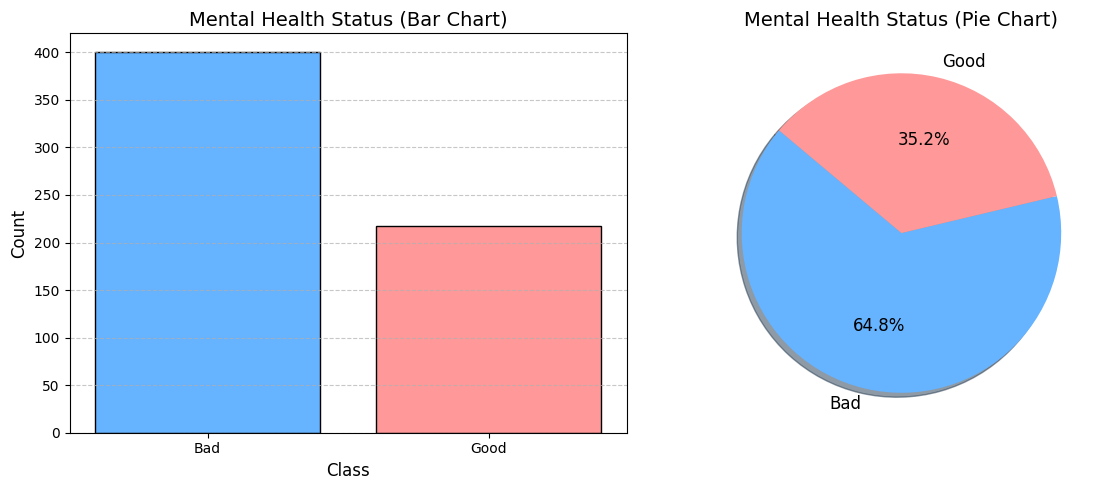

In [ ]:
import matplotlib.pyplot as plt

# Class distribution
counts = df['Mental_Health_Status'].value_counts()
labels = counts.index

colors = ['#66B3FF', '#FF9999']  # blue and pink

# Create figure with side-by-side subplots
fig, axs = plt.subplots(1, 2, figsize=(12,5))

# --- Bar Chart ---
axs[0].bar(labels, counts, color=colors[:len(labels)], edgecolor='black')
axs[0].set_xlabel("Class", fontsize=12)
axs[0].set_ylabel("Count", fontsize=12)
axs[0].set_title("Mental Health Status (Bar Chart)", fontsize=14)
axs[0].grid(axis='y', linestyle='--', alpha=0.7)

# --- Pie Chart ---
axs[1].pie(counts, labels=labels, autopct='%1.1f%%', colors=colors[:len(labels)], startangle=140, shadow=True, textprops={'fontsize':12})
axs[1].set_title("Mental Health Status (Pie Chart)", fontsize=14)

plt.tight_layout()
plt.show()

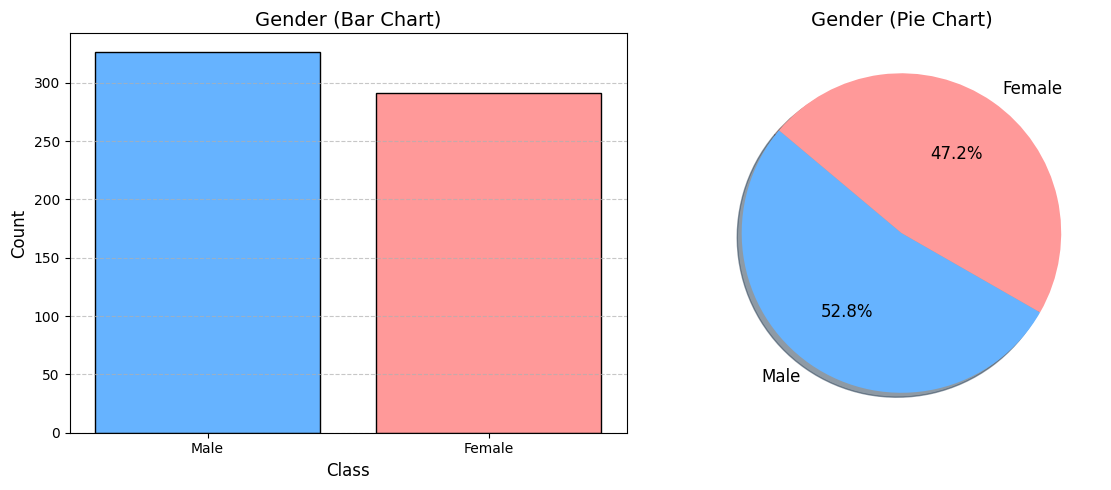

In [ ]:
import matplotlib.pyplot as plt

# Class distribution
counts = df['Gender'].value_counts()
labels = counts.index

colors = ['#66B3FF', '#FF9999']  # blue and pink

# Create figure with side-by-side subplots
fig, axs = plt.subplots(1, 2, figsize=(12,5))

# --- Bar Chart ---
axs[0].bar(labels, counts, color=colors[:len(labels)], edgecolor='black')
axs[0].set_xlabel("Class", fontsize=12)
axs[0].set_ylabel("Count", fontsize=12)
axs[0].set_title("Gender (Bar Chart)", fontsize=14)
axs[0].grid(axis='y', linestyle='--', alpha=0.7)

# --- Pie Chart ---
axs[1].pie(counts, labels=labels, autopct='%1.1f%%', colors=colors[:len(labels)], startangle=140, shadow=True, textprops={'fontsize':12})
axs[1].set_title("Gender (Pie Chart)", fontsize=14)

plt.tight_layout()
plt.show()

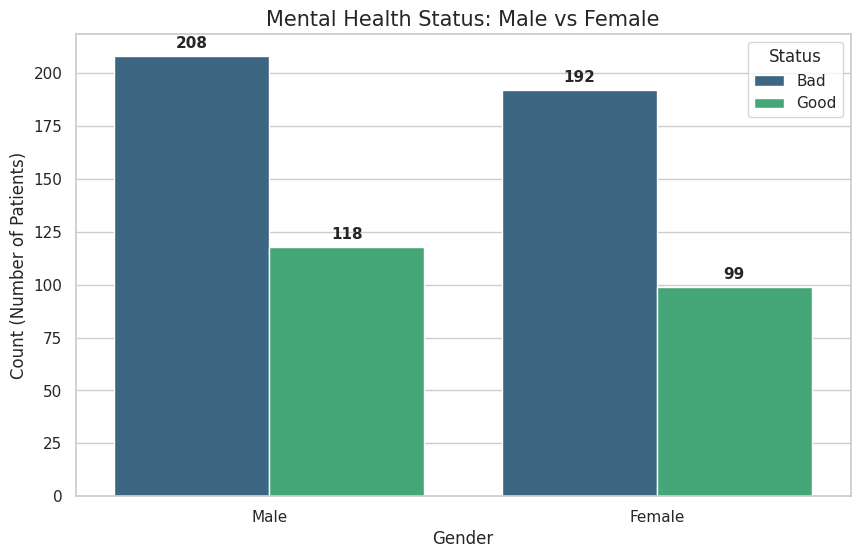

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set(style="whitegrid")

# Set figure size
plt.figure(figsize=(10, 6))

# Create the countplot
ax = sns.countplot(data=df, x='Gender', hue='Mental_Health_Status', palette='viridis')

# Title and axis labels
plt.title('Mental Health Status: Male vs Female', fontsize=15)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Count (Number of Patients)', fontsize=12)

# Add count labels on top of bars (ignore bars with 0 height)
for p in ax.patches:
    height = p.get_height()

    if height > 0:  # Avoid showing label for zero-height bars
        ax.annotate(f'{int(height)}',
                    (p.get_x() + p.get_width()/2., height),
                    ha='center', va='center',
                    xytext=(0, 9),
                    textcoords='offset points',
                    fontsize=11,
                    fontweight='bold')

# Show legend
plt.legend(title='Status', loc='upper right')

# Display the plot
plt.show()

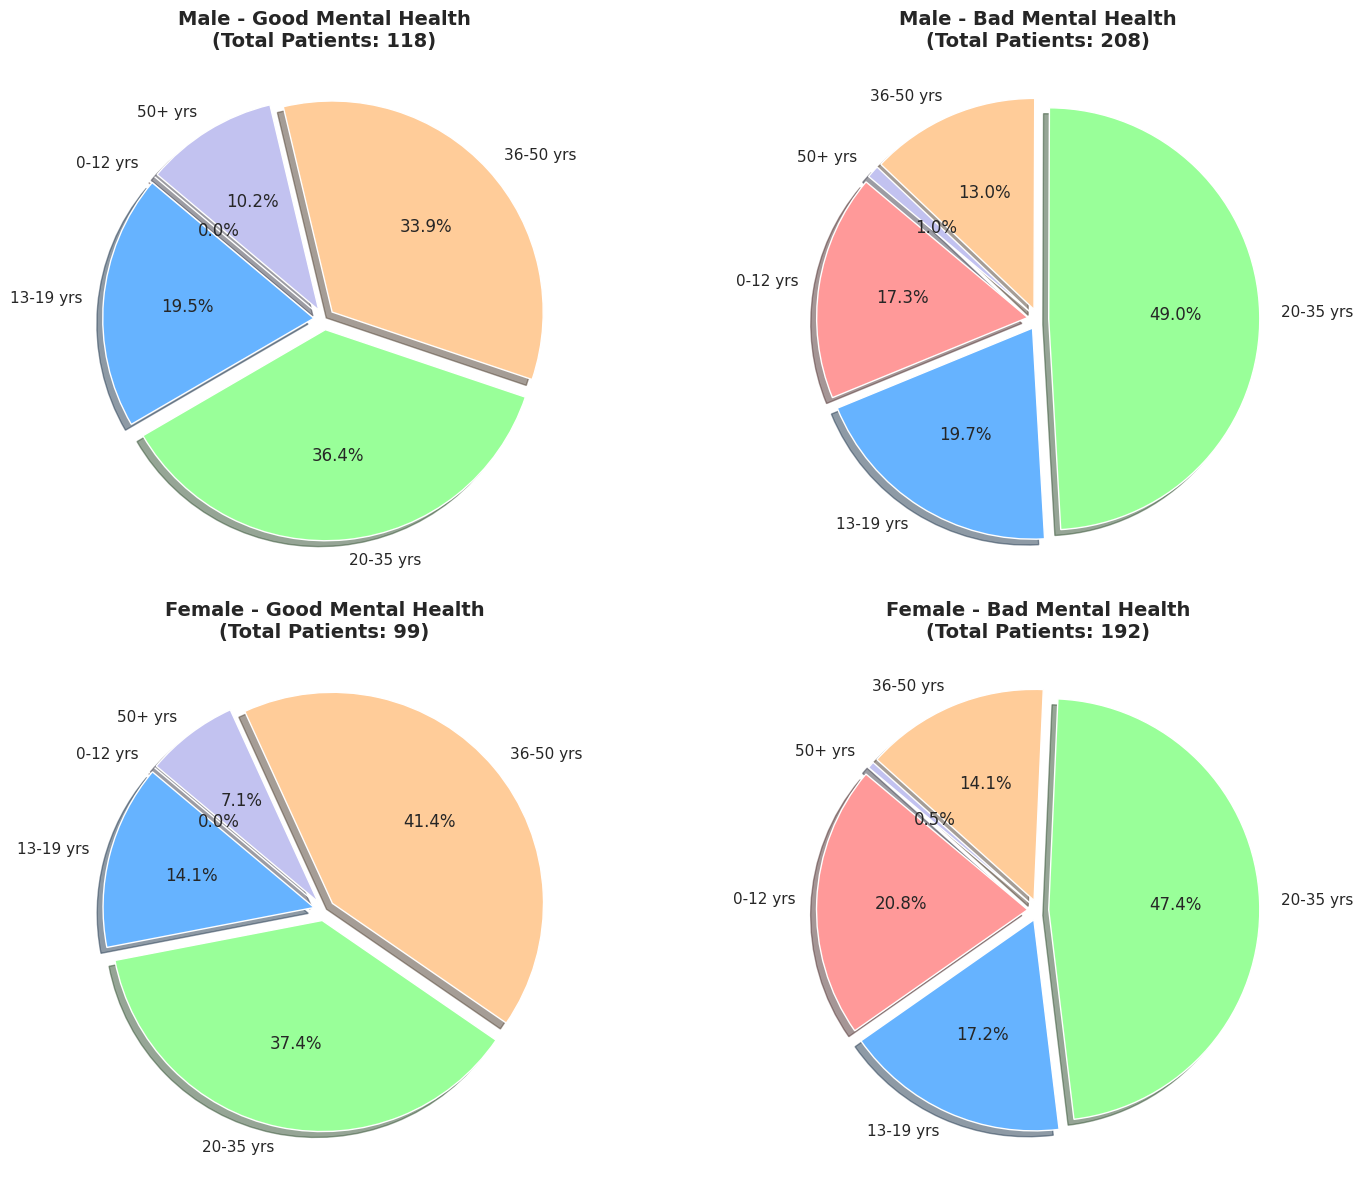

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Divide age into groups (Age Binning)
bins = [0, 12, 19, 35, 50, 70]
labels = ['0-12 yrs', '13-19 yrs', '20-35 yrs', '36-50 yrs', '50+ yrs']
df['Age_Group'] = pd.cut(df['Current_Age'], bins=bins, labels=labels)

# 2. Visualization setup
genders = ['Male', 'Female']
statuses = ['Good', 'Bad']
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99', '#c2c2f0']

idx = 0
for gender in genders:
    for status in statuses:
        row = idx // 2
        col = idx % 2

        # Filter the dataset based on specific gender and mental health status
        subset = df[(df['Gender'] == gender) & (df['Mental_Health_Status'] == status)]
        counts = subset['Age_Group'].value_counts().sort_index()

        # Create the pie chart
        if not counts.empty and counts.sum() > 0:
            axes[row, col].pie(counts, labels=counts.index, autopct='%1.1f%%',
                               startangle=140, colors=colors, shadow=True,
                               explode=[0.05]*len(counts))  # Slightly separate the slices
            axes[row, col].set_title(f'{gender} - {status} Mental Health\n(Total Patients: {len(subset)})',
                                     fontsize=14, fontweight='bold')
        else:
            axes[row, col].text(0.5, 0.5, 'No Data Available', ha='center', va='center')
            axes[row, col].set_title(f'{gender} - {status} Mental Health', fontsize=14)

        idx += 1

plt.tight_layout()
plt.show()

# **Check Missing Values**

In [ ]:
import numpy as np

# Columns where blank = missing
missing_cols = [
    'Self-Reported_Comorbidities'
]

# Replace blank cells ("") with NaN
for col in missing_cols:
    df[col] = df[col].replace("", np.nan)

In [ ]:
missing_values = df.isnull()

In [ ]:
total_missing = missing_values.sum()

In [ ]:
percentage_missing = (missing_values.sum() / len(df)) * 100

In [ ]:
print("Total Missing Values:\n", total_missing)
print("\nPercentage of Missing Values:\n", percentage_missing)

Total Missing Values:
 Patient_ID                               0
Current_Age                              0
Gender                                   0
Residence_Type                           0
Education_Level                          0
Monthly_Household_Income                 0
Travel_Time_to_Hospital (min)            0
School/Work_Impact                       0
Age_at_Diagnosis                         0
Thalassemia_Type                         0
Splenectomy_Status                       0
Self-Reported_Comorbidities            206
Pre-Transfusion_Hb (g/dL)                0
Serum_Ferritin (ng/mL)                   0
MCV (fL)                                 0
MCH (pg)                                 0
RDW (%)                                  0
Reticulocyte_Count (%)                   0
HbF_Percent (%)                          0
Transfusion_Frequency (units/month)      0
Iron_Chelation_Therapy                   0
Chelation_Adherence                      0
BMI (kg/m²)                    

In [ ]:
df.shape

(617, 25)

In [ ]:
df.isnull().sum()

,0
Patient_ID,0
Current_Age,0
Gender,0
Residence_Type,0
Education_Level,0
Monthly_Household_Income,0
Travel_Time_to_Hospital (min),0
School/Work_Impact,0
Age_at_Diagnosis,0
Thalassemia_Type,0


# **Handling Missing Column**

In [ ]:
# df = df.drop(['Self-Reported_Comorbidities'], axis=1)

# Step 1: Fill missing with 'None'
df['Self-Reported_Comorbidities'] = df['Self-Reported_Comorbidities'].fillna('None')

# Step 2: Create correct binary flag (has disease or not)
binary_flag = (df['Self-Reported_Comorbidities'] != 'None').astype(int)

# Step 3: Get original column index
col_index = df.columns.get_loc('Self-Reported_Comorbidities')

# Step 4: Drop original column
df = df.drop(columns=['Self-Reported_Comorbidities'])

# Step 5: Insert new column at same position
df.insert(col_index, 'Has_Comorbidity', binary_flag)

In [ ]:
df[['Patient_ID', 'Has_Comorbidity', 'Thalassemia_Type', 'Mental_Health_Status']].head(15)

,Patient_ID,Has_Comorbidity,Thalassemia_Type,Mental_Health_Status
0,1,1,Major,Bad
1,2,1,Major,Bad
2,3,0,Intermedia,Good
3,4,1,Intermedia,Good
4,5,0,Minor,Good
5,6,1,Major,Bad
6,7,1,Major,Bad
7,8,0,Intermedia,Good
8,9,1,Intermedia,Good
9,10,0,Minor,Good


In [ ]:
df.shape

(617, 25)

# **Check Duplicate Values**

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df[df.duplicated()]

,Patient_ID,Current_Age,Gender,Residence_Type,Education_Level,Monthly_Household_Income,Travel_Time_to_Hospital (min),School/Work_Impact,Age_at_Diagnosis,Thalassemia_Type,...,MCH (pg),RDW (%),Reticulocyte_Count (%),HbF_Percent (%),Transfusion_Frequency (units/month),Iron_Chelation_Therapy,Chelation_Adherence,BMI (kg/m²),Mental_Health_Status,Age_Group


In [ ]:
# Full duplicate check ignoring 'Patient_ID' and show as DataFrame
duplicate_rows = df[df.duplicated(subset=df.columns.drop('Patient_ID'), keep=False)]

# Display duplicates in DataFrame form
duplicate_rows_df = duplicate_rows.reset_index(drop=True)
print("Duplicate Rows (ignoring Patient_ID):")
print(duplicate_rows_df)

# Total duplicates count
print("\nTotal duplicates (ignoring Patient_ID):", len(duplicate_rows_df))

Duplicate Rows (ignoring Patient_ID):
   Patient_ID  Current_Age  Gender Residence_Type Education_Level  \
0           7           11  Female          Urban         Primary   
1           8           16    Male          Urban       Secondary   
2          11           16    Male          Urban       Secondary   
3          15           11  Female          Urban         Primary   

  Monthly_Household_Income  Travel_Time_to_Hospital (min) School/Work_Impact  \
0                   25,000                             35           Moderate   
1                   35,000                             20               Mild   
2                   35,000                             20               Mild   
3                   25,000                             35           Moderate   

   Age_at_Diagnosis Thalassemia_Type  ... MCH (pg)  RDW (%)  \
0               2.8            Major  ...     19.0       22   
1               6.5       Intermedia  ...     22.0       18   
2               6.5       

# **Handling Duplicate Values**

In [ ]:
df_clean = df.drop_duplicates(subset=df.columns.drop('Patient_ID'), keep='first')

In [ ]:
df=df_clean

In [ ]:
df.shape

(615, 25)

# **Check Unique Values in Each Column**

In [ ]:
cat_cols = df.select_dtypes(include=['object', 'category']).columns

for col in cat_cols:
    print(f"\nColumn: {col}")
    print(df[col].unique())


Column: Gender
['Male' 'Female']

Column: Residence_Type
['Rural' 'Urban']

Column: Education_Level
['None' 'Primary' 'Secondary' 'Graduate' 'Preschool' 'Postgraduate']

Column: Monthly_Household_Income
['25,000' '30,000' '45,000' '55,000' '40,000' '35,000' '20,000' '50,000'
 '65,000' '60,000' '70,000' '36,500' '30,500' '20,500' '15,000' '75,000'
 '10,000' '80,000' '85,000']

Column: School/Work_Impact
['High' 'Moderate' 'Mild' 'None' 'Low']

Column: Thalassemia_Type
['Major' 'Intermedia' 'Minor']

Column: Splenectomy_Status
['Yes' 'No']

Column: Iron_Chelation_Therapy
['DFX + DFP' 'DFX' 'DFP' 'None' 'DFX ']

Column: Chelation_Adherence
['Low' 'High' 'Medium' 'N/A']

Column: Mental_Health_Status
['Bad' 'Good']

Column: Age_Group
['0-12 yrs', '13-19 yrs', '20-35 yrs', '36-50 yrs', '50+ yrs']
Categories (5, object): ['0-12 yrs' < '13-19 yrs' < '20-35 yrs' < '36-50 yrs' < '50+ yrs']


In [ ]:
df = df.drop(['Patient_ID', 'Age_Group'], axis=1)

In [ ]:
df['Monthly_Household_Income'] = df['Monthly_Household_Income'].str.replace(',', '').astype(int)

In [ ]:
df.head(5)

,Current_Age,Gender,Residence_Type,Education_Level,Monthly_Household_Income,Travel_Time_to_Hospital (min),School/Work_Impact,Age_at_Diagnosis,Thalassemia_Type,Splenectomy_Status,...,MCV (fL),MCH (pg),RDW (%),Reticulocyte_Count (%),HbF_Percent (%),Transfusion_Frequency (units/month),Iron_Chelation_Therapy,Chelation_Adherence,BMI (kg/m²),Mental_Health_Status
0,4,Male,Rural,None,25000,90,High,1.5,Major,Yes,...,62,18.0,24,8.0,30.0,3.0,DFX + DFP,Low,14.2,Bad
1,12,Female,Urban,Primary,25000,40,Moderate,3.0,Major,No,...,66,20.0,22,6.0,25.0,2.5,DFX,High,15.8,Bad
2,17,Male,Urban,Secondary,30000,25,Mild,6.0,Intermedia,No,...,72,23.0,18,3.0,10.0,1.0,DFP,Medium,19.5,Good
3,25,Female,Urban,Graduate,45000,10,None,8.0,Intermedia,No,...,76,25.0,14,2.0,5.0,0.5,DFX,High,20.8,Good
4,28,Male,Urban,Graduate,55000,1600,None,20.0,Minor,No,...,82,28.0,12,1.0,1.5,0.0,None,N/A,23.4,Good


# **Statistical Analysis**

In [ ]:
# summary statistics of numerical columns
import numpy as np
df.describe(include=[np.number])

,Current_Age,Monthly_Household_Income,Travel_Time_to_Hospital (min),Age_at_Diagnosis,Has_Comorbidity,Pre-Transfusion_Hb (g/dL),Serum_Ferritin (ng/mL),MCV (fL),MCH (pg),RDW (%),Reticulocyte_Count (%),HbF_Percent (%),Transfusion_Frequency (units/month),BMI (kg/m²)
count,615.000000,615.000000,615.000000,615.000000,615.000000,615.000000,615.000000,615.000000,615.000000,615.000000,615.000000,615.000000,615.000000,615.000000
mean,27.147967,35923.577236,51.243902,9.934797,0.666667,10.588130,1519.141463,70.400000,22.460163,17.975610,4.856911,16.445528,2.271220,19.863902
std,12.242230,18735.185597,98.708793,9.578132,0.471788,3.310049,1605.776389,12.886728,6.945129,8.508344,4.268785,15.040011,2.588033,5.123685
min,2.000000,10000.000000,6.000000,0.500000,0.000000,3.600000,80.000000,43.000000,9.000000,5.000000,0.500000,1.000000,0.000000,7.100000
25%,18.000000,20000.000000,18.000000,4.000000,0.000000,6.950000,790.000000,63.000000,18.000000,13.000000,2.050000,6.000000,0.450000,14.550000
50%,26.000000,30000.000000,30.000000,6.000000,1.000000,10.800000,920.000000,69.000000,22.000000,16.000000,3.300000,12.000000,1.400000,20.900000
75%,36.000000,50000.000000,68.000000,8.550000,1.000000,12.800000,2900.000000,76.000000,27.000000,25.000000,8.500000,30.000000,3.550000,23.650000
max,60.000000,85000.000000,1600.000000,35.000000,1.000000,16.200000,10000.000000,93.000000,36.000000,42.000000,16.900000,64.000000,11.300000,29.300000


# **Feature Engineering**

In [ ]:
import pandas as pd
import numpy as np

def engineer_features(df):
    """
    Add clinically meaningful features for thalassemia mental health prediction.
    All features derived from existing columns without leakage.
    """
    df_new = df.copy()

    # Ensure Monthly_Household_Income is numeric (remove commas if any)
    if df_new['Monthly_Household_Income'].dtype == 'object':
        df_new['Monthly_Household_Income'] = df_new['Monthly_Household_Income'].str.replace(',', '').astype(float)

    # 1. Iron Overload Index (Ferritin / Hb)
    # Add small epsilon to avoid division by zero
    df_new['Iron_Overload_Index'] = df_new['Serum_Ferritin (ng/mL)'] / (df_new['Pre-Transfusion_Hb (g/dL)'] + 0.1)

    # 2. Approximate MCHC (MCH / MCV * 100)
    df_new['MCHC_approx'] = (df_new['MCH (pg)'] / df_new['MCV (fL)']) * 100

    # 3. Disease Duration (Current_Age - Age_at_Diagnosis)
    df_new['Disease_Duration'] = df_new['Current_Age'] - df_new['Age_at_Diagnosis']

    # 4. Severe Anemia Flag (Hb < 7 g/dL)
    df_new['Severe_Anemia_Flag'] = (df_new['Pre-Transfusion_Hb (g/dL)'] < 7).astype(int)

    # 5. Severe Iron Overload Flag (Ferritin > 2500 ng/mL)
    df_new['Severe_Iron_Overload_Flag'] = (df_new['Serum_Ferritin (ng/mL)'] > 2500).astype(int)

    # 6. Low Income Flag (Monthly_Household_Income < 30,000)
    df_new['Low_Income_Flag'] = (df_new['Monthly_Household_Income'] < 30000).astype(int)

    # 7. Pediatric Flag (Current_Age < 18)
    df_new['Pediatric_Flag'] = (df_new['Current_Age'] < 18).astype(int)

    # 8. Log-transformed Serum Ferritin (handles skewness)
    df_new['Log_Serum_Ferritin'] = np.log1p(df_new['Serum_Ferritin (ng/mL)'])

    # 9. Age group bins (optional, can be used as categorical)
    # df_new['Age_Group'] = pd.cut(df_new['Current_Age'], bins=[0,12,18,60,100], labels=['Child','Teen','Adult','Senior'])

    return df_new

# Apply the function to your dataframe
df = engineer_features(df)

# Now you can proceed with removing leaky columns and encoding.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 615 entries, 0 to 616
Data columns (total 31 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Current_Age                          615 non-null    int64  
 1   Gender                               615 non-null    object 
 2   Residence_Type                       615 non-null    object 
 3   Education_Level                      615 non-null    object 
 4   Monthly_Household_Income             615 non-null    int64  
 5   Travel_Time_to_Hospital (min)        615 non-null    int64  
 6   School/Work_Impact                   615 non-null    object 
 7   Age_at_Diagnosis                     615 non-null    float64
 8   Thalassemia_Type                     615 non-null    object 
 9   Splenectomy_Status                   615 non-null    object 
 10  Has_Comorbidity                      615 non-null    int64  
 11  Pre-Transfusion_Hb (g/dL)            

In [ ]:
# Move target column to the end
cols = [col for col in df.columns if col != 'Mental_Health_Status'] + ['Mental_Health_Status']
df = df[cols]

# **Encoding**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 615 entries, 0 to 616
Data columns (total 31 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Current_Age                          615 non-null    int64  
 1   Gender                               615 non-null    object 
 2   Residence_Type                       615 non-null    object 
 3   Education_Level                      615 non-null    object 
 4   Monthly_Household_Income             615 non-null    int64  
 5   Travel_Time_to_Hospital (min)        615 non-null    int64  
 6   School/Work_Impact                   615 non-null    object 
 7   Age_at_Diagnosis                     615 non-null    float64
 8   Thalassemia_Type                     615 non-null    object 
 9   Splenectomy_Status                   615 non-null    object 
 10  Has_Comorbidity                      615 non-null    int64  
 11  Pre-Transfusion_Hb (g/dL)            

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, OneHotEncoder

# Make a copy to avoid modifying original data
df_encoded = df.copy()

# 1. Clean Iron_Chelation_Therapy (remove trailing spaces)
df_encoded['Iron_Chelation_Therapy'] = df_encoded['Iron_Chelation_Therapy'].str.strip()

# 2. Binary/Label Encoding (no inherent order)
binary_cols = ['Gender', 'Residence_Type', 'Splenectomy_Status']
label_encoder = LabelEncoder()
for col in binary_cols:
    df_encoded[col] = label_encoder.fit_transform(df_encoded[col])

# 3. Handle Chelation_Adherence — separate N/A before ordinal encoding
df_encoded['No_Chelation'] = (df_encoded['Chelation_Adherence'] == 'N/A').astype(int)
df_encoded['Chelation_Adherence'] = df_encoded['Chelation_Adherence'].replace('N/A', 'Low')

# 4. Ordinal Encoding with correct category orders
ordinal_cols = {
    'Education_Level'    : ['None', 'Preschool', 'Primary', 'Secondary', 'Graduate', 'Postgraduate'],
    'School/Work_Impact' : ['None', 'Low', 'Mild', 'Moderate', 'High'],
    'Thalassemia_Type'   : ['Minor', 'Intermedia', 'Major'],
    'Chelation_Adherence': ['Low', 'Medium', 'High']
}

ordinal_encoder = OrdinalEncoder(categories=[ordinal_cols[col] for col in ordinal_cols])
ordinal_data = ordinal_encoder.fit_transform(df_encoded[list(ordinal_cols.keys())])

for i, col in enumerate(ordinal_cols.keys()):
    df_encoded[col] = ordinal_data[:, i]

# 5. One-Hot Encoding for Iron_Chelation_Therapy
onehot_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
onehot_encoded = onehot_encoder.fit_transform(df_encoded[['Iron_Chelation_Therapy']])

onehot_df = pd.DataFrame(
    onehot_encoded,
    columns=onehot_encoder.get_feature_names_out(['Iron_Chelation_Therapy']),
    index=df_encoded.index
)

df_encoded = df_encoded.drop('Iron_Chelation_Therapy', axis=1)
df_encoded = pd.concat([df_encoded, onehot_df], axis=1)

# 6. Encode target column (Mental_Health_Status): Bad=0, Good=1
target_encoder = LabelEncoder()
df_encoded['Mental_Health_Status'] = target_encoder.fit_transform(df_encoded['Mental_Health_Status'])

# Final check
print("Shape:", df_encoded.shape)
print("\nDtypes:\n", df_encoded.dtypes)
print("\nPreview:\n", df_encoded.head())

Shape: (615, 35)

Dtypes:
 Current_Age                              int64
Gender                                   int64
Residence_Type                           int64
Education_Level                        float64
Monthly_Household_Income                 int64
Travel_Time_to_Hospital (min)            int64
School/Work_Impact                     float64
Age_at_Diagnosis                       float64
Thalassemia_Type                       float64
Splenectomy_Status                       int64
Has_Comorbidity                          int64
Pre-Transfusion_Hb (g/dL)              float64
Serum_Ferritin (ng/mL)                   int64
MCV (fL)                                 int64
MCH (pg)                               float64
RDW (%)                                  int64
Reticulocyte_Count (%)                 float64
HbF_Percent (%)                        float64
Transfusion_Frequency (units/month)    float64
Chelation_Adherence                    float64
BMI (kg/m²)                      

In [ ]:
df = df_encoded

In [ ]:
# from google.colab import files
# df.to_csv('encoded_dataset.csv', index=False)
# files.download('encoded_dataset.csv')

In [ ]:
# Identify one-hot columns (they typically start with 'Iron_Chelation_Therapy_')
onehot_cols = [col for col in df.columns if col.startswith('Iron_Chelation_Therapy_')]

# List of all other columns except the target and the one-hot ones
other_cols = [col for col in df.columns if col not in onehot_cols and col != 'Mental_Health_Status']

# Reorder: other columns, then one-hot columns, then target
df = df[other_cols + onehot_cols + ['Mental_Health_Status']]

# Verify the order
print(df.columns.tolist())

['Current_Age', 'Gender', 'Residence_Type', 'Education_Level', 'Monthly_Household_Income', 'Travel_Time_to_Hospital (min)', 'School/Work_Impact', 'Age_at_Diagnosis', 'Thalassemia_Type', 'Splenectomy_Status', 'Has_Comorbidity', 'Pre-Transfusion_Hb (g/dL)', 'Serum_Ferritin (ng/mL)', 'MCV (fL)', 'MCH (pg)', 'RDW (%)', 'Reticulocyte_Count (%)', 'HbF_Percent (%)', 'Transfusion_Frequency (units/month)', 'Chelation_Adherence', 'BMI (kg/m²)', 'Iron_Overload_Index', 'MCHC_approx', 'Disease_Duration', 'Severe_Anemia_Flag', 'Severe_Iron_Overload_Flag', 'Low_Income_Flag', 'Pediatric_Flag', 'Log_Serum_Ferritin', 'No_Chelation', 'Iron_Chelation_Therapy_DFP', 'Iron_Chelation_Therapy_DFX', 'Iron_Chelation_Therapy_DFX + DFP', 'Iron_Chelation_Therapy_None', 'Mental_Health_Status']


In [ ]:
df.shape

(615, 35)

In [ ]:
# Ensure target is numeric (it should be after encoding)
# Compute correlation with target
corr_with_target = df.corr()['Mental_Health_Status'].drop('Mental_Health_Status').sort_values(ascending=False)

# Display top 35 positive and top 35 negative correlations
print("=== Features most correlated with Mental_Health_Status (positive) ===\n")
print(corr_with_target.head(35).to_string(float_format="%.3f"))

print("\n=== Features most correlated with Mental_Health_Status (negative) ===\n")
print(corr_with_target.tail(35).to_string(float_format="%.3f"))

=== Features most correlated with Mental_Health_Status (positive) ===

MCV (fL)                               0.781
No_Chelation                           0.779
Age_at_Diagnosis                       0.752
MCH (pg)                               0.752
Monthly_Household_Income               0.741
Iron_Chelation_Therapy_None            0.733
Pre-Transfusion_Hb (g/dL)              0.655
BMI (kg/m²)                            0.631
MCHC_approx                            0.615
Current_Age                            0.391
Education_Level                        0.362
Residence_Type                         0.301
Gender                                 0.019
Travel_Time_to_Hospital (min)         -0.112
Pediatric_Flag                        -0.206
Iron_Chelation_Therapy_DFX + DFP      -0.226
Iron_Chelation_Therapy_DFP            -0.271
Disease_Duration                      -0.280
Iron_Chelation_Therapy_DFX            -0.297
Severe_Anemia_Flag                    -0.425
Iron_Overload_Index          

# **Data Visualization**

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# **Boxplot**

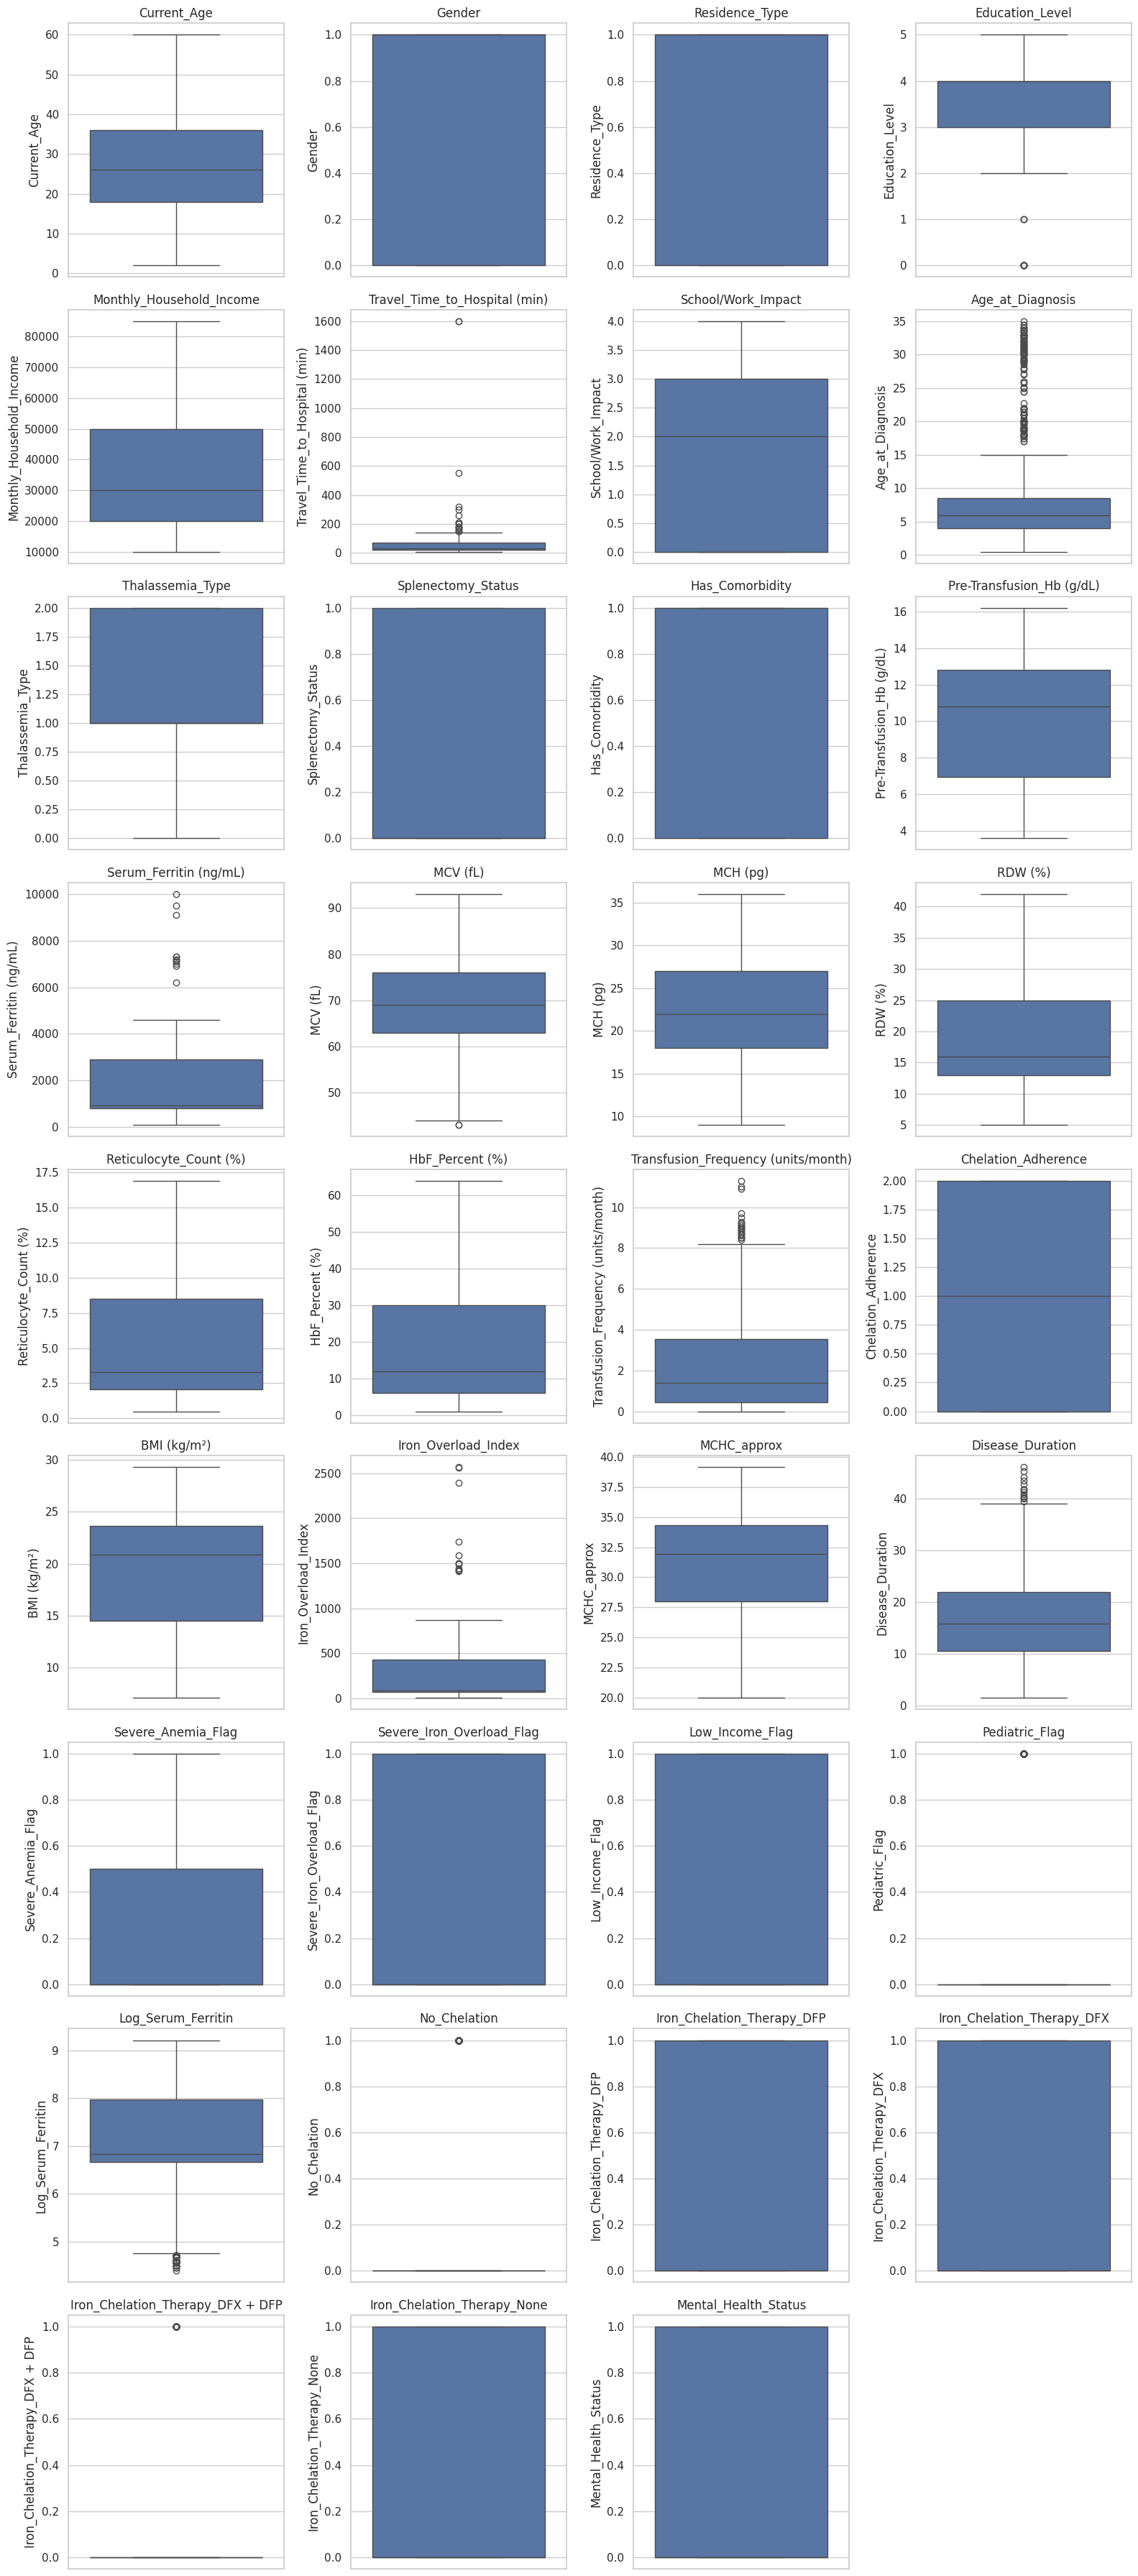

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

num_cols = df.select_dtypes(include=['int64','float64']).columns

n_cols = 4
n_rows = math.ceil(len(num_cols) / n_cols)

plt.figure(figsize=(16, 4*n_rows))

for i, col in enumerate(num_cols):
    plt.subplot(n_rows, n_cols, i+1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

# **Histogram**

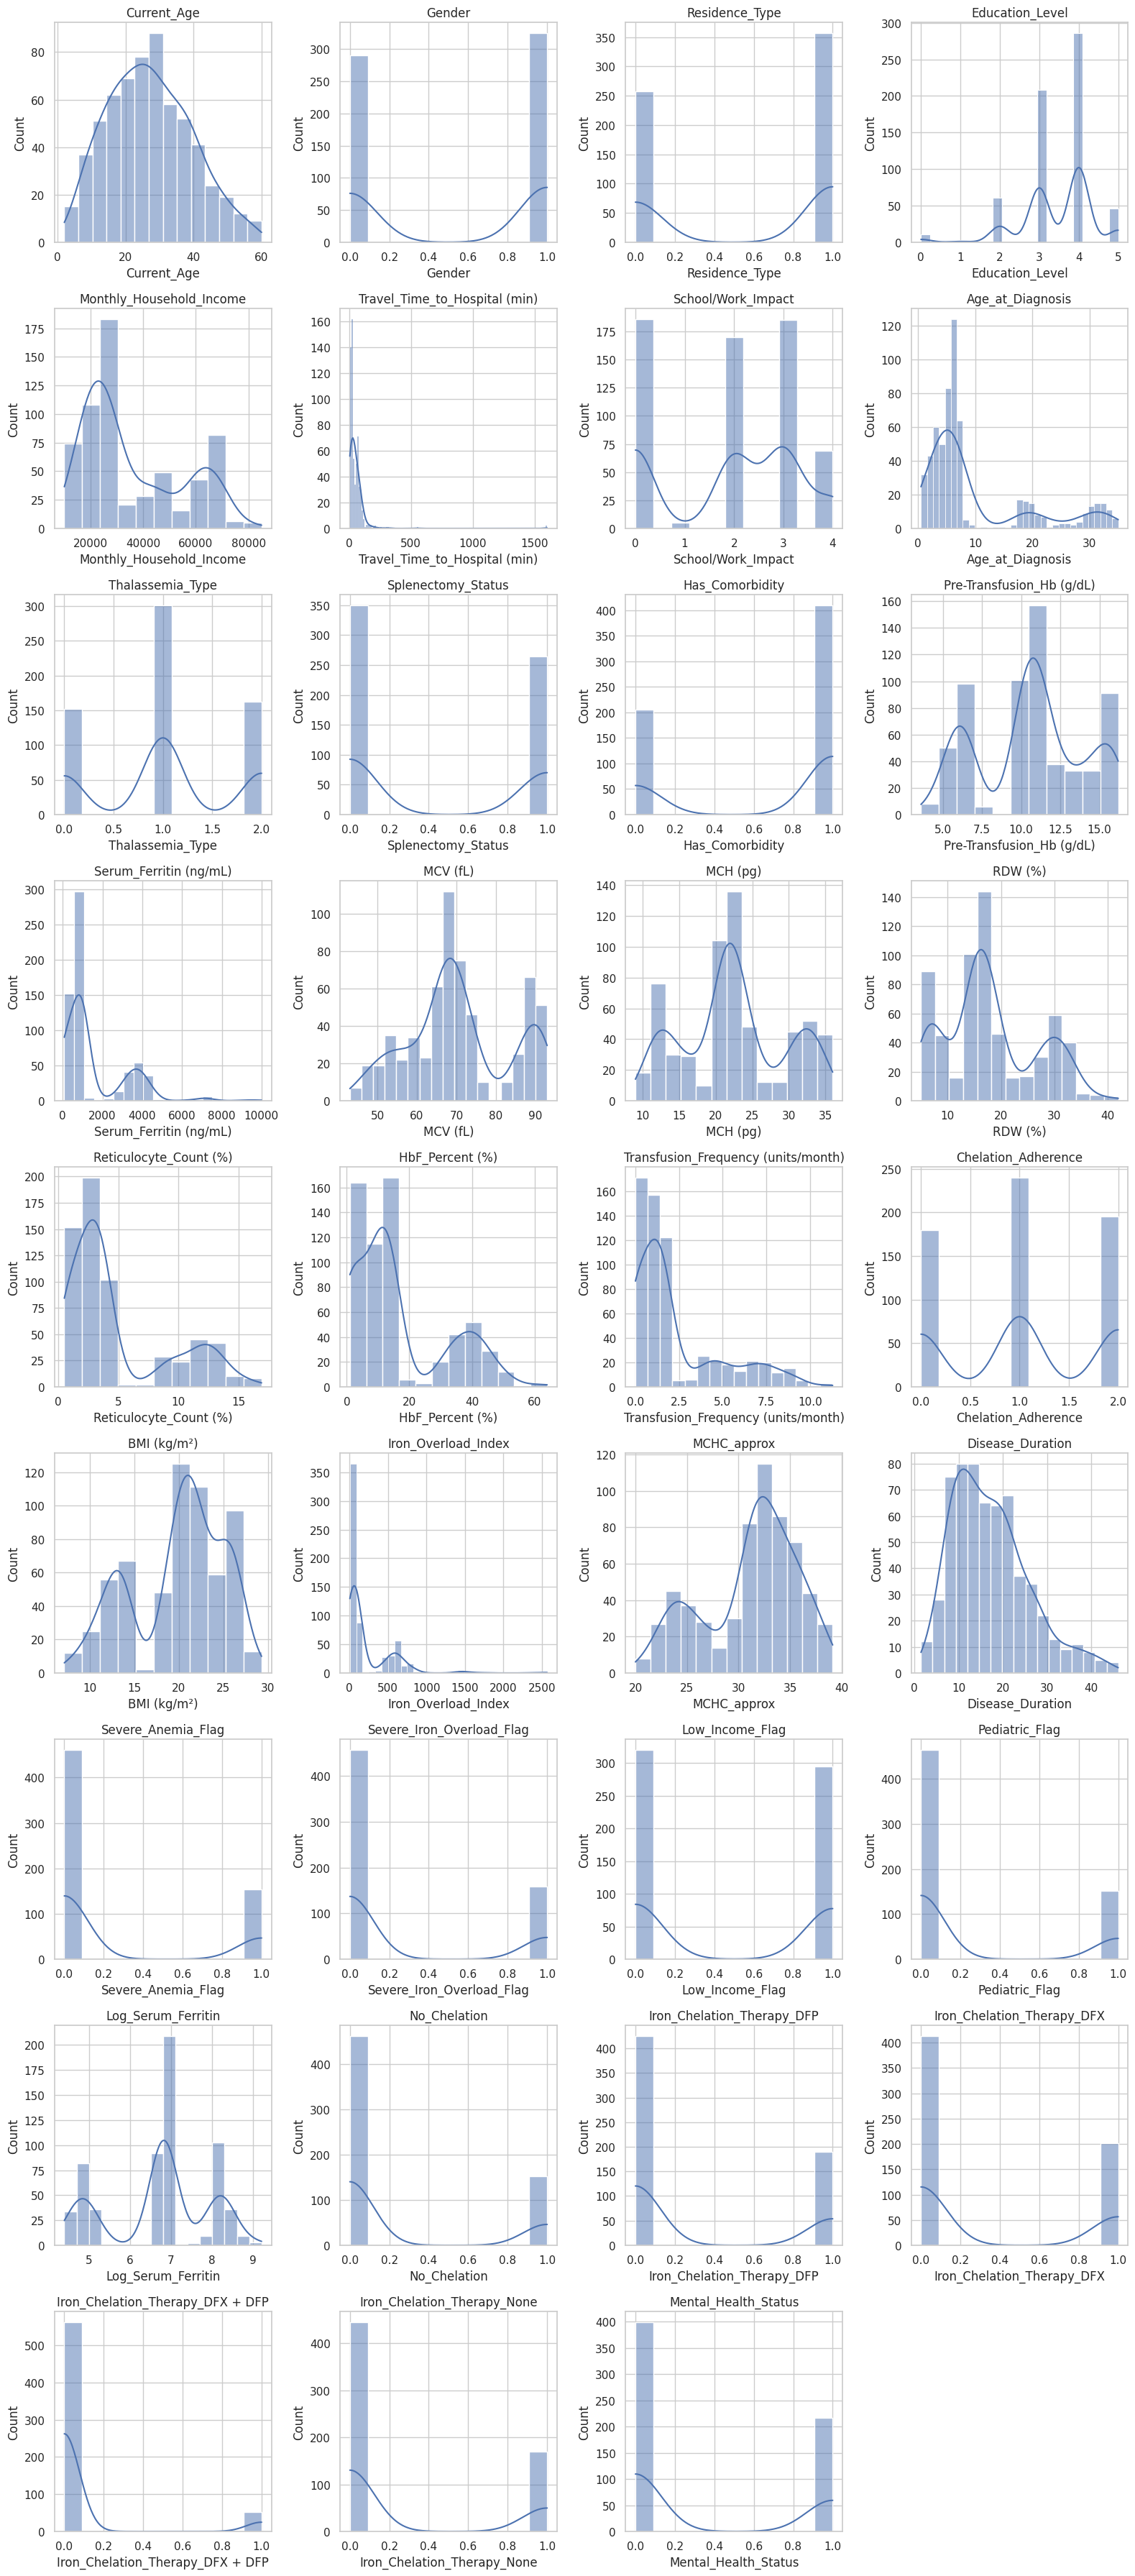

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

num_cols = df.select_dtypes(include=['int64','float64']).columns

n_cols = 4
n_rows = math.ceil(len(num_cols) / n_cols)

plt.figure(figsize=(16,4*n_rows))

for i, col in enumerate(num_cols):
    plt.subplot(n_rows, n_cols, i+1)
    sns.histplot(df[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

# **Correlation Heatmap**

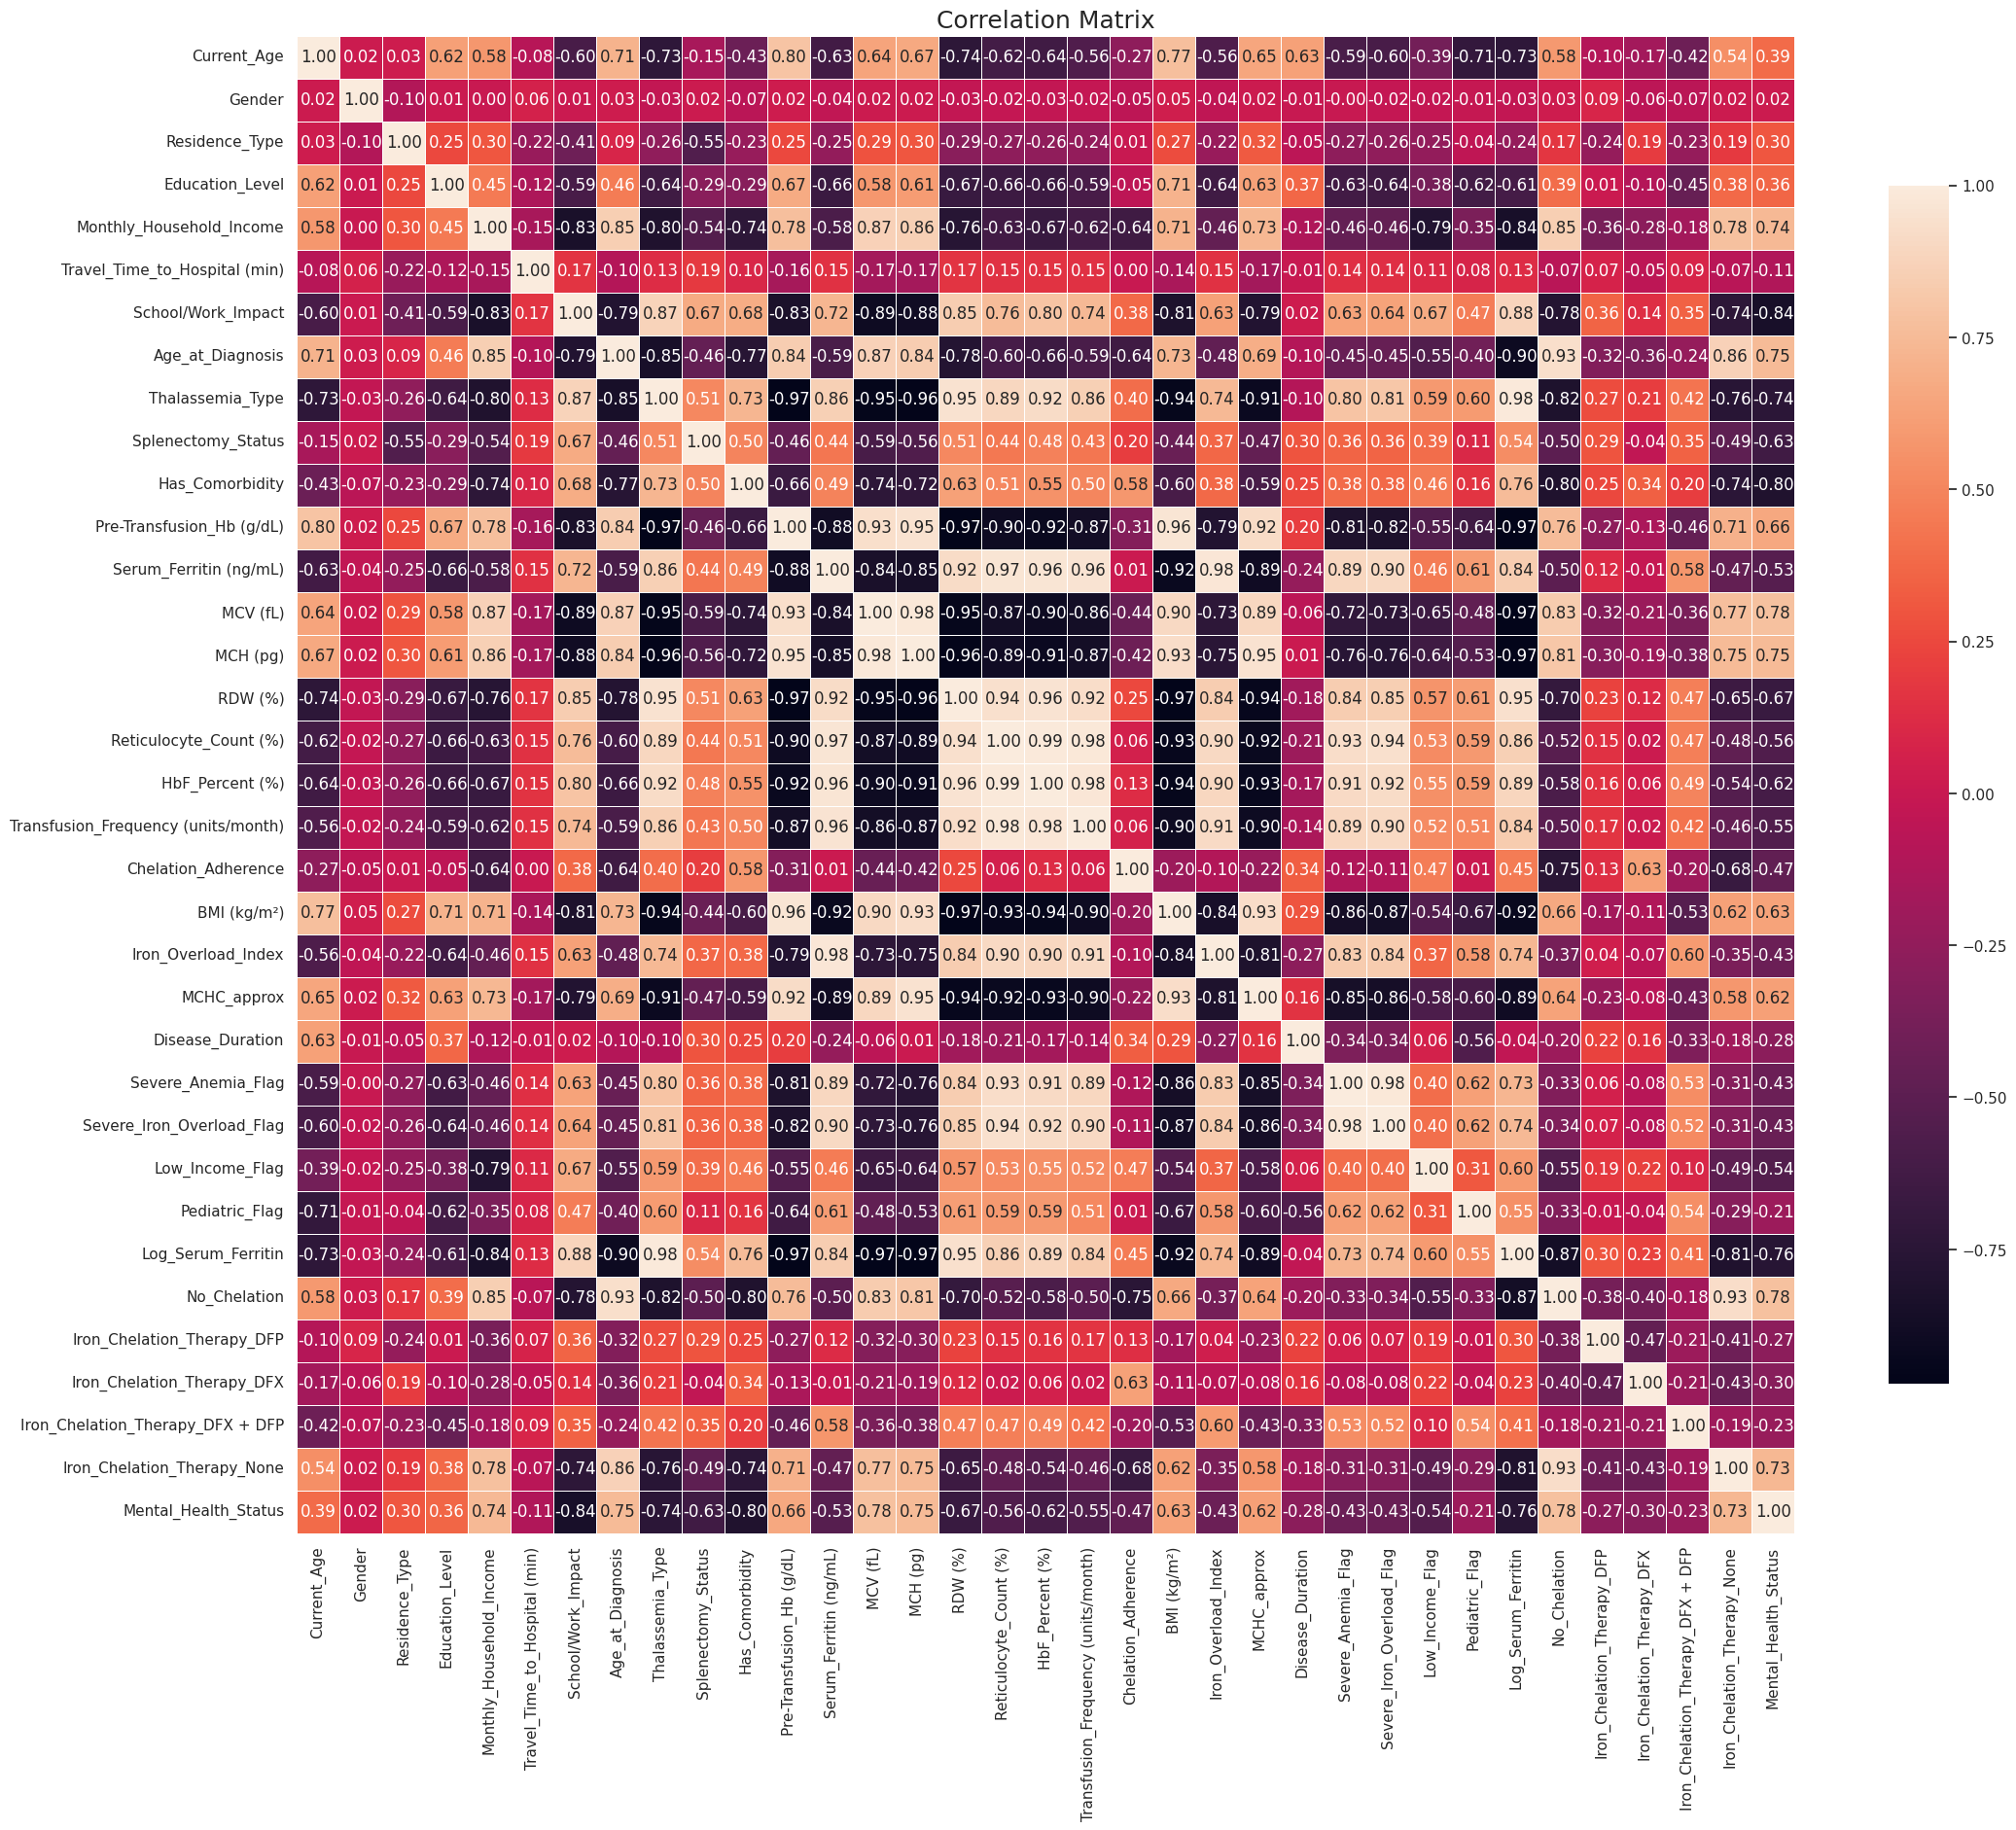

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(25,20))

corr = df.corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink":0.8}
)

plt.title("Correlation Matrix", fontsize=18)
plt.show()

In [ ]:
df.shape

(615, 35)

# **Pairplot**

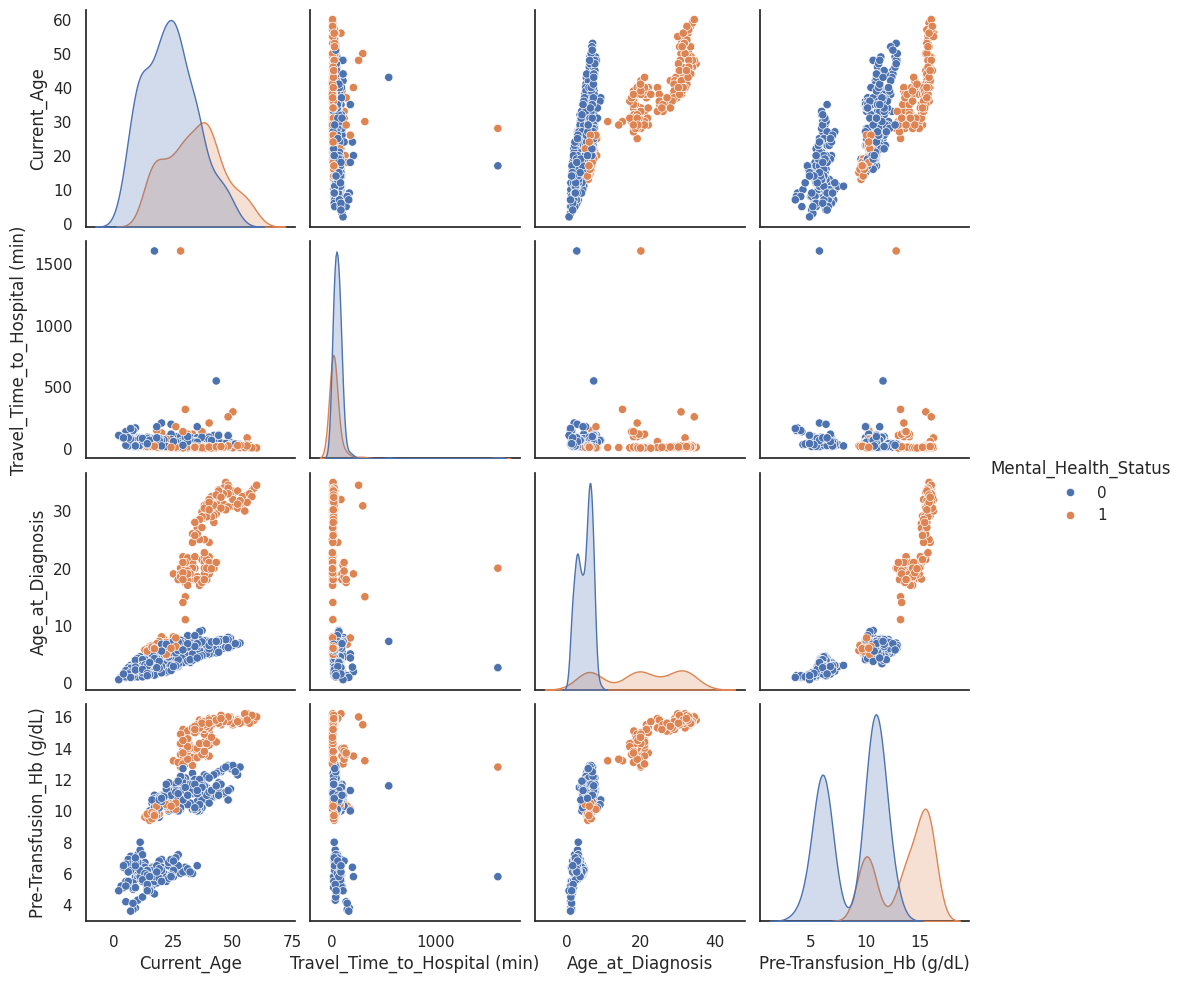

In [ ]:
import seaborn as sns
sns.set(style="white", color_codes=True)

import seaborn as sns

# Select specific columns
columns_to_include = ['Current_Age', 'Travel_Time_to_Hospital (min)', 'Age_at_Diagnosis', 'Pre-Transfusion_Hb (g/dL)']

# Plot
sns.pairplot(df.sample(n=615), vars=columns_to_include, hue="Mental_Health_Status")


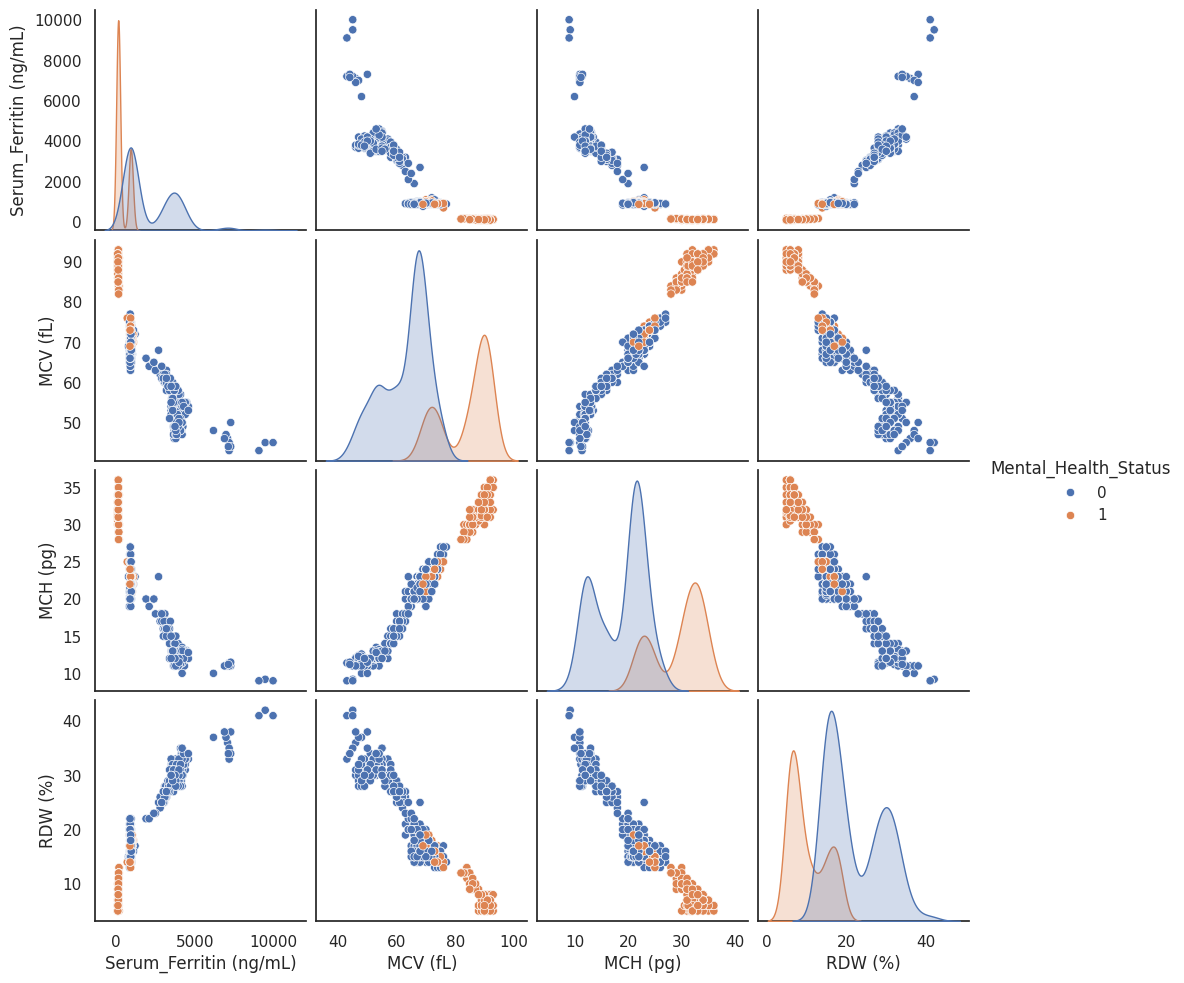

In [ ]:
import seaborn as sns
sns.set(style="white", color_codes=True)

import seaborn as sns

# Select specific columns
columns_to_include = ['Serum_Ferritin (ng/mL)', 'MCV (fL)', 'MCH (pg)', 'RDW (%)']

# Plot
sns.pairplot(df.sample(n=615), vars=columns_to_include, hue="Mental_Health_Status")


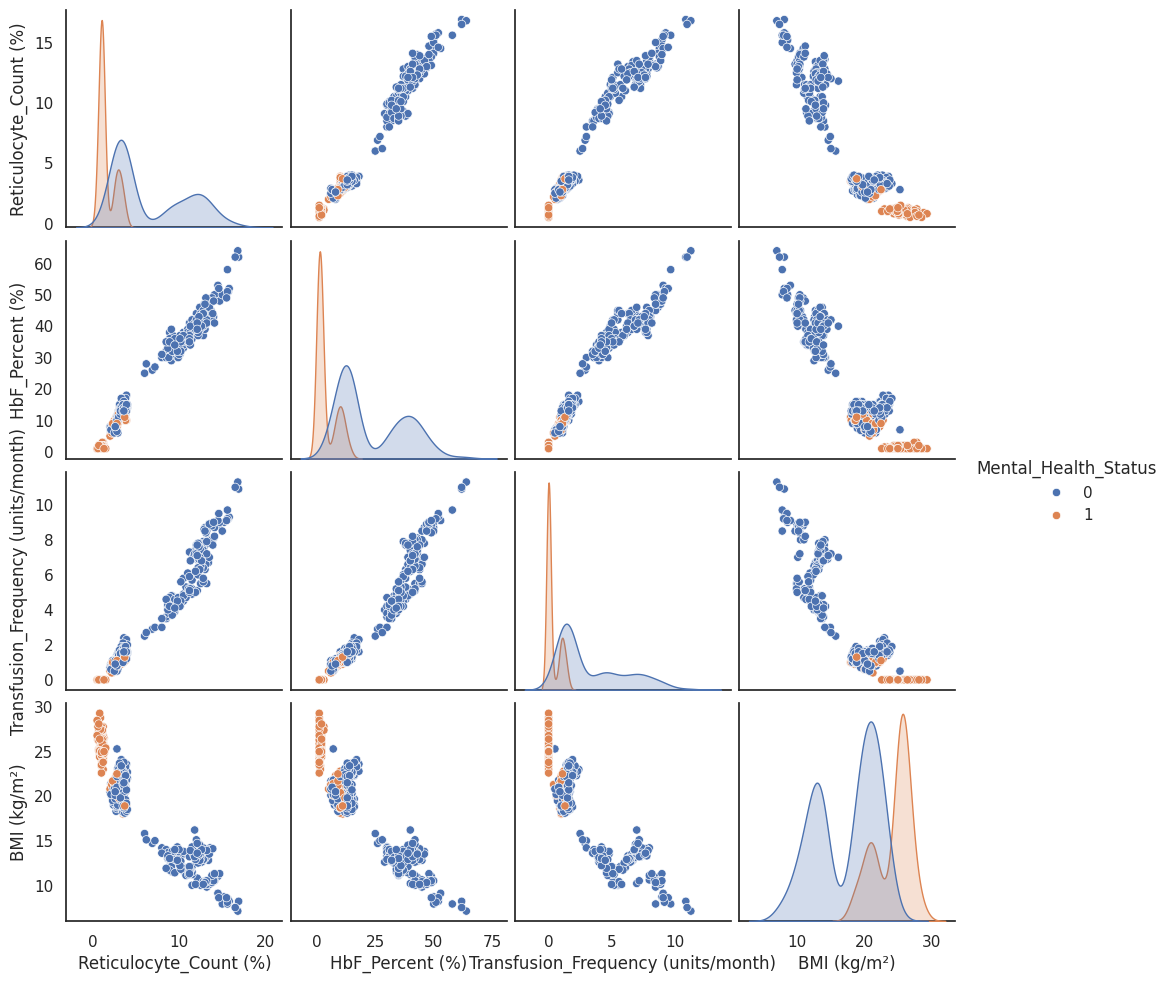

In [ ]:
import seaborn as sns
sns.set(style="white", color_codes=True)

import seaborn as sns

# Select specific columns
columns_to_include = ['Reticulocyte_Count (%)', 'HbF_Percent (%)', 'Transfusion_Frequency (units/month)', 'BMI (kg/m²)']

# Plot
sns.pairplot(df.sample(n=615), vars=columns_to_include, hue="Mental_Health_Status")


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 615 entries, 0 to 616
Data columns (total 35 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Current_Age                          615 non-null    int64  
 1   Gender                               615 non-null    int64  
 2   Residence_Type                       615 non-null    int64  
 3   Education_Level                      615 non-null    float64
 4   Monthly_Household_Income             615 non-null    int64  
 5   Travel_Time_to_Hospital (min)        615 non-null    int64  
 6   School/Work_Impact                   615 non-null    float64
 7   Age_at_Diagnosis                     615 non-null    float64
 8   Thalassemia_Type                     615 non-null    float64
 9   Splenectomy_Status                   615 non-null    int64  
 10  Has_Comorbidity                      615 non-null    int64  
 11  Pre-Transfusion_Hb (g/dL)            

# **Remove Bad Features**

In [ ]:
cols_to_drop = [
    'School/Work_Impact',
    'Splenectomy_Status',
    'Iron_Chelation_Therapy_None',
    'No_Chelation',
    'Chelation_Adherence',
    'Transfusion_Frequency (units/month)',
    'Has_Comorbidity',
    'Iron_Chelation_Therapy_DFX + DFP',
    'Iron_Chelation_Therapy_DFP',
    'Iron_Chelation_Therapy_DFX'
]

df = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

# cols_to_drop = [
#     'School/Work_Impact',
#     'Has_Comorbidity'
# ]

# df = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

In [ ]:
df.shape

(615, 25)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 615 entries, 0 to 616
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Current_Age                    615 non-null    int64  
 1   Gender                         615 non-null    int64  
 2   Residence_Type                 615 non-null    int64  
 3   Education_Level                615 non-null    float64
 4   Monthly_Household_Income       615 non-null    int64  
 5   Travel_Time_to_Hospital (min)  615 non-null    int64  
 6   Age_at_Diagnosis               615 non-null    float64
 7   Thalassemia_Type               615 non-null    float64
 8   Pre-Transfusion_Hb (g/dL)      615 non-null    float64
 9   Serum_Ferritin (ng/mL)         615 non-null    int64  
 10  MCV (fL)                       615 non-null    int64  
 11  MCH (pg)                       615 non-null    float64
 12  RDW (%)                        615 non-null    int64  


# **Train-Test Splitting**

In [ ]:
# segregating dataset into features i.e., X and target variables i.e., y
X = df.drop(['Mental_Health_Status'], axis=1)
y = df['Mental_Health_Status']

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, shuffle=True, random_state=42)

In [ ]:
# Repeated CV
from sklearn.model_selection import RepeatedStratifiedKFold

rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)

In [ ]:
## checking distribution of traget variable in train test split
print('Distribution of traget variable in training set')
print(y_train.value_counts())

print('Distribution of traget variable in test set')
print(y_test.value_counts())

Distribution of traget variable in training set
Mental_Health_Status
0    319
1    173
Name: count, dtype: int64
Distribution of traget variable in test set
Mental_Health_Status
0    80
1    43
Name: count, dtype: int64


# **Apply ML Algorithms with SMOTE**

In [ ]:
comp_ev = pd.DataFrame({
    'Model'                  : [],
    'Accuracy(cv)'           : [],
    'Precision(cv)'          : [],
    'Recall(cv)'             : [],
    'F1_score(cv)'           : [],
    'ROC(cv)'                : [],
    'Log_Loss(cv)'           : [],
    'mathew_corrcoef(cv)'    : [],
    'Accuracy(test)'         : [],
    'Precision(test)'        : [],
    'Recall(test)'           : [],
    'F1_score(test)'         : [],
    'ROC(test)'              : [],
    'Log_Loss(test)'         : [],
    'mathew_corrcoef(test)'  : []
})

# **LR**

Fold-wise Results (Logistic Regression - WITH SMOTE):

Fold 1 → Acc:0.838 | Prec:0.822 | Recall:0.836 | F1:0.827 | ROC:0.951 | LogLoss:0.287 | MCC:0.658
Confusion Matrix (Fold 1):
[[54 10]
 [ 6 29]]

Fold 2 → Acc:0.909 | Prec:0.898 | Recall:0.930 | F1:0.905 | ROC:0.988 | LogLoss:0.257 | MCC:0.827
Confusion Matrix (Fold 2):
[[55  9]
 [ 0 35]]

Fold 3 → Acc:0.888 | Prec:0.874 | Recall:0.894 | F1:0.881 | ROC:0.975 | LogLoss:0.275 | MCC:0.768
Confusion Matrix (Fold 3):
[[55  8]
 [ 3 32]]

Fold 4 → Acc:0.929 | Prec:0.916 | Recall:0.932 | F1:0.923 | ROC:0.993 | LogLoss:0.205 | MCC:0.847
Confusion Matrix (Fold 4):
[[59  5]
 [ 2 32]]

Fold 5 → Acc:0.898 | Prec:0.883 | Recall:0.901 | F1:0.890 | ROC:0.983 | LogLoss:0.222 | MCC:0.784
Confusion Matrix (Fold 5):
[[57  7]
 [ 3 31]]


===== CV Fold Average Metrics (WITH SMOTE) =====
Accuracy: 0.8924 ± 0.0302
Precision: 0.8785 ± 0.0317
Recall: 0.8984 ± 0.0346
F1: 0.8853 ± 0.0322
ROC: 0.9779 ± 0.0147
LogLoss: 0.2490 ± 0.0313
MCC: 0.7767 ± 0.0660


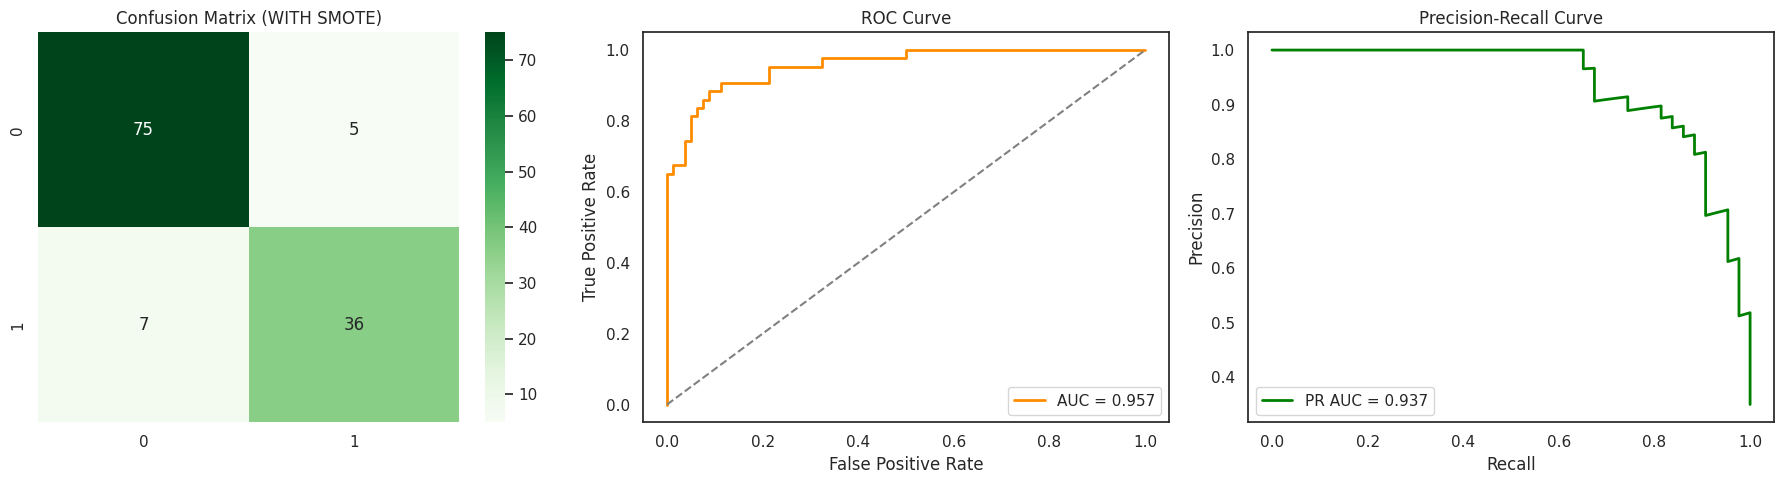



===== Repeated Stratified K-Fold CV (Logistic Regression with SMOTE) =====

===== Repeated CV Results (n_splits=5, n_repeats=10, total runs=50) =====
Accuracy: 0.8915 ± 0.0291
Precision: 0.8805 ± 0.0322
Recall: 0.8945 ± 0.0293
F1: 0.8839 ± 0.0304
ROC: 0.9781 ± 0.0101
LogLoss: 0.2481 ± 0.0250
MCC: 0.7746 ± 0.0587


,Model,Accuracy(cv),Precision(cv),Recall(cv),F1_score(cv),ROC(cv),Log_Loss(cv),mathew_corrcoef(cv),Accuracy(test),Precision(test),Recall(test),F1_score(test),ROC(test),Log_Loss(test),mathew_corrcoef(test)
0,LR (SMOTE),0.892352,0.878519,0.898444,0.88535,0.97791,0.248953,0.776687,0.902439,0.896341,0.887355,0.891534,0.956686,0.268969,0.783645


In [ ]:
from sklearn.model_selection import StratifiedKFold, RepeatedStratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, log_loss, matthews_corrcoef, confusion_matrix,
                             roc_curve, auc, precision_recall_curve)
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE

# ============================================================
# PART 1: 5-Fold Stratified Cross-Validation
# (X_train, X_test = RAW / UNSCALED data)
# ============================================================

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_acc, fold_precision, fold_recall = [], [], []
fold_f1, fold_roc, fold_logloss, fold_mcc = [], [], [], []

# X_train ke numpy array e convert kore nilam (DataFrame hole .values dorkar)
X_train_arr = X_train.values if hasattr(X_train, "values") else X_train
y_train_arr = y_train.values if hasattr(y_train, "values") else y_train

print("Fold-wise Results (Logistic Regression - WITH SMOTE):\n")

for i, (train_idx, val_idx) in enumerate(kf.split(X_train_arr, y_train_arr), 1):

    X_tr, X_val = X_train_arr[train_idx], X_train_arr[val_idx]
    y_tr, y_val = y_train_arr[train_idx], y_train_arr[val_idx]

    # ---- Fold-wise MinMax Scaling (fit ONLY on training fold) ----
    scaler = MinMaxScaler()
    X_tr = scaler.fit_transform(X_tr)
    X_val = scaler.transform(X_val)

    # Apply SMOTE only to the training fold to avoid data leakage
    smote = SMOTE(random_state=42)
    X_tr_resampled, y_tr_resampled = smote.fit_resample(X_tr, y_tr)

    model = LogisticRegression(
        C=0.1,
        solver='liblinear',
        max_iter=500,
        random_state=42
    )

    model.fit(X_tr_resampled, y_tr_resampled)

    y_val_pred = model.predict(X_val)
    y_val_prob = model.predict_proba(X_val)[:, 1]

    acc = accuracy_score(y_val, y_val_pred)
    precision = precision_score(y_val, y_val_pred, average='macro')
    recall = recall_score(y_val, y_val_pred, average='macro')
    f1 = f1_score(y_val, y_val_pred, average='macro')
    roc = roc_auc_score(y_val, y_val_prob)
    logloss_val = log_loss(y_val, y_val_prob)
    mcc_val = matthews_corrcoef(y_val, y_val_pred)
    CM_val = confusion_matrix(y_val, y_val_pred)

    fold_acc.append(acc)
    fold_precision.append(precision)
    fold_recall.append(recall)
    fold_f1.append(f1)
    fold_roc.append(roc)
    fold_logloss.append(logloss_val)
    fold_mcc.append(mcc_val)

    print(
        f"Fold {i} → "
        f"Acc:{acc:.3f} | "
        f"Prec:{precision:.3f} | "
        f"Recall:{recall:.3f} | "
        f"F1:{f1:.3f} | "
        f"ROC:{roc:.3f} | "
        f"LogLoss:{logloss_val:.3f} | "
        f"MCC:{mcc_val:.3f}"
    )

    print(f"Confusion Matrix (Fold {i}):\n{CM_val}\n")


# ============================================================
# 5-Fold CV Average Metrics
# ============================================================

print("\n===== CV Fold Average Metrics (WITH SMOTE) =====")

print(f"Accuracy: {np.mean(fold_acc):.4f} ± {np.std(fold_acc):.4f}")
print(f"Precision: {np.mean(fold_precision):.4f} ± {np.std(fold_precision):.4f}")
print(f"Recall: {np.mean(fold_recall):.4f} ± {np.std(fold_recall):.4f}")
print(f"F1: {np.mean(fold_f1):.4f} ± {np.std(fold_f1):.4f}")
print(f"ROC: {np.mean(fold_roc):.4f} ± {np.std(fold_roc):.4f}")
print(f"LogLoss: {np.mean(fold_logloss):.4f} ± {np.std(fold_logloss):.4f}")
print(f"MCC: {np.mean(fold_mcc):.4f} ± {np.std(fold_mcc):.4f}")


# ============================================================
# Train the Final Model Using the Entire Training Set + SMOTE
# (Final scaler fit on FULL training set, then applied to test set)
# ============================================================

final_scaler = MinMaxScaler()
X_train_scaled_final = final_scaler.fit_transform(X_train_arr)

X_test_arr = X_test.values if hasattr(X_test, "values") else X_test
X_test_scaled_final = final_scaler.transform(X_test_arr)   # only transform, NOT fit

smote_final = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote_final.fit_resample(
    X_train_scaled_final,
    y_train_arr
)

final_model = LogisticRegression(
    C=0.1,
    solver='liblinear',
    max_iter=500,
    random_state=42
)

final_model.fit(X_train_resampled, y_train_resampled)


# ============================================================
# CV Metrics (renamed from "train" to "CV" for clarity)
# ============================================================

acc_cv = np.mean(fold_acc)
precision_cv = np.mean(fold_precision)
recall_cv = np.mean(fold_recall)
f1_cv = np.mean(fold_f1)
roc_cv = np.mean(fold_roc)
logloss_cv = np.mean(fold_logloss)
mcc_cv = np.mean(fold_mcc)


# ============================================================
# Test Set Evaluation
# ============================================================

y_test_arr = y_test.values if hasattr(y_test, "values") else y_test

y_test_pred = final_model.predict(X_test_scaled_final)
y_test_prob = final_model.predict_proba(X_test_scaled_final)[:, 1]

acc_test = accuracy_score(y_test_arr, y_test_pred)
precision_test = precision_score(y_test_arr, y_test_pred, average='macro')
recall_test = recall_score(y_test_arr, y_test_pred, average='macro')
f1_test = f1_score(y_test_arr, y_test_pred, average='macro')
roc_test = roc_auc_score(y_test_arr, y_test_prob)
logloss_test = log_loss(y_test_arr, y_test_prob)
mcc_test = matthews_corrcoef(y_test_arr, y_test_pred)


# ============================================================
# Confusion Matrix, ROC Curve, and Precision-Recall Curve
# ============================================================

CM = confusion_matrix(y_test_arr, y_test_pred)

fpr, tpr, _ = roc_curve(y_test_arr, y_test_prob)
roc_auc = auc(fpr, tpr)

precision_vals, recall_vals, _ = precision_recall_curve(
    y_test_arr,
    y_test_prob
)

pr_auc = auc(recall_vals, precision_vals)


plt.figure(figsize=(18, 5))

# Confusion Matrix
plt.subplot(1, 3, 1)
sns.heatmap(CM, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix (WITH SMOTE)")

# ROC Curve
plt.subplot(1, 3, 2)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}", color='darkorange', lw=2)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")

# Precision-Recall Curve
plt.subplot(1, 3, 3)
plt.plot(recall_vals, precision_vals, label=f"PR AUC = {pr_auc:.3f}", color='green', lw=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend(loc="lower left")

plt.tight_layout()
plt.show()


# ============================================================
# PART 2: Repeated Stratified K-Fold Cross-Validation
# Purpose: Assess the stability and robustness of the model
# across multiple train-validation splits.
# ============================================================

N_SPLITS = 5
N_REPEATS = 10

rskf = RepeatedStratifiedKFold(
    n_splits=N_SPLITS,
    n_repeats=N_REPEATS,
    random_state=42
)

rep_acc, rep_precision, rep_recall = [], [], []
rep_f1, rep_roc, rep_logloss, rep_mcc = [], [], [], []

print(
    "\n\n===== Repeated Stratified K-Fold CV "
    "(Logistic Regression with SMOTE) =====\n"
)

for i, (train_idx, val_idx) in enumerate(
    rskf.split(X_train_arr, y_train_arr),
    1
):

    X_tr, X_val = X_train_arr[train_idx], X_train_arr[val_idx]
    y_tr, y_val = y_train_arr[train_idx], y_train_arr[val_idx]

    # ---- Fold-wise MinMax Scaling (fit ONLY on training fold) ----
    scaler_rep = MinMaxScaler()
    X_tr = scaler_rep.fit_transform(X_tr)
    X_val = scaler_rep.transform(X_val)

    # Apply SMOTE only to the training fold to avoid data leakage
    smote_rep = SMOTE(random_state=42)

    X_tr_resampled, y_tr_resampled = smote_rep.fit_resample(
        X_tr,
        y_tr
    )

    model_rep = LogisticRegression(
        C=0.1,
        solver='liblinear',
        max_iter=500,
        random_state=42
    )

    model_rep.fit(
        X_tr_resampled,
        y_tr_resampled
    )

    y_val_pred = model_rep.predict(X_val)
    y_val_prob = model_rep.predict_proba(X_val)[:, 1]

    rep_acc.append(accuracy_score(y_val, y_val_pred))
    rep_precision.append(precision_score(y_val, y_val_pred, average='macro'))
    rep_recall.append(recall_score(y_val, y_val_pred, average='macro'))
    rep_f1.append(f1_score(y_val, y_val_pred, average='macro'))
    rep_roc.append(roc_auc_score(y_val, y_val_prob))
    rep_logloss.append(log_loss(y_val, y_val_prob))
    rep_mcc.append(matthews_corrcoef(y_val, y_val_pred))


# ============================================================
# Repeated CV Mean and Standard Deviation
# ============================================================

print(
    f"===== Repeated CV Results "
    f"(n_splits={N_SPLITS}, "
    f"n_repeats={N_REPEATS}, "
    f"total runs={N_SPLITS * N_REPEATS}) ====="
)

print(f"Accuracy: {np.mean(rep_acc):.4f} ± {np.std(rep_acc):.4f}")
print(f"Precision: {np.mean(rep_precision):.4f} ± {np.std(rep_precision):.4f}")
print(f"Recall: {np.mean(rep_recall):.4f} ± {np.std(rep_recall):.4f}")
print(f"F1: {np.mean(rep_f1):.4f} ± {np.std(rep_f1):.4f}")
print(f"ROC: {np.mean(rep_roc):.4f} ± {np.std(rep_roc):.4f}")
print(f"LogLoss: {np.mean(rep_logloss):.4f} ± {np.std(rep_logloss):.4f}")
print(f"MCC: {np.mean(rep_mcc):.4f} ± {np.std(rep_mcc):.4f}")


# ============================================================
# Store Repeated CV Results for Reporting
# These values are NOT added to comp_ev.
# ============================================================

acc_repcv = np.mean(rep_acc)
acc_repcv_std = np.std(rep_acc)

f1_repcv = np.mean(rep_f1)
f1_repcv_std = np.std(rep_f1)

mcc_repcv = np.mean(rep_mcc)
mcc_repcv_std = np.std(rep_mcc)


# ============================================================
# PART 3: Add Logistic Regression Results to comp_ev
# CV metrics (5-Fold) + Test metrics only.
# Repeated CV results are NOT added to the DataFrame.
# ============================================================

r = comp_ev.shape[0]
comp_ev.loc[r] = ['LR (SMOTE)', acc_cv, precision_cv, recall_cv, f1_cv, roc_cv,
                  logloss_cv, mcc_cv, acc_test, precision_test, recall_test, f1_test, roc_test,
                  logloss_test, mcc_test]

comp_ev = comp_ev.sort_values(by='Accuracy(test)', ascending=False).reset_index(drop=True)
comp_ev

# **DT**

Fold-wise Results (Decision Tree - WITH SMOTE):

Fold 1 → Acc:0.960 | Prec:0.962 | Recall:0.949 | F1:0.955 | ROC:0.983 | LogLoss:0.439 | MCC:0.911
Confusion Matrix (Fold 1):
[[63  1]
 [ 3 32]]

Fold 2 → Acc:0.939 | Prec:0.947 | Recall:0.921 | F1:0.932 | ROC:0.990 | LogLoss:0.141 | MCC:0.867
Confusion Matrix (Fold 2):
[[63  1]
 [ 5 30]]

Fold 3 → Acc:0.949 | Prec:0.954 | Recall:0.935 | F1:0.943 | ROC:0.971 | LogLoss:0.797 | MCC:0.889
Confusion Matrix (Fold 3):
[[62  1]
 [ 4 31]]

Fold 4 → Acc:0.949 | Prec:0.936 | Recall:0.961 | F1:0.945 | ROC:0.990 | LogLoss:0.469 | MCC:0.896
Confusion Matrix (Fold 4):
[[59  5]
 [ 0 34]]

Fold 5 → Acc:0.959 | Prec:0.950 | Recall:0.962 | F1:0.956 | ROC:0.980 | LogLoss:0.449 | MCC:0.912
Confusion Matrix (Fold 5):
[[61  3]
 [ 1 33]]


===== CV Fold Average Metrics (DT WITH SMOTE) =====
Accuracy: 0.9512 ± 0.0075
Precision: 0.9499 ± 0.0086
Recall: 0.9456 ± 0.0158
F1: 0.9463 ± 0.0088
ROC: 0.9828 ± 0.0069
LogLoss: 0.4591 ± 0.2080
MCC: 0.8952 ± 0.0165


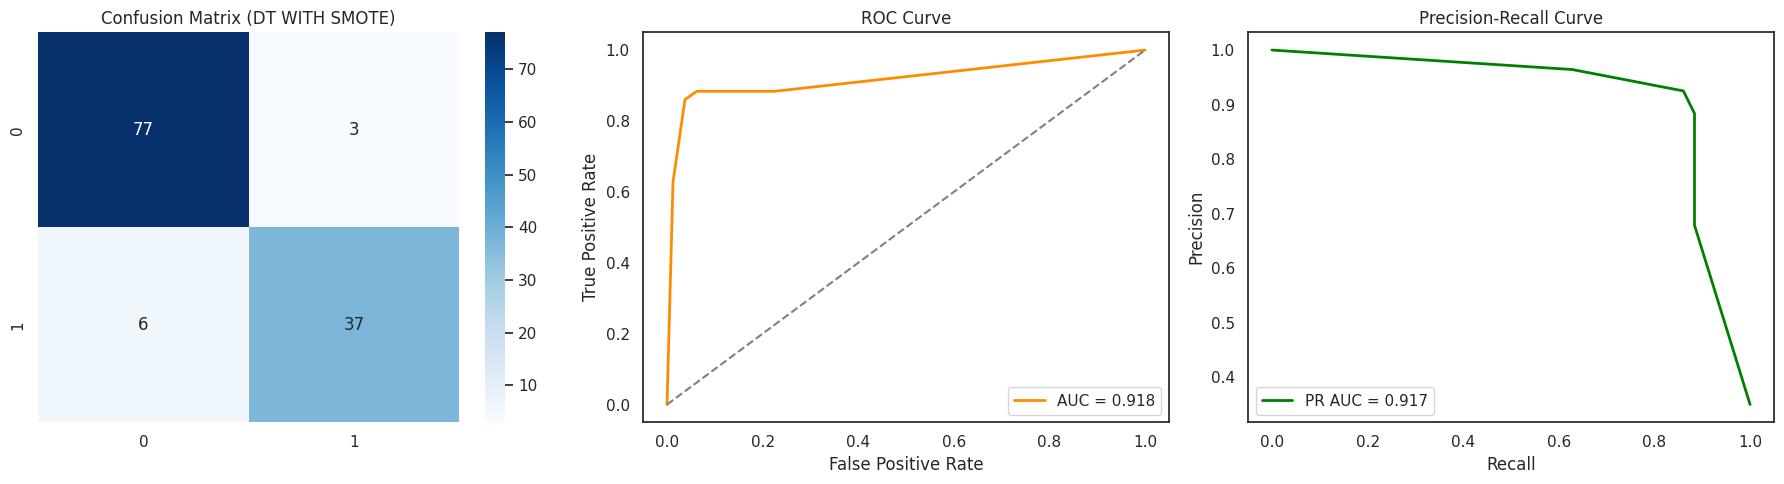


===== Decision Tree Evaluation (WITH SMOTE) =====
AUC (ROC) : 0.9179
PR-AUC    : 0.9172


===== Repeated Stratified K-Fold CV (Decision Tree with SMOTE) =====

===== Repeated CV Results (n_splits=5, n_repeats=10, total runs=50) =====
Accuracy: 0.9508 ± 0.0211
Precision: 0.9471 ± 0.0245
Recall: 0.9469 ± 0.0226
F1: 0.9462 ± 0.0228
ROC: 0.9794 ± 0.0176
LogLoss: 0.5144 ± 0.4849
MCC: 0.8939 ± 0.0451


,Model,Accuracy(cv),Precision(cv),Recall(cv),F1_score(cv),ROC(cv),Log_Loss(cv),mathew_corrcoef(cv),Accuracy(test),Precision(test),Recall(test),F1_score(test),ROC(test),Log_Loss(test),mathew_corrcoef(test)
0,DT (SMOTE),0.951227,0.949893,0.945561,0.946262,0.982819,0.459084,0.895230,0.926829,0.926355,0.911483,0.918176,0.917878,1.835286,0.837706
1,LR (SMOTE),0.892352,0.878519,0.898444,0.885350,0.977910,0.248953,0.776687,0.902439,0.896341,0.887355,0.891534,0.956686,0.268969,0.783645


In [ ]:
from imblearn.over_sampling import SMOTE                    # <-- Import SMOTE
from sklearn.model_selection import StratifiedKFold, RepeatedStratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, log_loss, matthews_corrcoef, confusion_matrix,
                             roc_curve, auc, precision_recall_curve)
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# ====== K-Fold Cross Validation WITH SMOTE + Fold-wise Scaling ======
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_acc, fold_precision, fold_recall = [], [], []
fold_f1, fold_roc, fold_logloss, fold_mcc = [], [], [], []

# Raw (unscaled) data
X_train_arr = X_train.values if hasattr(X_train, "values") else X_train
y_train_arr = y_train.values if hasattr(y_train, "values") else y_train

print("Fold-wise Results (Decision Tree - WITH SMOTE):\n")

for i, (train_idx, val_idx) in enumerate(kf.split(X_train_arr, y_train_arr), 1):
    X_tr, X_val = X_train_arr[train_idx], X_train_arr[val_idx]
    y_tr, y_val = y_train_arr[train_idx], y_train_arr[val_idx]

    # ---- Fold-wise MinMax Scaling (fit ONLY on training fold) ----
    scaler = MinMaxScaler()
    X_tr = scaler.fit_transform(X_tr)
    X_val = scaler.transform(X_val)

    # Apply SMOTE only to the training fold (no data leakage)
    smote = SMOTE(random_state=42)
    X_tr_resampled, y_tr_resampled = smote.fit_resample(X_tr, y_tr)

    # Model with pruning parameters
    model = DecisionTreeClassifier(
        max_depth=5,
        min_samples_leaf=10,
        criterion='gini',
        random_state=42
    )
    model.fit(X_tr_resampled, y_tr_resampled)                # Train on resampled fold

    # Predict on the original (unresampled) validation set
    y_val_pred = model.predict(X_val)
    y_val_prob = model.predict_proba(X_val)[:,1]

    # Metrics
    acc = accuracy_score(y_val, y_val_pred)
    precision = precision_score(y_val, y_val_pred, average='macro')
    recall = recall_score(y_val, y_val_pred, average='macro')
    f1 = f1_score(y_val, y_val_pred, average='macro')
    roc = roc_auc_score(y_val, y_val_prob)
    logloss_val = log_loss(y_val, y_val_prob)
    mcc_val = matthews_corrcoef(y_val, y_val_pred)
    CM_val = confusion_matrix(y_val, y_val_pred)

    fold_acc.append(acc)
    fold_precision.append(precision)
    fold_recall.append(recall)
    fold_f1.append(f1)
    fold_roc.append(roc)
    fold_logloss.append(logloss_val)
    fold_mcc.append(mcc_val)

    print(f"Fold {i} → Acc:{acc:.3f} | Prec:{precision:.3f} | Recall:{recall:.3f} | "
          f"F1:{f1:.3f} | ROC:{roc:.3f} | LogLoss:{logloss_val:.3f} | MCC:{mcc_val:.3f}")
    print(f"Confusion Matrix (Fold {i}):\n{CM_val}\n")

# ===== Fold-wise averages =====
print("\n===== CV Fold Average Metrics (DT WITH SMOTE) =====")
print(f"Accuracy: {np.mean(fold_acc):.4f} ± {np.std(fold_acc):.4f}")
print(f"Precision: {np.mean(fold_precision):.4f} ± {np.std(fold_precision):.4f}")
print(f"Recall: {np.mean(fold_recall):.4f} ± {np.std(fold_recall):.4f}")
print(f"F1: {np.mean(fold_f1):.4f} ± {np.std(fold_f1):.4f}")
print(f"ROC: {np.mean(fold_roc):.4f} ± {np.std(fold_roc):.4f}")
print(f"LogLoss: {np.mean(fold_logloss):.4f} ± {np.std(fold_logloss):.4f}")
print(f"MCC: {np.mean(fold_mcc):.4f} ± {np.std(fold_mcc):.4f}")

# ===== Train final model (WITH SMOTE) =====
# Final scaler: pura training set diye fit, test set e শুধু transform
final_scaler = MinMaxScaler()
X_train_scaled_final = final_scaler.fit_transform(X_train_arr)

X_test_arr = X_test.values if hasattr(X_test, "values") else X_test
X_test_scaled_final = final_scaler.transform(X_test_arr)

smote_final = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote_final.fit_resample(X_train_scaled_final, y_train_arr)

final_model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=10,
    criterion='gini',
    random_state=42
)
final_model.fit(X_train_resampled, y_train_resampled)

# ===== CV metrics (renamed train -> cv) =====
acc_cv       = np.mean(fold_acc)
precision_cv = np.mean(fold_precision)
recall_cv    = np.mean(fold_recall)
f1_cv        = np.mean(fold_f1)
roc_cv       = np.mean(fold_roc)
logloss_cv   = np.mean(fold_logloss)
mcc_cv       = np.mean(fold_mcc)

# ===== Test metrics =====
y_test_arr = y_test.values if hasattr(y_test, "values") else y_test

y_test_pred = final_model.predict(X_test_scaled_final)
y_test_prob = final_model.predict_proba(X_test_scaled_final)[:,1]

acc_test = accuracy_score(y_test_arr, y_test_pred)
precision_test = precision_score(y_test_arr, y_test_pred, average='macro')
recall_test = recall_score(y_test_arr, y_test_pred, average='macro')
f1_test = f1_score(y_test_arr, y_test_pred, average='macro')
roc_test = roc_auc_score(y_test_arr, y_test_prob)
logloss_test = log_loss(y_test_arr, y_test_prob)
mcc_test = matthews_corrcoef(y_test_arr, y_test_pred)

# ===== Curves =====
CM = confusion_matrix(y_test_arr, y_test_pred)
fpr, tpr, _ = roc_curve(y_test_arr, y_test_prob)
roc_auc = auc(fpr, tpr)
precision_vals, recall_vals, _ = precision_recall_curve(y_test_arr, y_test_prob)
pr_auc = auc(recall_vals, precision_vals)

plt.figure(figsize=(18,5))

plt.subplot(1,3,1)
sns.heatmap(CM, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (DT WITH SMOTE)")

plt.subplot(1,3,2)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}", color='darkorange', lw=2)
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")

plt.subplot(1,3,3)
plt.plot(recall_vals, precision_vals, label=f"PR AUC = {pr_auc:.3f}", color='green', lw=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend(loc="lower left")

plt.tight_layout()
plt.show()

print("\n===== Decision Tree Evaluation (WITH SMOTE) =====")
print(f"AUC (ROC) : {roc_auc:.4f}")
print(f"PR-AUC    : {pr_auc:.4f}")


# ============================================================
# Repeated Stratified K-Fold Cross-Validation (Fold-wise Scaling)
# ============================================================

N_SPLITS = 5
N_REPEATS = 10

rskf = RepeatedStratifiedKFold(
    n_splits=N_SPLITS,
    n_repeats=N_REPEATS,
    random_state=42
)

rep_acc, rep_precision, rep_recall = [], [], []
rep_f1, rep_roc, rep_logloss, rep_mcc = [], [], [], []

print("\n\n===== Repeated Stratified K-Fold CV "
      "(Decision Tree with SMOTE) =====\n")

for i, (train_idx, val_idx) in enumerate(
    rskf.split(X_train_arr, y_train_arr), 1
):

    X_tr, X_val = X_train_arr[train_idx], X_train_arr[val_idx]
    y_tr, y_val = y_train_arr[train_idx], y_train_arr[val_idx]

    # ---- Fold-wise MinMax Scaling (fit ONLY on training fold) ----
    scaler_rep = MinMaxScaler()
    X_tr = scaler_rep.fit_transform(X_tr)
    X_val = scaler_rep.transform(X_val)

    # Apply SMOTE only to the training fold to avoid data leakage
    smote_rep = SMOTE(random_state=42)

    X_tr_resampled, y_tr_resampled = smote_rep.fit_resample(
        X_tr,
        y_tr
    )

    model_rep = DecisionTreeClassifier(
        max_depth=5,
        min_samples_leaf=10,
        criterion='gini',
        random_state=42
    )

    model_rep.fit(
        X_tr_resampled,
        y_tr_resampled
    )

    y_val_pred = model_rep.predict(X_val)
    y_val_prob = model_rep.predict_proba(X_val)[:,1]

    rep_acc.append(accuracy_score(y_val, y_val_pred))
    rep_precision.append(precision_score(y_val, y_val_pred, average='macro'))
    rep_recall.append(recall_score(y_val, y_val_pred, average='macro'))
    rep_f1.append(f1_score(y_val, y_val_pred, average='macro'))
    rep_roc.append(roc_auc_score(y_val, y_val_prob))
    rep_logloss.append(log_loss(y_val, y_val_prob))
    rep_mcc.append(matthews_corrcoef(y_val, y_val_pred))


# ============================================================
# Repeated CV Mean and Standard Deviation
# ============================================================

print(
    f"===== Repeated CV Results "
    f"(n_splits={N_SPLITS}, "
    f"n_repeats={N_REPEATS}, "
    f"total runs={N_SPLITS * N_REPEATS}) ====="
)

print(f"Accuracy: {np.mean(rep_acc):.4f} ± {np.std(rep_acc):.4f}")
print(f"Precision: {np.mean(rep_precision):.4f} ± {np.std(rep_precision):.4f}")
print(f"Recall: {np.mean(rep_recall):.4f} ± {np.std(rep_recall):.4f}")
print(f"F1: {np.mean(rep_f1):.4f} ± {np.std(rep_f1):.4f}")
print(f"ROC: {np.mean(rep_roc):.4f} ± {np.std(rep_roc):.4f}")
print(f"LogLoss: {np.mean(rep_logloss):.4f} ± {np.std(rep_logloss):.4f}")
print(f"MCC: {np.mean(rep_mcc):.4f} ± {np.std(rep_mcc):.4f}")


# ============================================================
# Store Repeated CV Results for Reporting
# These values are not added to comp_ev.
# ============================================================

acc_repcv = np.mean(rep_acc)
acc_repcv_std = np.std(rep_acc)

f1_repcv = np.mean(rep_f1)
f1_repcv_std = np.std(rep_f1)

mcc_repcv = np.mean(rep_mcc)
mcc_repcv_std = np.std(rep_mcc)


# ===== Append metrics to comparison DataFrame =====
r = comp_ev.shape[0]
comp_ev.loc[r] = ['DT (SMOTE)', acc_cv, precision_cv, recall_cv, f1_cv, roc_cv,
                  logloss_cv, mcc_cv, acc_test, precision_test, recall_test, f1_test, roc_test,
                  logloss_test, mcc_test]

comp_ev = comp_ev.sort_values(by='Accuracy(test)', ascending=False).reset_index(drop=True)
comp_ev

# **MLP**

Fold-wise Results (MLP - WITH SMOTE):

Fold 1 → Acc:0.808 | Prec:0.796 | Recall:0.774 | F1:0.782 | ROC:0.884 | LogLoss:0.445 | MCC:0.570
Confusion Matrix (Fold 1):
[[57  7]
 [12 23]]

Fold 2 → Acc:0.899 | Prec:0.900 | Recall:0.877 | F1:0.886 | ROC:0.967 | LogLoss:0.442 | MCC:0.776
Confusion Matrix (Fold 2):
[[61  3]
 [ 7 28]]

Fold 3 → Acc:0.857 | Prec:0.844 | Recall:0.844 | F1:0.844 | ROC:0.941 | LogLoss:0.456 | MCC:0.689
Confusion Matrix (Fold 3):
[[56  7]
 [ 7 28]]

Fold 4 → Acc:0.929 | Prec:0.924 | Recall:0.918 | F1:0.921 | ROC:0.973 | LogLoss:0.415 | MCC:0.841
Confusion Matrix (Fold 4):
[[61  3]
 [ 4 30]]

Fold 5 → Acc:0.878 | Prec:0.862 | Recall:0.872 | F1:0.867 | ROC:0.960 | LogLoss:0.361 | MCC:0.734
Confusion Matrix (Fold 5):
[[57  7]
 [ 5 29]]


===== CV Fold Average Metrics (MLP WITH SMOTE) =====
Accuracy: 0.8741 ± 0.0406
Precision: 0.8654 ± 0.0443
Recall: 0.8569 ± 0.0477
F1: 0.8601 ± 0.0462
ROC: 0.9449 ± 0.0324
LogLoss: 0.4237 ± 0.0343
MCC: 0.7221 ± 0.0913


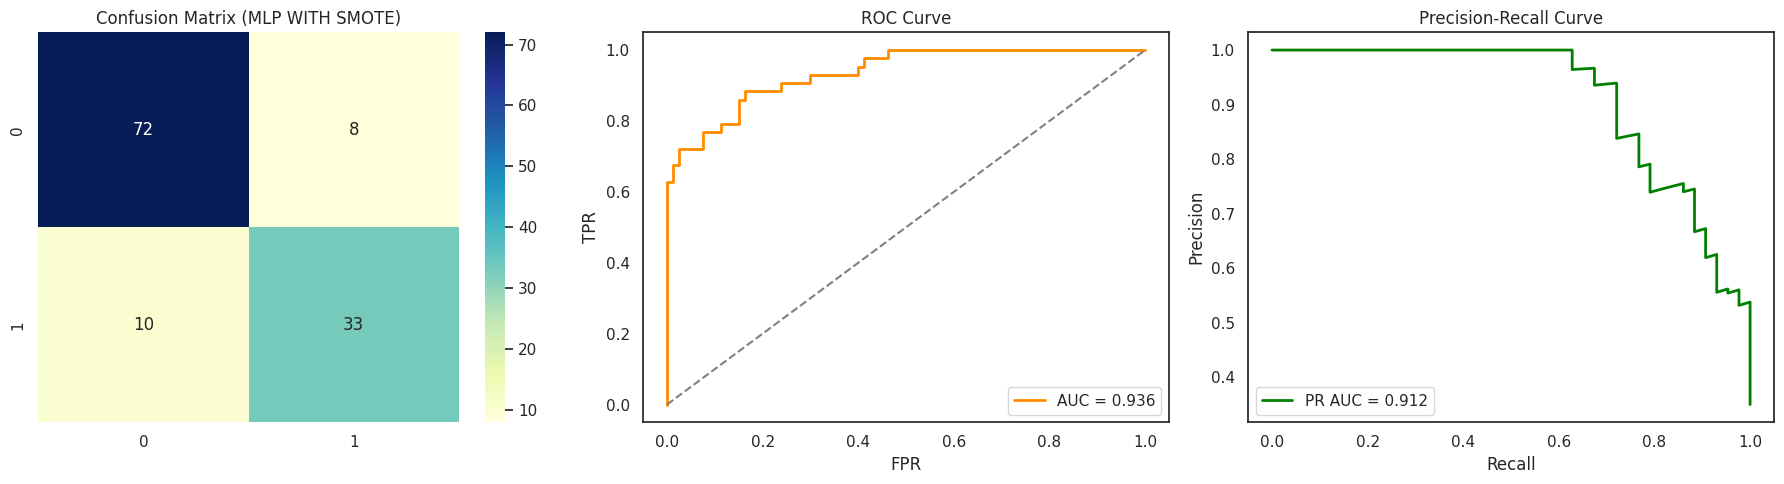


===== MLP Evaluation (WITH SMOTE) =====
AUC (ROC) : 0.9358
PR-AUC    : 0.9117


===== Repeated Stratified K-Fold CV (MLP with SMOTE) =====

===== Repeated CV Results (n_splits=5, n_repeats=10, total runs=50) =====
Accuracy: 0.8838 ± 0.0274
Precision: 0.8840 ± 0.0352
Recall: 0.8664 ± 0.0322
F1: 0.8704 ± 0.0299
ROC: 0.9516 ± 0.0236
LogLoss: 0.4052 ± 0.0504
MCC: 0.7493 ± 0.0574


,Model,Accuracy(cv),Precision(cv),Recall(cv),F1_score(cv),ROC(cv),Log_Loss(cv),mathew_corrcoef(cv),Accuracy(test),Precision(test),Recall(test),F1_score(test),ROC(test),Log_Loss(test),mathew_corrcoef(test)
0,DT (SMOTE),0.951227,0.949893,0.945561,0.946262,0.982819,0.459084,0.895230,0.926829,0.926355,0.911483,0.918176,0.917878,1.835286,0.837706
1,LR (SMOTE),0.892352,0.878519,0.898444,0.885350,0.977910,0.248953,0.776687,0.902439,0.896341,0.887355,0.891534,0.956686,0.268969,0.783645
2,MLP (SMOTE),0.874067,0.865439,0.856883,0.860104,0.944880,0.423712,0.722145,0.853659,0.841463,0.833721,0.837302,0.935756,0.347735,0.675140


In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold, RepeatedStratifiedKFold
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, log_loss, matthews_corrcoef, confusion_matrix,
                             roc_curve, auc, precision_recall_curve)
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# ====== K-Fold Cross Validation WITH SMOTE + Fold-wise Scaling ======
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_acc, fold_precision, fold_recall = [], [], []
fold_f1, fold_roc, fold_logloss, fold_mcc = [], [], [], []

# Raw (unscaled) data
X_train_arr = X_train.values if hasattr(X_train, "values") else X_train
y_train_arr = y_train.values if hasattr(y_train, "values") else y_train

print("Fold-wise Results (MLP - WITH SMOTE):\n")

for i, (train_idx, val_idx) in enumerate(kf.split(X_train_arr, y_train_arr), 1):
    X_tr, X_val = X_train_arr[train_idx], X_train_arr[val_idx]
    y_tr, y_val = y_train_arr[train_idx], y_train_arr[val_idx]

    # ---- Fold-wise MinMax Scaling (fit ONLY on training fold) ----
    scaler = MinMaxScaler()
    X_tr = scaler.fit_transform(X_tr)
    X_val = scaler.transform(X_val)

    # Apply SMOTE only to the training fold to avoid data leakage
    smote = SMOTE(random_state=42)
    X_tr_resampled, y_tr_resampled = smote.fit_resample(X_tr, y_tr)

    # Model with same hyperparameters
    model = MLPClassifier(
        hidden_layer_sizes=(50,),
        max_iter=300,
        alpha=0.1,
        solver='adam',
        early_stopping=True,
        validation_fraction=0.1,
        random_state=42
    )
    model.fit(X_tr_resampled, y_tr_resampled)

    # Predict on the original validation set
    y_val_pred = model.predict(X_val)
    y_val_prob = model.predict_proba(X_val)[:,1]

    # Metrics
    acc = accuracy_score(y_val, y_val_pred)
    precision = precision_score(y_val, y_val_pred, average='macro')
    recall = recall_score(y_val, y_val_pred, average='macro')
    f1 = f1_score(y_val, y_val_pred, average='macro')
    roc = roc_auc_score(y_val, y_val_prob)
    logloss_val = log_loss(y_val, y_val_prob)
    mcc_val = matthews_corrcoef(y_val, y_val_pred)
    CM_val = confusion_matrix(y_val, y_val_pred)

    fold_acc.append(acc)
    fold_precision.append(precision)
    fold_recall.append(recall)
    fold_f1.append(f1)
    fold_roc.append(roc)
    fold_logloss.append(logloss_val)
    fold_mcc.append(mcc_val)

    print(f"Fold {i} → Acc:{acc:.3f} | Prec:{precision:.3f} | Recall:{recall:.3f} | "
          f"F1:{f1:.3f} | ROC:{roc:.3f} | LogLoss:{logloss_val:.3f} | MCC:{mcc_val:.3f}")
    print(f"Confusion Matrix (Fold {i}):\n{CM_val}\n")

# ===== Fold-wise averages =====
print("\n===== CV Fold Average Metrics (MLP WITH SMOTE) =====")
print(f"Accuracy: {np.mean(fold_acc):.4f} ± {np.std(fold_acc):.4f}")
print(f"Precision: {np.mean(fold_precision):.4f} ± {np.std(fold_precision):.4f}")
print(f"Recall: {np.mean(fold_recall):.4f} ± {np.std(fold_recall):.4f}")
print(f"F1: {np.mean(fold_f1):.4f} ± {np.std(fold_f1):.4f}")
print(f"ROC: {np.mean(fold_roc):.4f} ± {np.std(fold_roc):.4f}")
print(f"LogLoss: {np.mean(fold_logloss):.4f} ± {np.std(fold_logloss):.4f}")
print(f"MCC: {np.mean(fold_mcc):.4f} ± {np.std(fold_mcc):.4f}")

# ===== Train final model (WITH SMOTE) =====
# Final scaler: পুরো training set দিয়ে fit, test set এ শুধু transform
final_scaler = MinMaxScaler()
X_train_scaled_final = final_scaler.fit_transform(X_train_arr)

X_test_arr = X_test.values if hasattr(X_test, "values") else X_test
X_test_scaled_final = final_scaler.transform(X_test_arr)

smote_final = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote_final.fit_resample(X_train_scaled_final, y_train_arr)

final_model = MLPClassifier(
    hidden_layer_sizes=(50,),
    max_iter=300,
    alpha=0.1,
    solver='adam',
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42
)
final_model.fit(X_train_resampled, y_train_resampled)

# ===== CV metrics (renamed train -> cv) =====
acc_cv       = np.mean(fold_acc)
precision_cv = np.mean(fold_precision)
recall_cv    = np.mean(fold_recall)
f1_cv        = np.mean(fold_f1)
roc_cv       = np.mean(fold_roc)
logloss_cv   = np.mean(fold_logloss)
mcc_cv       = np.mean(fold_mcc)

# ===== Test metrics =====
y_test_arr = y_test.values if hasattr(y_test, "values") else y_test

y_test_pred = final_model.predict(X_test_scaled_final)
y_test_prob = final_model.predict_proba(X_test_scaled_final)[:,1]

acc_test = accuracy_score(y_test_arr, y_test_pred)
precision_test = precision_score(y_test_arr, y_test_pred, average='macro')
recall_test = recall_score(y_test_arr, y_test_pred, average='macro')
f1_test = f1_score(y_test_arr, y_test_pred, average='macro')
roc_test = roc_auc_score(y_test_arr, y_test_prob)
logloss_test = log_loss(y_test_arr, y_test_prob)
mcc_test = matthews_corrcoef(y_test_arr, y_test_pred)

# ===== Curves =====
CM = confusion_matrix(y_test_arr, y_test_pred)
fpr, tpr, _ = roc_curve(y_test_arr, y_test_prob)
roc_auc = auc(fpr, tpr)
precision_vals, recall_vals, _ = precision_recall_curve(y_test_arr, y_test_prob)
pr_auc = auc(recall_vals, precision_vals)

plt.figure(figsize=(18,5))

plt.subplot(1,3,1)
sns.heatmap(CM, annot=True, fmt='d', cmap='YlGnBu')
plt.title("Confusion Matrix (MLP WITH SMOTE)")

plt.subplot(1,3,2)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}", color='darkorange', lw=2)
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.legend(loc="lower right")

plt.subplot(1,3,3)
plt.plot(recall_vals, precision_vals, label=f"PR AUC = {pr_auc:.3f}", color='green', lw=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend(loc="lower left")

plt.tight_layout()
plt.show()

print("\n===== MLP Evaluation (WITH SMOTE) =====")
print(f"AUC (ROC) : {roc_auc:.4f}")
print(f"PR-AUC    : {pr_auc:.4f}")


# ============================================================
# Repeated Stratified K-Fold Cross-Validation (Fold-wise Scaling)
# ============================================================

N_SPLITS = 5
N_REPEATS = 10

rskf = RepeatedStratifiedKFold(
    n_splits=N_SPLITS,
    n_repeats=N_REPEATS,
    random_state=42
)

rep_acc, rep_precision, rep_recall = [], [], []
rep_f1, rep_roc, rep_logloss, rep_mcc = [], [], [], []

print("\n\n===== Repeated Stratified K-Fold CV "
      "(MLP with SMOTE) =====\n")

for i, (train_idx, val_idx) in enumerate(
    rskf.split(X_train_arr, y_train_arr), 1
):

    X_tr, X_val = X_train_arr[train_idx], X_train_arr[val_idx]
    y_tr, y_val = y_train_arr[train_idx], y_train_arr[val_idx]

    # ---- Fold-wise MinMax Scaling (fit ONLY on training fold) ----
    scaler_rep = MinMaxScaler()
    X_tr = scaler_rep.fit_transform(X_tr)
    X_val = scaler_rep.transform(X_val)

    # Apply SMOTE only to the training fold to avoid data leakage
    smote_rep = SMOTE(random_state=42)

    X_tr_resampled, y_tr_resampled = smote_rep.fit_resample(
        X_tr,
        y_tr
    )

    model_rep = MLPClassifier(
        hidden_layer_sizes=(50,),
        max_iter=300,
        alpha=0.1,
        solver='adam',
        early_stopping=True,
        validation_fraction=0.1,
        random_state=42
    )

    model_rep.fit(
        X_tr_resampled,
        y_tr_resampled
    )

    y_val_pred = model_rep.predict(X_val)
    y_val_prob = model_rep.predict_proba(X_val)[:,1]

    rep_acc.append(accuracy_score(y_val, y_val_pred))
    rep_precision.append(precision_score(y_val, y_val_pred, average='macro'))
    rep_recall.append(recall_score(y_val, y_val_pred, average='macro'))
    rep_f1.append(f1_score(y_val, y_val_pred, average='macro'))
    rep_roc.append(roc_auc_score(y_val, y_val_prob))
    rep_logloss.append(log_loss(y_val, y_val_prob))
    rep_mcc.append(matthews_corrcoef(y_val, y_val_pred))


# ============================================================
# Repeated CV Mean and Standard Deviation
# ============================================================

print(
    f"===== Repeated CV Results "
    f"(n_splits={N_SPLITS}, "
    f"n_repeats={N_REPEATS}, "
    f"total runs={N_SPLITS * N_REPEATS}) ====="
)

print(f"Accuracy: {np.mean(rep_acc):.4f} ± {np.std(rep_acc):.4f}")
print(f"Precision: {np.mean(rep_precision):.4f} ± {np.std(rep_precision):.4f}")
print(f"Recall: {np.mean(rep_recall):.4f} ± {np.std(rep_recall):.4f}")
print(f"F1: {np.mean(rep_f1):.4f} ± {np.std(rep_f1):.4f}")
print(f"ROC: {np.mean(rep_roc):.4f} ± {np.std(rep_roc):.4f}")
print(f"LogLoss: {np.mean(rep_logloss):.4f} ± {np.std(rep_logloss):.4f}")
print(f"MCC: {np.mean(rep_mcc):.4f} ± {np.std(rep_mcc):.4f}")


# ============================================================
# Store Repeated CV Results for Reporting
# These values are not added to comp_ev.
# ============================================================

acc_repcv = np.mean(rep_acc)
acc_repcv_std = np.std(rep_acc)

f1_repcv = np.mean(rep_f1)
f1_repcv_std = np.std(rep_f1)

mcc_repcv = np.mean(rep_mcc)
mcc_repcv_std = np.std(rep_mcc)


# ============================================================
# Append metrics to comparison DataFrame
# Only the original CV/test metrics are added.
# ============================================================

r = comp_ev.shape[0]
comp_ev.loc[r] = ['MLP (SMOTE)', acc_cv, precision_cv, recall_cv, f1_cv, roc_cv,
                  logloss_cv, mcc_cv, acc_test, precision_test, recall_test, f1_test, roc_test,
                  logloss_test, mcc_test]

comp_ev = comp_ev.sort_values(by='Accuracy(test)', ascending=False).reset_index(drop=True)
comp_ev

# **RF**

Fold-wise Results (Random Forest - WITH SMOTE):

Fold 1 → Acc:0.970 | Prec:0.978 | Recall:0.957 | F1:0.966 | ROC:0.995 | LogLoss:0.111 | MCC:0.935
Confusion Matrix (Fold 1):
[[64  0]
 [ 3 32]]

Fold 2 → Acc:0.949 | Prec:0.948 | Recall:0.942 | F1:0.944 | ROC:0.993 | LogLoss:0.111 | MCC:0.889
Confusion Matrix (Fold 2):
[[62  2]
 [ 3 32]]

Fold 3 → Acc:0.969 | Prec:0.964 | Recall:0.970 | F1:0.967 | ROC:0.998 | LogLoss:0.100 | MCC:0.934
Confusion Matrix (Fold 3):
[[61  2]
 [ 1 34]]

Fold 4 → Acc:0.969 | Prec:0.959 | Recall:0.977 | F1:0.967 | ROC:0.999 | LogLoss:0.088 | MCC:0.936
Confusion Matrix (Fold 4):
[[61  3]
 [ 0 34]]

Fold 5 → Acc:0.990 | Prec:0.986 | Recall:0.992 | F1:0.989 | ROC:1.000 | LogLoss:0.068 | MCC:0.978
Confusion Matrix (Fold 5):
[[63  1]
 [ 0 34]]


===== CV Fold Average Metrics (RF WITH SMOTE) =====
Accuracy: 0.9696 ± 0.0127
Precision: 0.9669 ± 0.0135
Recall: 0.9675 ± 0.0172
F1: 0.9666 ± 0.0141
ROC: 0.9969 ± 0.0026
LogLoss: 0.0958 ± 0.0161
MCC: 0.9343 ± 0.0281


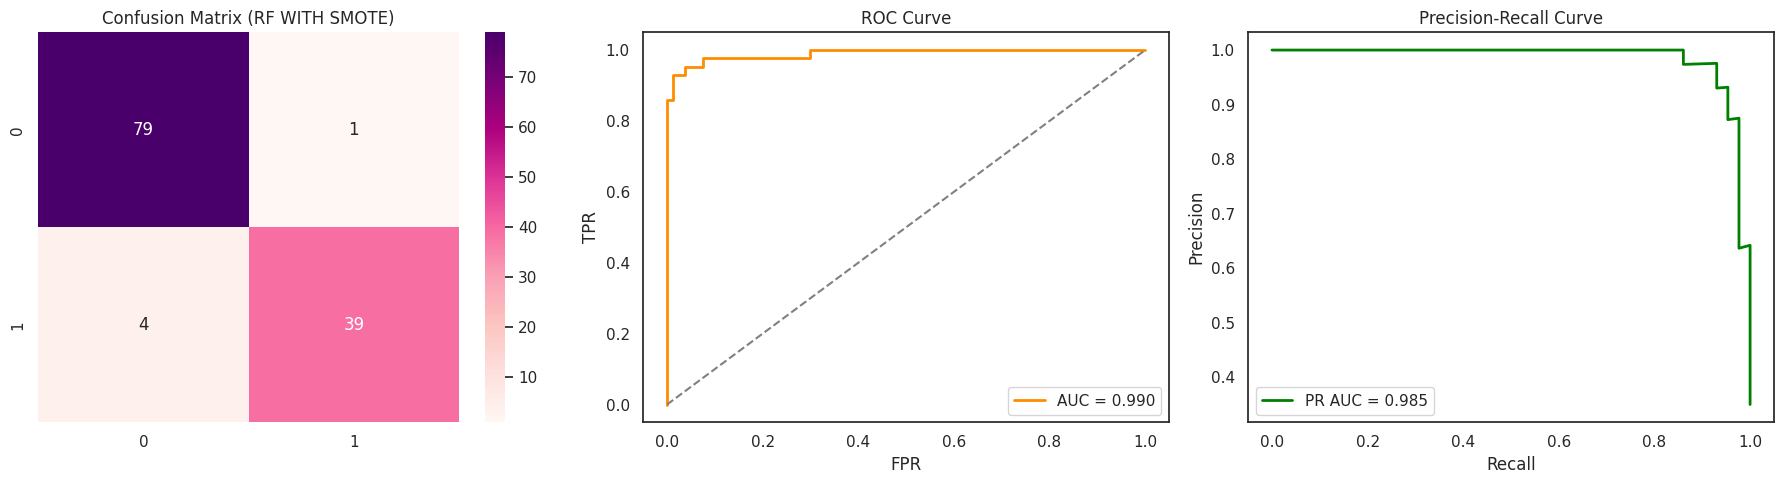


===== Random Forest Evaluation (WITH SMOTE) =====
AUC (ROC) : 0.9895
PR-AUC    : 0.9853


===== Repeated Stratified K-Fold CV (Random Forest) =====

===== Repeated CV Results (n_splits=5, n_repeats=10, total runs=50) =====
Accuracy: 0.9744 ± 0.0126
Precision: 0.9728 ± 0.0140
Recall: 0.9718 ± 0.0155
F1: 0.9719 ± 0.0139
ROC: 0.9971 ± 0.0027
LogLoss: 0.0924 ± 0.0179
MCC: 0.9445 ± 0.0274


,Model,Accuracy(cv),Precision(cv),Recall(cv),F1_score(cv),ROC(cv),Log_Loss(cv),mathew_corrcoef(cv),Accuracy(test),Precision(test),Recall(test),F1_score(test),ROC(test),Log_Loss(test),mathew_corrcoef(test)
0,RF (SMOTE),0.969553,0.966891,0.967450,0.966623,0.996861,0.095754,0.934253,0.959350,0.963404,0.947238,0.954542,0.989535,0.136854,0.910498
1,DT (SMOTE),0.951227,0.949893,0.945561,0.946262,0.982819,0.459084,0.895230,0.926829,0.926355,0.911483,0.918176,0.917878,1.835286,0.837706
2,LR (SMOTE),0.892352,0.878519,0.898444,0.885350,0.977910,0.248953,0.776687,0.902439,0.896341,0.887355,0.891534,0.956686,0.268969,0.783645
3,MLP (SMOTE),0.874067,0.865439,0.856883,0.860104,0.944880,0.423712,0.722145,0.853659,0.841463,0.833721,0.837302,0.935756,0.347735,0.675140


In [ ]:
from imblearn.over_sampling import SMOTE                      # <-- Import SMOTE
from sklearn.model_selection import StratifiedKFold, RepeatedStratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, log_loss, matthews_corrcoef, confusion_matrix,
                             roc_curve, auc, precision_recall_curve)
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# ====== K-Fold Cross Validation WITH SMOTE + Fold-wise Scaling ======
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_acc, fold_precision, fold_recall = [], [], []
fold_f1, fold_roc, fold_logloss, fold_mcc = [], [], [], []

# Raw (unscaled) data
X_train_arr = X_train.values if hasattr(X_train, "values") else X_train
y_train_arr = y_train.values if hasattr(y_train, "values") else y_train

print("Fold-wise Results (Random Forest - WITH SMOTE):\n")

for i, (train_idx, val_idx) in enumerate(kf.split(X_train_arr, y_train_arr), 1):
    X_tr, X_val = X_train_arr[train_idx], X_train_arr[val_idx]
    y_tr, y_val = y_train_arr[train_idx], y_train_arr[val_idx]

    # ---- Fold-wise MinMax Scaling (fit ONLY on training fold) ----
    scaler = MinMaxScaler()
    X_tr = scaler.fit_transform(X_tr)
    X_val = scaler.transform(X_val)

    # Apply SMOTE only to the training fold (no data leakage)
    smote = SMOTE(random_state=42)
    X_tr_resampled, y_tr_resampled = smote.fit_resample(X_tr, y_tr)

    # Model: same hyperparameters as without SMOTE
    model = RandomForestClassifier(
        n_estimators=100,
        max_depth=6,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_tr_resampled, y_tr_resampled)                 # Train on resampled fold

    # Predict on the original validation set
    y_val_pred = model.predict(X_val)
    y_val_prob = model.predict_proba(X_val)[:,1]

    # Metrics
    acc = accuracy_score(y_val, y_val_pred)
    precision = precision_score(y_val, y_val_pred, average='macro')
    recall = recall_score(y_val, y_val_pred, average='macro')
    f1 = f1_score(y_val, y_val_pred, average='macro')
    roc = roc_auc_score(y_val, y_val_prob)
    logloss_val = log_loss(y_val, y_val_prob)
    mcc_val = matthews_corrcoef(y_val, y_val_pred)
    CM_val = confusion_matrix(y_val, y_val_pred)

    fold_acc.append(acc)
    fold_precision.append(precision)
    fold_recall.append(recall)
    fold_f1.append(f1)
    fold_roc.append(roc)
    fold_logloss.append(logloss_val)
    fold_mcc.append(mcc_val)

    print(f"Fold {i} → Acc:{acc:.3f} | Prec:{precision:.3f} | Recall:{recall:.3f} | "
          f"F1:{f1:.3f} | ROC:{roc:.3f} | LogLoss:{logloss_val:.3f} | MCC:{mcc_val:.3f}")
    print(f"Confusion Matrix (Fold {i}):\n{CM_val}\n")

# ===== Fold-wise averages =====
print("\n===== CV Fold Average Metrics (RF WITH SMOTE) =====")
print(f"Accuracy: {np.mean(fold_acc):.4f} ± {np.std(fold_acc):.4f}")
print(f"Precision: {np.mean(fold_precision):.4f} ± {np.std(fold_precision):.4f}")
print(f"Recall: {np.mean(fold_recall):.4f} ± {np.std(fold_recall):.4f}")
print(f"F1: {np.mean(fold_f1):.4f} ± {np.std(fold_f1):.4f}")
print(f"ROC: {np.mean(fold_roc):.4f} ± {np.std(fold_roc):.4f}")
print(f"LogLoss: {np.mean(fold_logloss):.4f} ± {np.std(fold_logloss):.4f}")
print(f"MCC: {np.mean(fold_mcc):.4f} ± {np.std(fold_mcc):.4f}")

# ===== Train final model (WITH SMOTE) =====
# Final scaler: পুরো training set দিয়ে fit, test set এ শুধু transform
final_scaler = MinMaxScaler()
X_train_scaled_final = final_scaler.fit_transform(X_train_arr)

X_test_arr = X_test.values if hasattr(X_test, "values") else X_test
X_test_scaled_final = final_scaler.transform(X_test_arr)

smote_final = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote_final.fit_resample(X_train_scaled_final, y_train_arr)

final_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=6,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)
final_model.fit(X_train_resampled, y_train_resampled)

# ===== CV metrics (renamed train -> cv) =====
acc_cv       = np.mean(fold_acc)
precision_cv = np.mean(fold_precision)
recall_cv    = np.mean(fold_recall)
f1_cv        = np.mean(fold_f1)
roc_cv       = np.mean(fold_roc)
logloss_cv   = np.mean(fold_logloss)
mcc_cv       = np.mean(fold_mcc)

# ===== Test metrics =====
y_test_arr = y_test.values if hasattr(y_test, "values") else y_test

y_test_pred = final_model.predict(X_test_scaled_final)
y_test_prob = final_model.predict_proba(X_test_scaled_final)[:,1]

acc_test = accuracy_score(y_test_arr, y_test_pred)
precision_test = precision_score(y_test_arr, y_test_pred, average='macro')
recall_test = recall_score(y_test_arr, y_test_pred, average='macro')
f1_test = f1_score(y_test_arr, y_test_pred, average='macro')
roc_test = roc_auc_score(y_test_arr, y_test_prob)
logloss_test = log_loss(y_test_arr, y_test_prob)
mcc_test = matthews_corrcoef(y_test_arr, y_test_pred)

# ===== Curves =====
CM = confusion_matrix(y_test_arr, y_test_pred)
fpr, tpr, _ = roc_curve(y_test_arr, y_test_prob)
roc_auc = auc(fpr, tpr)
precision_vals, recall_vals, _ = precision_recall_curve(y_test_arr, y_test_prob)
pr_auc = auc(recall_vals, precision_vals)

plt.figure(figsize=(18,5))

plt.subplot(1,3,1)
sns.heatmap(CM, annot=True, fmt='d', cmap='RdPu')
plt.title("Confusion Matrix (RF WITH SMOTE)")

plt.subplot(1,3,2)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}", color='darkorange', lw=2)
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.legend(loc="lower right")

plt.subplot(1,3,3)
plt.plot(recall_vals, precision_vals, label=f"PR AUC = {pr_auc:.3f}", color='green', lw=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend(loc="lower left")

plt.tight_layout()
plt.show()

print("\n===== Random Forest Evaluation (WITH SMOTE) =====")
print(f"AUC (ROC) : {roc_auc:.4f}")
print(f"PR-AUC    : {pr_auc:.4f}")


# ============================================================
# PART 2: Repeated Stratified K-Fold CV (Fold-wise Scaling)
# ============================================================

N_SPLITS = 5
N_REPEATS = 10   # Total runs = 5 x 10 = 50

rskf = RepeatedStratifiedKFold(
    n_splits=N_SPLITS,
    n_repeats=N_REPEATS,
    random_state=42
)

rep_acc, rep_precision, rep_recall = [], [], []
rep_f1, rep_roc, rep_logloss, rep_mcc = [], [], [], []

print("\n\n===== Repeated Stratified K-Fold CV (Random Forest) =====\n")

for i, (train_idx, val_idx) in enumerate(rskf.split(X_train_arr, y_train_arr), 1):
    X_tr, X_val = X_train_arr[train_idx], X_train_arr[val_idx]
    y_tr, y_val = y_train_arr[train_idx], y_train_arr[val_idx]

    # ---- Fold-wise MinMax Scaling (fit ONLY on training fold) ----
    scaler_rep = MinMaxScaler()
    X_tr = scaler_rep.fit_transform(X_tr)
    X_val = scaler_rep.transform(X_val)

    # Apply SMOTE only to the training fold to avoid data leakage
    smote_rep = SMOTE(random_state=42)
    X_tr_resampled, y_tr_resampled = smote_rep.fit_resample(X_tr, y_tr)

    model_rep = RandomForestClassifier(
        n_estimators=100,
        max_depth=6,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    )

    model_rep.fit(X_tr_resampled, y_tr_resampled)

    y_val_pred = model_rep.predict(X_val)
    y_val_prob = model_rep.predict_proba(X_val)[:,1]

    rep_acc.append(accuracy_score(y_val, y_val_pred))
    rep_precision.append(precision_score(y_val, y_val_pred, average='macro'))
    rep_recall.append(recall_score(y_val, y_val_pred, average='macro'))
    rep_f1.append(f1_score(y_val, y_val_pred, average='macro'))
    rep_roc.append(roc_auc_score(y_val, y_val_prob))
    rep_logloss.append(log_loss(y_val, y_val_prob))
    rep_mcc.append(matthews_corrcoef(y_val, y_val_pred))

    # Printing every run separately would produce a large output (50 runs),
    # so printing is disabled here.


# ===== Repeated CV Mean and Standard Deviation =====
print(f"===== Repeated CV Results (n_splits={N_SPLITS}, n_repeats={N_REPEATS}, total runs={N_SPLITS*N_REPEATS}) =====")
print(f"Accuracy: {np.mean(rep_acc):.4f} ± {np.std(rep_acc):.4f}")
print(f"Precision: {np.mean(rep_precision):.4f} ± {np.std(rep_precision):.4f}")
print(f"Recall: {np.mean(rep_recall):.4f} ± {np.std(rep_recall):.4f}")
print(f"F1: {np.mean(rep_f1):.4f} ± {np.std(rep_f1):.4f}")
print(f"ROC: {np.mean(rep_roc):.4f} ± {np.std(rep_roc):.4f}")
print(f"LogLoss: {np.mean(rep_logloss):.4f} ± {np.std(rep_logloss):.4f}")
print(f"MCC: {np.mean(rep_mcc):.4f} ± {np.std(rep_mcc):.4f}")


# ===== Store Repeated CV Results for Reporting =====
# These values are not added to comp_ev.

acc_repcv       = np.mean(rep_acc)
acc_repcv_std   = np.std(rep_acc)
f1_repcv        = np.mean(rep_f1)
f1_repcv_std    = np.std(rep_f1)
mcc_repcv       = np.mean(rep_mcc)
mcc_repcv_std   = np.std(rep_mcc)


# ===== Append metrics to comparison DataFrame =====
r = comp_ev.shape[0]
comp_ev.loc[r] = ['RF (SMOTE)', acc_cv, precision_cv, recall_cv, f1_cv, roc_cv,
                  logloss_cv, mcc_cv, acc_test, precision_test, recall_test, f1_test, roc_test,
                  logloss_test, mcc_test]

comp_ev = comp_ev.sort_values(by='Accuracy(test)', ascending=False).reset_index(drop=True)
comp_ev

# **AdaB**

Fold-wise Results (AdaBoost - WITH SMOTE):

Fold 1 → Acc:0.899 | Prec:0.887 | Recall:0.896 | F1:0.891 | ROC:0.958 | LogLoss:0.308 | MCC:0.783
Confusion Matrix (Fold 1):
[[58  6]
 [ 4 31]]

Fold 2 → Acc:0.929 | Prec:0.921 | Recall:0.926 | F1:0.923 | ROC:0.989 | LogLoss:0.294 | MCC:0.847
Confusion Matrix (Fold 2):
[[60  4]
 [ 3 32]]

Fold 3 → Acc:0.949 | Prec:0.938 | Recall:0.960 | F1:0.946 | ROC:0.987 | LogLoss:0.300 | MCC:0.898
Confusion Matrix (Fold 3):
[[58  5]
 [ 0 35]]

Fold 4 → Acc:0.918 | Prec:0.905 | Recall:0.938 | F1:0.914 | ROC:0.990 | LogLoss:0.304 | MCC:0.842
Confusion Matrix (Fold 4):
[[56  8]
 [ 0 34]]

Fold 5 → Acc:0.939 | Prec:0.926 | Recall:0.946 | F1:0.934 | ROC:0.991 | LogLoss:0.272 | MCC:0.872
Confusion Matrix (Fold 5):
[[59  5]
 [ 1 33]]


===== CV Fold Average Metrics (AdaBoost WITH SMOTE) =====
Accuracy: 0.9269 ± 0.0172
Precision: 0.9151 ± 0.0177
Recall: 0.9332 ± 0.0217
F1: 0.9216 ± 0.0187
ROC: 0.9831 ± 0.0128
LogLoss: 0.2954 ± 0.0125
MCC: 0.8480 ± 0.0383


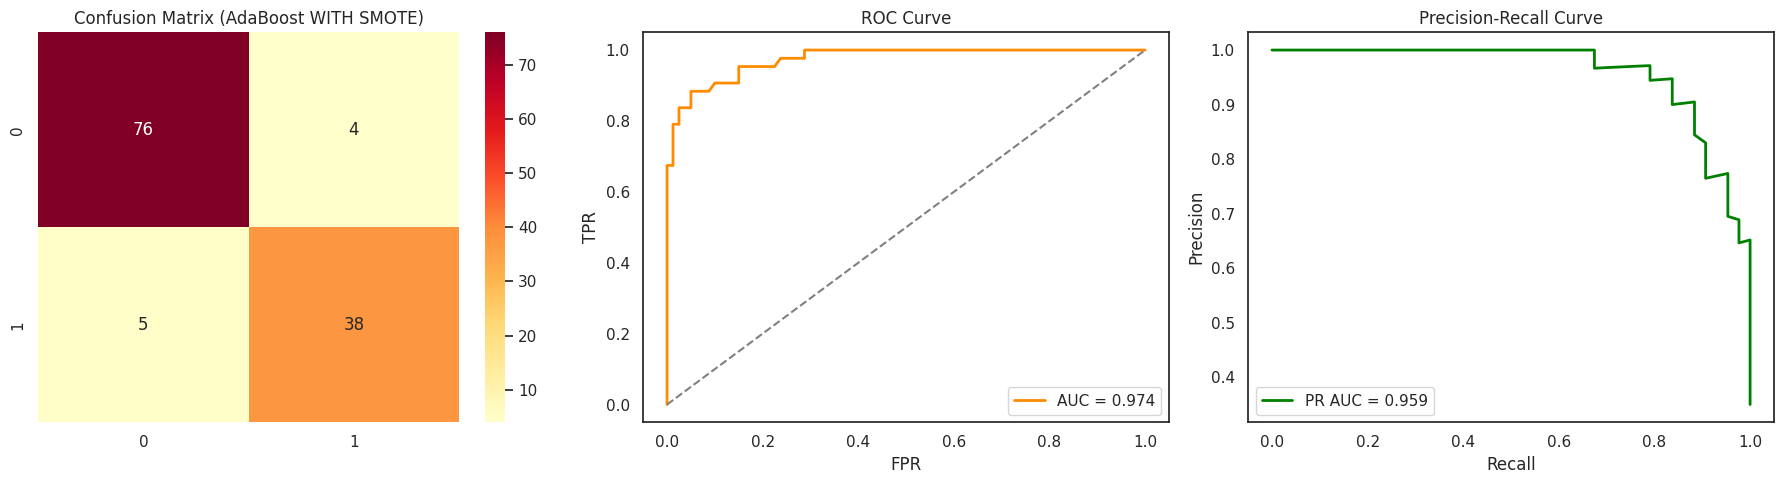


===== AdaBoost Evaluation (WITH SMOTE) =====
AUC (ROC) : 0.9738
PR-AUC    : 0.9595


===== Repeated Stratified K-Fold CV (AdaBoost) =====

===== Repeated CV Results (n_splits=5, n_repeats=10, total runs=50) =====
Accuracy: 0.9350 ± 0.0252
Precision: 0.9249 ± 0.0274
Recall: 0.9404 ± 0.0242
F1: 0.9304 ± 0.0265
ROC: 0.9856 ± 0.0088
LogLoss: 0.2930 ± 0.0176
MCC: 0.8651 ± 0.0505


,Model,Accuracy(cv),Precision(cv),Recall(cv),F1_score(cv),ROC(cv),Log_Loss(cv),mathew_corrcoef(cv),Accuracy(test),Precision(test),Recall(test),F1_score(test),ROC(test),Log_Loss(test),mathew_corrcoef(test)
0,RF (SMOTE),0.969553,0.966891,0.967450,0.966623,0.996861,0.095754,0.934253,0.959350,0.963404,0.947238,0.954542,0.989535,0.136854,0.910498
1,DT (SMOTE),0.951227,0.949893,0.945561,0.946262,0.982819,0.459084,0.895230,0.926829,0.926355,0.911483,0.918176,0.917878,1.835286,0.837706
2,AdaBoost (SMOTE),0.926881,0.915087,0.933185,0.921640,0.983113,0.295446,0.848025,0.926829,0.921517,0.916860,0.919109,0.973837,0.307622,0.838364
3,LR (SMOTE),0.892352,0.878519,0.898444,0.885350,0.977910,0.248953,0.776687,0.902439,0.896341,0.887355,0.891534,0.956686,0.268969,0.783645
4,MLP (SMOTE),0.874067,0.865439,0.856883,0.860104,0.944880,0.423712,0.722145,0.853659,0.841463,0.833721,0.837302,0.935756,0.347735,0.675140


In [ ]:
from imblearn.over_sampling import SMOTE                      # <-- Import SMOTE
from sklearn.model_selection import StratifiedKFold, RepeatedStratifiedKFold
from sklearn.ensemble import AdaBoostClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, log_loss, matthews_corrcoef, confusion_matrix,
                             roc_curve, auc, precision_recall_curve)
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# ====== K-Fold Cross Validation WITH SMOTE + Fold-wise Scaling ======
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_acc, fold_precision, fold_recall = [], [], []
fold_f1, fold_roc, fold_logloss, fold_mcc = [], [], [], []

# Raw (unscaled) data
X_train_arr = X_train.values if hasattr(X_train, "values") else X_train
y_train_arr = y_train.values if hasattr(y_train, "values") else y_train

print("Fold-wise Results (AdaBoost - WITH SMOTE):\n")

for i, (train_idx, val_idx) in enumerate(kf.split(X_train_arr, y_train_arr), 1):
    X_tr, X_val = X_train_arr[train_idx], X_train_arr[val_idx]
    y_tr, y_val = y_train_arr[train_idx], y_train_arr[val_idx]

    # ---- Fold-wise MinMax Scaling (fit ONLY on training fold) ----
    scaler = MinMaxScaler()
    X_tr = scaler.fit_transform(X_tr)
    X_val = scaler.transform(X_val)

    # Apply SMOTE only to the training fold (no data leakage)
    smote = SMOTE(random_state=42)
    X_tr_resampled, y_tr_resampled = smote.fit_resample(X_tr, y_tr)

    # Model: same hyperparameters as without SMOTE
    model = AdaBoostClassifier(
        n_estimators=50,
        learning_rate=0.1,
        random_state=42
    )
    model.fit(X_tr_resampled, y_tr_resampled)                 # Train on resampled fold

    # Predict on the original validation set
    y_val_pred = model.predict(X_val)
    y_val_prob = model.predict_proba(X_val)[:,1]

    # Metrics
    acc = accuracy_score(y_val, y_val_pred)
    precision = precision_score(y_val, y_val_pred, average='macro')
    recall = recall_score(y_val, y_val_pred, average='macro')
    f1 = f1_score(y_val, y_val_pred, average='macro')
    roc = roc_auc_score(y_val, y_val_prob)
    logloss_val = log_loss(y_val, y_val_prob)
    mcc_val = matthews_corrcoef(y_val, y_val_pred)
    CM_val = confusion_matrix(y_val, y_val_pred)

    fold_acc.append(acc)
    fold_precision.append(precision)
    fold_recall.append(recall)
    fold_f1.append(f1)
    fold_roc.append(roc)
    fold_logloss.append(logloss_val)
    fold_mcc.append(mcc_val)

    print(f"Fold {i} → Acc:{acc:.3f} | Prec:{precision:.3f} | Recall:{recall:.3f} | "
          f"F1:{f1:.3f} | ROC:{roc:.3f} | LogLoss:{logloss_val:.3f} | MCC:{mcc_val:.3f}")
    print(f"Confusion Matrix (Fold {i}):\n{CM_val}\n")

# ===== Fold-wise averages =====
print("\n===== CV Fold Average Metrics (AdaBoost WITH SMOTE) =====")
print(f"Accuracy: {np.mean(fold_acc):.4f} ± {np.std(fold_acc):.4f}")
print(f"Precision: {np.mean(fold_precision):.4f} ± {np.std(fold_precision):.4f}")
print(f"Recall: {np.mean(fold_recall):.4f} ± {np.std(fold_recall):.4f}")
print(f"F1: {np.mean(fold_f1):.4f} ± {np.std(fold_f1):.4f}")
print(f"ROC: {np.mean(fold_roc):.4f} ± {np.std(fold_roc):.4f}")
print(f"LogLoss: {np.mean(fold_logloss):.4f} ± {np.std(fold_logloss):.4f}")
print(f"MCC: {np.mean(fold_mcc):.4f} ± {np.std(fold_mcc):.4f}")

# ===== Train final model (WITH SMOTE) =====
# Final scaler: পুরো training set দিয়ে fit, test set এ শুধু transform
final_scaler = MinMaxScaler()
X_train_scaled_final = final_scaler.fit_transform(X_train_arr)

X_test_arr = X_test.values if hasattr(X_test, "values") else X_test
X_test_scaled_final = final_scaler.transform(X_test_arr)

smote_final = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote_final.fit_resample(X_train_scaled_final, y_train_arr)

final_model = AdaBoostClassifier(
    n_estimators=50,
    learning_rate=0.1,
    random_state=42
)
final_model.fit(X_train_resampled, y_train_resampled)

# ===== CV metrics (renamed train -> cv) =====
acc_cv       = np.mean(fold_acc)
precision_cv = np.mean(fold_precision)
recall_cv    = np.mean(fold_recall)
f1_cv        = np.mean(fold_f1)
roc_cv       = np.mean(fold_roc)
logloss_cv   = np.mean(fold_logloss)
mcc_cv       = np.mean(fold_mcc)

# ===== Test metrics =====
y_test_arr = y_test.values if hasattr(y_test, "values") else y_test

y_test_pred = final_model.predict(X_test_scaled_final)
y_test_prob = final_model.predict_proba(X_test_scaled_final)[:,1]

acc_test = accuracy_score(y_test_arr, y_test_pred)
precision_test = precision_score(y_test_arr, y_test_pred, average='macro')
recall_test = recall_score(y_test_arr, y_test_pred, average='macro')
f1_test = f1_score(y_test_arr, y_test_pred, average='macro')
roc_test = roc_auc_score(y_test_arr, y_test_prob)
logloss_test = log_loss(y_test_arr, y_test_prob)
mcc_test = matthews_corrcoef(y_test_arr, y_test_pred)

# ===== Curves =====
CM = confusion_matrix(y_test_arr, y_test_pred)
fpr, tpr, _ = roc_curve(y_test_arr, y_test_prob)
roc_auc = auc(fpr, tpr)
precision_vals, recall_vals, _ = precision_recall_curve(y_test_arr, y_test_prob)
pr_auc = auc(recall_vals, precision_vals)

plt.figure(figsize=(18,5))

plt.subplot(1,3,1)
sns.heatmap(CM, annot=True, fmt='d', cmap='YlOrRd')
plt.title("Confusion Matrix (AdaBoost WITH SMOTE)")

plt.subplot(1,3,2)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}", color='darkorange', lw=2)
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.legend(loc="lower right")

plt.subplot(1,3,3)
plt.plot(recall_vals, precision_vals, label=f"PR AUC = {pr_auc:.3f}", color='green', lw=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend(loc="lower left")

plt.tight_layout()
plt.show()

print("\n===== AdaBoost Evaluation (WITH SMOTE) =====")
print(f"AUC (ROC) : {roc_auc:.4f}")
print(f"PR-AUC    : {pr_auc:.4f}")


# ============================================================
# PART 2: Repeated Stratified K-Fold CV (Fold-wise Scaling)
# ============================================================

N_SPLITS = 5
N_REPEATS = 10   # Total runs = 5 x 10 = 50

rskf = RepeatedStratifiedKFold(
    n_splits=N_SPLITS,
    n_repeats=N_REPEATS,
    random_state=42
)

rep_acc, rep_precision, rep_recall = [], [], []
rep_f1, rep_roc, rep_logloss, rep_mcc = [], [], [], []

print("\n\n===== Repeated Stratified K-Fold CV (AdaBoost) =====\n")

for i, (train_idx, val_idx) in enumerate(
    rskf.split(X_train_arr, y_train_arr), 1
):
    X_tr, X_val = X_train_arr[train_idx], X_train_arr[val_idx]
    y_tr, y_val = y_train_arr[train_idx], y_train_arr[val_idx]

    # ---- Fold-wise MinMax Scaling (fit ONLY on training fold) ----
    scaler_rep = MinMaxScaler()
    X_tr = scaler_rep.fit_transform(X_tr)
    X_val = scaler_rep.transform(X_val)

    # Apply SMOTE only to the training fold to avoid data leakage
    smote_rep = SMOTE(random_state=42)
    X_tr_resampled, y_tr_resampled = smote_rep.fit_resample(X_tr, y_tr)

    model_rep = AdaBoostClassifier(
        n_estimators=50,
        learning_rate=0.1,
        random_state=42
    )

    model_rep.fit(X_tr_resampled, y_tr_resampled)

    y_val_pred = model_rep.predict(X_val)
    y_val_prob = model_rep.predict_proba(X_val)[:,1]

    rep_acc.append(accuracy_score(y_val, y_val_pred))
    rep_precision.append(precision_score(y_val, y_val_pred, average='macro'))
    rep_recall.append(recall_score(y_val, y_val_pred, average='macro'))
    rep_f1.append(f1_score(y_val, y_val_pred, average='macro'))
    rep_roc.append(roc_auc_score(y_val, y_val_prob))
    rep_logloss.append(log_loss(y_val, y_val_prob))
    rep_mcc.append(matthews_corrcoef(y_val, y_val_pred))

    # Printing every run separately would produce a large output (50 runs),
    # so printing is disabled here.


# ===== Repeated CV Mean and Standard Deviation =====
print(f"===== Repeated CV Results (n_splits={N_SPLITS}, n_repeats={N_REPEATS}, total runs={N_SPLITS*N_REPEATS}) =====")
print(f"Accuracy: {np.mean(rep_acc):.4f} ± {np.std(rep_acc):.4f}")
print(f"Precision: {np.mean(rep_precision):.4f} ± {np.std(rep_precision):.4f}")
print(f"Recall: {np.mean(rep_recall):.4f} ± {np.std(rep_recall):.4f}")
print(f"F1: {np.mean(rep_f1):.4f} ± {np.std(rep_f1):.4f}")
print(f"ROC: {np.mean(rep_roc):.4f} ± {np.std(rep_roc):.4f}")
print(f"LogLoss: {np.mean(rep_logloss):.4f} ± {np.std(rep_logloss):.4f}")
print(f"MCC: {np.mean(rep_mcc):.4f} ± {np.std(rep_mcc):.4f}")


# ===== Store Repeated CV Results for Reporting =====
# These values are not added to comp_ev

acc_repcv       = np.mean(rep_acc)
acc_repcv_std   = np.std(rep_acc)
f1_repcv        = np.mean(rep_f1)
f1_repcv_std    = np.std(rep_f1)
mcc_repcv       = np.mean(rep_mcc)
mcc_repcv_std   = np.std(rep_mcc)


# ===== Append metrics to comparison DataFrame =====
r = comp_ev.shape[0]
comp_ev.loc[r] = ['AdaBoost (SMOTE)', acc_cv, precision_cv, recall_cv, f1_cv, roc_cv,
                  logloss_cv, mcc_cv, acc_test, precision_test, recall_test, f1_test, roc_test,
                  logloss_test, mcc_test]

comp_ev = comp_ev.sort_values(by='Accuracy(test)', ascending=False).reset_index(drop=True)
comp_ev

# **XGB**

Fold-wise Results (XGBoost - WITH SMOTE):

Fold 1 → Acc:0.970 | Prec:0.978 | Recall:0.957 | F1:0.966 | ROC:0.989 | LogLoss:0.117 | MCC:0.935
Confusion Matrix (Fold 1):
[[64  0]
 [ 3 32]]

Fold 2 → Acc:0.960 | Prec:0.962 | Recall:0.949 | F1:0.955 | ROC:0.992 | LogLoss:0.117 | MCC:0.911
Confusion Matrix (Fold 2):
[[63  1]
 [ 3 32]]

Fold 3 → Acc:0.969 | Prec:0.964 | Recall:0.970 | F1:0.967 | ROC:0.998 | LogLoss:0.082 | MCC:0.934
Confusion Matrix (Fold 3):
[[61  2]
 [ 1 34]]

Fold 4 → Acc:0.949 | Prec:0.936 | Recall:0.961 | F1:0.945 | ROC:0.996 | LogLoss:0.125 | MCC:0.896
Confusion Matrix (Fold 4):
[[59  5]
 [ 0 34]]

Fold 5 → Acc:0.969 | Prec:0.963 | Recall:0.970 | F1:0.966 | ROC:0.999 | LogLoss:0.070 | MCC:0.933
Confusion Matrix (Fold 5):
[[62  2]
 [ 1 33]]


===== CV Fold Average Metrics (XGBoost WITH SMOTE) =====
Accuracy: 0.9634 ± 0.0082
Precision: 0.9607 ± 0.0136
Recall: 0.9614 ± 0.0078
F1: 0.9600 ± 0.0085
ROC: 0.9948 ± 0.0037
LogLoss: 0.1024 ± 0.0218
MCC: 0.9219 ± 0.0154


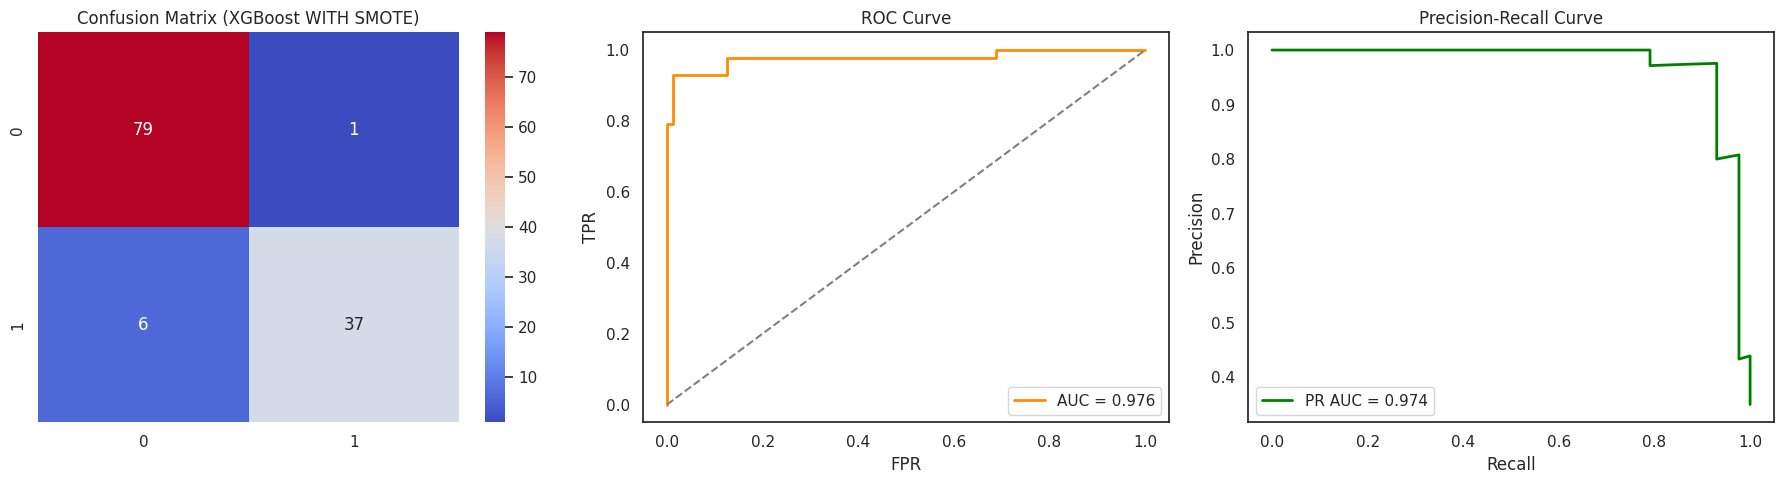


===== XGBoost Evaluation (WITH SMOTE) =====
AUC (ROC) : 0.9765
PR-AUC    : 0.9741


===== Repeated Stratified K-Fold CV (XGBoost with SMOTE) =====

===== Repeated CV Results (n_splits=5, n_repeats=10, total runs=50) =====
Accuracy: 0.9679 ± 0.0164
Precision: 0.9649 ± 0.0193
Recall: 0.9658 ± 0.0177
F1: 0.9649 ± 0.0179
ROC: 0.9951 ± 0.0045
LogLoss: 0.0969 ± 0.0301
MCC: 0.9307 ± 0.0353


,Model,Accuracy(cv),Precision(cv),Recall(cv),F1_score(cv),ROC(cv),Log_Loss(cv),mathew_corrcoef(cv),Accuracy(test),Precision(test),Recall(test),F1_score(test),ROC(test),Log_Loss(test),mathew_corrcoef(test)
0,RF (SMOTE),0.969553,0.966891,0.967450,0.966623,0.996861,0.095754,0.934253,0.959350,0.963404,0.947238,0.954542,0.989535,0.136854,0.910498
1,XGBoost (SMOTE),0.963410,0.960656,0.961384,0.960023,0.994787,0.102435,0.921900,0.943089,0.951548,0.923983,0.935578,0.976453,0.170344,0.875096
2,DT (SMOTE),0.951227,0.949893,0.945561,0.946262,0.982819,0.459084,0.895230,0.926829,0.926355,0.911483,0.918176,0.917878,1.835286,0.837706
3,AdaBoost (SMOTE),0.926881,0.915087,0.933185,0.921640,0.983113,0.295446,0.848025,0.926829,0.921517,0.916860,0.919109,0.973837,0.307622,0.838364
4,LR (SMOTE),0.892352,0.878519,0.898444,0.885350,0.977910,0.248953,0.776687,0.902439,0.896341,0.887355,0.891534,0.956686,0.268969,0.783645
5,MLP (SMOTE),0.874067,0.865439,0.856883,0.860104,0.944880,0.423712,0.722145,0.853659,0.841463,0.833721,0.837302,0.935756,0.347735,0.675140


In [ ]:
from imblearn.over_sampling import SMOTE                      # <-- Import SMOTE
from sklearn.model_selection import StratifiedKFold, RepeatedStratifiedKFold
from sklearn.preprocessing import MinMaxScaler
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, log_loss, matthews_corrcoef, confusion_matrix,
                             roc_curve, auc, precision_recall_curve)
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# PART 1: K-Fold Cross Validation WITH SMOTE + Fold-wise Scaling
# ============================================================

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_acc, fold_precision, fold_recall = [], [], []
fold_f1, fold_roc, fold_logloss, fold_mcc = [], [], [], []

# Raw (unscaled) data
X_train_arr = X_train.values if hasattr(X_train, "values") else X_train
y_train_arr = y_train.values if hasattr(y_train, "values") else y_train

print("Fold-wise Results (XGBoost - WITH SMOTE):\n")

for i, (train_idx, val_idx) in enumerate(kf.split(X_train_arr, y_train_arr), 1):
    X_tr, X_val = X_train_arr[train_idx], X_train_arr[val_idx]
    y_tr, y_val = y_train_arr[train_idx], y_train_arr[val_idx]

    # ---- Fold-wise MinMax Scaling (fit ONLY on training fold) ----
    scaler = MinMaxScaler()
    X_tr = scaler.fit_transform(X_tr)
    X_val = scaler.transform(X_val)

    # Apply SMOTE only to the training fold (no data leakage)
    smote = SMOTE(random_state=42)
    X_tr_resampled, y_tr_resampled = smote.fit_resample(X_tr, y_tr)

    # Model: same hyperparameters as without SMOTE
    model = XGBClassifier(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.05,
        gamma=1,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=2,
        random_state=42,
        eval_metric='logloss'
    )
    model.fit(X_tr_resampled, y_tr_resampled)                 # Train on resampled fold

    # Predict on the original validation set
    y_val_pred = model.predict(X_val)
    y_val_prob = model.predict_proba(X_val)[:,1]

    # Metrics
    acc = accuracy_score(y_val, y_val_pred)
    precision = precision_score(y_val, y_val_pred, average='macro')
    recall = recall_score(y_val, y_val_pred, average='macro')
    f1 = f1_score(y_val, y_val_pred, average='macro')
    roc = roc_auc_score(y_val, y_val_prob)
    logloss_val = log_loss(y_val, y_val_prob)
    mcc_val = matthews_corrcoef(y_val, y_val_pred)
    CM_val = confusion_matrix(y_val, y_val_pred)

    fold_acc.append(acc)
    fold_precision.append(precision)
    fold_recall.append(recall)
    fold_f1.append(f1)
    fold_roc.append(roc)
    fold_logloss.append(logloss_val)
    fold_mcc.append(mcc_val)

    print(f"Fold {i} → Acc:{acc:.3f} | Prec:{precision:.3f} | Recall:{recall:.3f} | "
          f"F1:{f1:.3f} | ROC:{roc:.3f} | LogLoss:{logloss_val:.3f} | MCC:{mcc_val:.3f}")
    print(f"Confusion Matrix (Fold {i}):\n{CM_val}\n")

# ===== Fold-wise averages =====
print("\n===== CV Fold Average Metrics (XGBoost WITH SMOTE) =====")
print(f"Accuracy: {np.mean(fold_acc):.4f} ± {np.std(fold_acc):.4f}")
print(f"Precision: {np.mean(fold_precision):.4f} ± {np.std(fold_precision):.4f}")
print(f"Recall: {np.mean(fold_recall):.4f} ± {np.std(fold_recall):.4f}")
print(f"F1: {np.mean(fold_f1):.4f} ± {np.std(fold_f1):.4f}")
print(f"ROC: {np.mean(fold_roc):.4f} ± {np.std(fold_roc):.4f}")
print(f"LogLoss: {np.mean(fold_logloss):.4f} ± {np.std(fold_logloss):.4f}")
print(f"MCC: {np.mean(fold_mcc):.4f} ± {np.std(fold_mcc):.4f}")

# ===== Train final model (WITH SMOTE) =====
# Final scaler: পুরো training set দিয়ে fit, test set এ শুধু transform
final_scaler = MinMaxScaler()
X_train_scaled_final = final_scaler.fit_transform(X_train_arr)

X_test_arr = X_test.values if hasattr(X_test, "values") else X_test
X_test_scaled_final = final_scaler.transform(X_test_arr)

smote_final = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote_final.fit_resample(X_train_scaled_final, y_train_arr)

final_model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    gamma=1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=2,
    random_state=42,
    eval_metric='logloss'
)
final_model.fit(X_train_resampled, y_train_resampled)

# ===== CV metrics (renamed train -> cv) =====
acc_cv       = np.mean(fold_acc)
precision_cv = np.mean(fold_precision)
recall_cv    = np.mean(fold_recall)
f1_cv        = np.mean(fold_f1)
roc_cv       = np.mean(fold_roc)
logloss_cv   = np.mean(fold_logloss)
mcc_cv       = np.mean(fold_mcc)

# ===== Test metrics =====
y_test_arr = y_test.values if hasattr(y_test, "values") else y_test

y_test_pred = final_model.predict(X_test_scaled_final)
y_test_prob = final_model.predict_proba(X_test_scaled_final)[:,1]

acc_test = accuracy_score(y_test_arr, y_test_pred)
precision_test = precision_score(y_test_arr, y_test_pred, average='macro')
recall_test = recall_score(y_test_arr, y_test_pred, average='macro')
f1_test = f1_score(y_test_arr, y_test_pred, average='macro')
roc_test = roc_auc_score(y_test_arr, y_test_prob)
logloss_test = log_loss(y_test_arr, y_test_prob)
mcc_test = matthews_corrcoef(y_test_arr, y_test_pred)

# ===== Curves =====
CM = confusion_matrix(y_test_arr, y_test_pred)
fpr, tpr, _ = roc_curve(y_test_arr, y_test_prob)
roc_auc = auc(fpr, tpr)
precision_vals, recall_vals, _ = precision_recall_curve(y_test_arr, y_test_prob)
pr_auc = auc(recall_vals, precision_vals)

plt.figure(figsize=(18,5))

plt.subplot(1,3,1)
sns.heatmap(CM, annot=True, fmt='d', cmap='coolwarm')
plt.title("Confusion Matrix (XGBoost WITH SMOTE)")

plt.subplot(1,3,2)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}", color='darkorange', lw=2)
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.legend(loc="lower right")

plt.subplot(1,3,3)
plt.plot(recall_vals, precision_vals, label=f"PR AUC = {pr_auc:.3f}", color='green', lw=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend(loc="lower left")

plt.tight_layout()
plt.show()

print("\n===== XGBoost Evaluation (WITH SMOTE) =====")
print(f"AUC (ROC) : {roc_auc:.4f}")
print(f"PR-AUC    : {pr_auc:.4f}")


# ============================================================
# PART 2: Repeated Stratified K-Fold Cross-Validation
# Purpose: Assess the stability and robustness of the model
# across multiple train-validation splits.
# ============================================================

N_SPLITS = 5
N_REPEATS = 10   # Total runs = 5 x 10 = 50

rskf = RepeatedStratifiedKFold(
    n_splits=N_SPLITS,
    n_repeats=N_REPEATS,
    random_state=42
)

rep_acc, rep_precision, rep_recall = [], [], []
rep_f1, rep_roc, rep_logloss, rep_mcc = [], [], [], []

print("\n\n===== Repeated Stratified K-Fold CV (XGBoost with SMOTE) =====\n")

for i, (train_idx, val_idx) in enumerate(
    rskf.split(X_train_arr, y_train_arr), 1
):
    X_tr, X_val = X_train_arr[train_idx], X_train_arr[val_idx]
    y_tr, y_val = y_train_arr[train_idx], y_train_arr[val_idx]

    # ---- Fold-wise MinMax Scaling (fit ONLY on training fold) ----
    scaler_rep = MinMaxScaler()
    X_tr = scaler_rep.fit_transform(X_tr)
    X_val = scaler_rep.transform(X_val)

    # Apply SMOTE only to the training fold to avoid data leakage
    smote_rep = SMOTE(random_state=42)
    X_tr_resampled, y_tr_resampled = smote_rep.fit_resample(X_tr, y_tr)

    model_rep = XGBClassifier(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.05,
        gamma=1,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=2,
        random_state=42,
        eval_metric='logloss'
    )

    model_rep.fit(X_tr_resampled, y_tr_resampled)

    y_val_pred = model_rep.predict(X_val)
    y_val_prob = model_rep.predict_proba(X_val)[:,1]

    rep_acc.append(accuracy_score(y_val, y_val_pred))
    rep_precision.append(precision_score(y_val, y_val_pred, average='macro'))
    rep_recall.append(recall_score(y_val, y_val_pred, average='macro'))
    rep_f1.append(f1_score(y_val, y_val_pred, average='macro'))
    rep_roc.append(roc_auc_score(y_val, y_val_prob))
    rep_logloss.append(log_loss(y_val, y_val_prob))
    rep_mcc.append(matthews_corrcoef(y_val, y_val_pred))

    # Printing every run separately would produce a large output (50 runs),
    # so printing is disabled here.


# ===== Repeated CV Mean and Standard Deviation =====
print(f"===== Repeated CV Results (n_splits={N_SPLITS}, n_repeats={N_REPEATS}, total runs={N_SPLITS*N_REPEATS}) =====")
print(f"Accuracy: {np.mean(rep_acc):.4f} ± {np.std(rep_acc):.4f}")
print(f"Precision: {np.mean(rep_precision):.4f} ± {np.std(rep_precision):.4f}")
print(f"Recall: {np.mean(rep_recall):.4f} ± {np.std(rep_recall):.4f}")
print(f"F1: {np.mean(rep_f1):.4f} ± {np.std(rep_f1):.4f}")
print(f"ROC: {np.mean(rep_roc):.4f} ± {np.std(rep_roc):.4f}")
print(f"LogLoss: {np.mean(rep_logloss):.4f} ± {np.std(rep_logloss):.4f}")
print(f"MCC: {np.mean(rep_mcc):.4f} ± {np.std(rep_mcc):.4f}")


# ===== Store Repeated CV Results for Reporting =====
# These values are not added to comp_ev

acc_repcv       = np.mean(rep_acc)
acc_repcv_std   = np.std(rep_acc)
f1_repcv        = np.mean(rep_f1)
f1_repcv_std    = np.std(rep_f1)
mcc_repcv       = np.mean(rep_mcc)
mcc_repcv_std   = np.std(rep_mcc)


# ============================================================
# PART 3: Append metrics to comparison DataFrame
# Only the original CV/test metrics are added.
# Repeated CV results are NOT added to comp_ev.
# ============================================================

r = comp_ev.shape[0]
comp_ev.loc[r] = ['XGBoost (SMOTE)', acc_cv, precision_cv, recall_cv, f1_cv, roc_cv,
                  logloss_cv, mcc_cv, acc_test, precision_test, recall_test, f1_test, roc_test,
                  logloss_test, mcc_test]

comp_ev = comp_ev.sort_values(by='Accuracy(test)', ascending=False).reset_index(drop=True)
comp_ev

# **SVC**

Fold-wise Results (SVC - WITH SMOTE):

Fold 1 → Acc:0.899 | Prec:0.885 | Recall:0.909 | F1:0.893 | ROC:0.986 | LogLoss:0.177 | MCC:0.794
Confusion Matrix (Fold 1):
[[56  8]
 [ 2 33]]

Fold 2 → Acc:0.909 | Prec:0.896 | Recall:0.917 | F1:0.903 | ROC:0.984 | LogLoss:0.187 | MCC:0.812
Confusion Matrix (Fold 2):
[[57  7]
 [ 2 33]]

Fold 3 → Acc:0.898 | Prec:0.885 | Recall:0.902 | F1:0.891 | ROC:0.984 | LogLoss:0.205 | MCC:0.786
Confusion Matrix (Fold 3):
[[56  7]
 [ 3 32]]

Fold 4 → Acc:0.929 | Prec:0.915 | Recall:0.938 | F1:0.924 | ROC:0.994 | LogLoss:0.115 | MCC:0.853
Confusion Matrix (Fold 4):
[[58  6]
 [ 1 33]]

Fold 5 → Acc:0.939 | Prec:0.928 | Recall:0.939 | F1:0.933 | ROC:0.992 | LogLoss:0.134 | MCC:0.868
Confusion Matrix (Fold 5):
[[60  4]
 [ 2 32]]


===== CV Fold Average Metrics (SVC WITH SMOTE) =====
Accuracy: 0.9147 ± 0.0163
Precision: 0.9017 ± 0.0171
Recall: 0.9210 ± 0.0154
F1: 0.9090 ± 0.0167
ROC: 0.9881 ± 0.0040
LogLoss: 0.1639 ± 0.0337
MCC: 0.8225 ± 0.0322


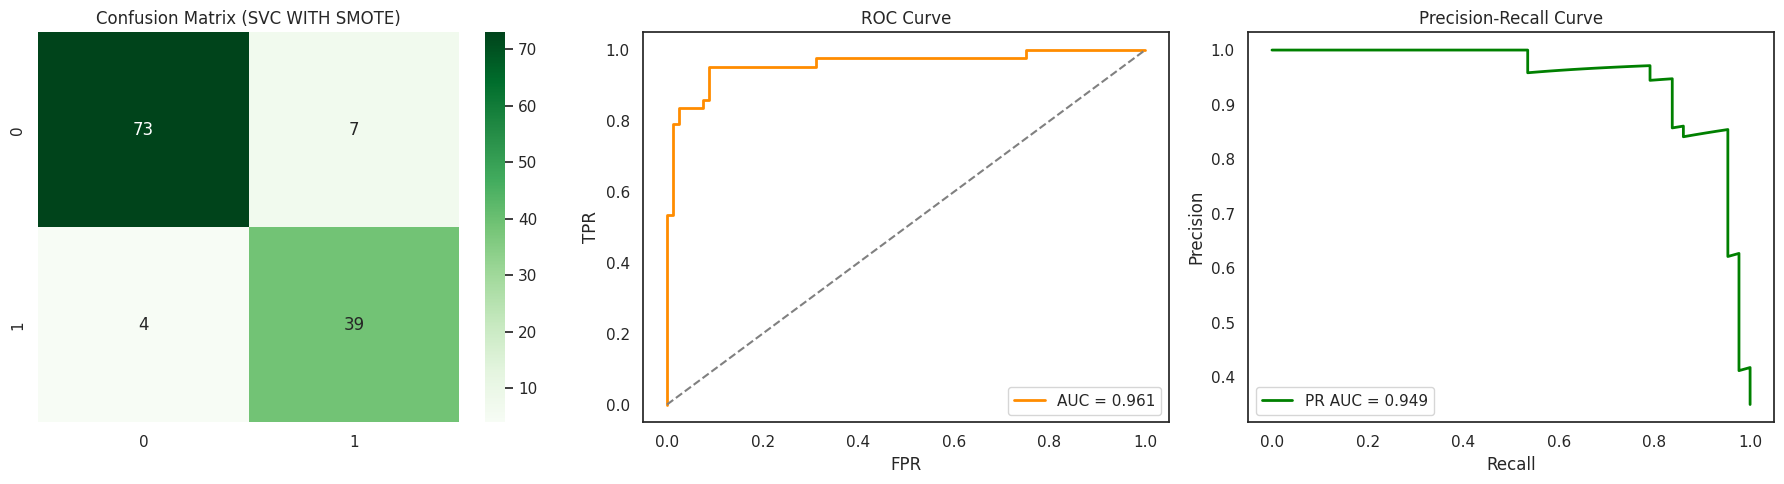


===== SVC Evaluation (WITH SMOTE) =====
AUC (ROC) : 0.9610
PR-AUC    : 0.9489


===== Repeated Stratified K-Fold CV (SVC with SMOTE) =====

===== Repeated CV Results (n_splits=5, n_repeats=10, total runs=50) =====
Accuracy: 0.9140 ± 0.0278
Precision: 0.9052 ± 0.0294
Recall: 0.9128 ± 0.0332
F1: 0.9067 ± 0.0308
ROC: 0.9870 ± 0.0070
LogLoss: 0.1714 ± 0.0433
MCC: 0.8177 ± 0.0597


,Model,Accuracy(cv),Precision(cv),Recall(cv),F1_score(cv),ROC(cv),Log_Loss(cv),mathew_corrcoef(cv),Accuracy(test),Precision(test),Recall(test),F1_score(test),ROC(test),Log_Loss(test),mathew_corrcoef(test)
0,RF (SMOTE),0.969553,0.966891,0.967450,0.966623,0.996861,0.095754,0.934253,0.959350,0.963404,0.947238,0.954542,0.989535,0.136854,0.910498
1,XGBoost (SMOTE),0.963410,0.960656,0.961384,0.960023,0.994787,0.102435,0.921900,0.943089,0.951548,0.923983,0.935578,0.976453,0.170344,0.875096
2,DT (SMOTE),0.951227,0.949893,0.945561,0.946262,0.982819,0.459084,0.895230,0.926829,0.926355,0.911483,0.918176,0.917878,1.835286,0.837706
3,AdaBoost (SMOTE),0.926881,0.915087,0.933185,0.921640,0.983113,0.295446,0.848025,0.926829,0.921517,0.916860,0.919109,0.973837,0.307622,0.838364
4,SVC (SMOTE),0.914677,0.901700,0.921003,0.909005,0.988083,0.163938,0.822460,0.910569,0.897939,0.909738,0.903170,0.961047,0.222713,0.807591
5,LR (SMOTE),0.892352,0.878519,0.898444,0.885350,0.977910,0.248953,0.776687,0.902439,0.896341,0.887355,0.891534,0.956686,0.268969,0.783645
6,MLP (SMOTE),0.874067,0.865439,0.856883,0.860104,0.944880,0.423712,0.722145,0.853659,0.841463,0.833721,0.837302,0.935756,0.347735,0.675140


In [ ]:
from imblearn.over_sampling import SMOTE                      # <-- Import SMOTE
from sklearn.model_selection import StratifiedKFold, RepeatedStratifiedKFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, log_loss, matthews_corrcoef, confusion_matrix,
                             roc_curve, auc, precision_recall_curve)
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# PART 1: K-Fold Cross Validation WITH SMOTE + Fold-wise Scaling
# ============================================================

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_acc, fold_precision, fold_recall = [], [], []
fold_f1, fold_roc, fold_logloss, fold_mcc = [], [], [], []

# Raw (unscaled) data
X_train_arr = X_train.values if hasattr(X_train, "values") else X_train
y_train_arr = y_train.values if hasattr(y_train, "values") else y_train

print("Fold-wise Results (SVC - WITH SMOTE):\n")

for i, (train_idx, val_idx) in enumerate(kf.split(X_train_arr, y_train_arr), 1):
    X_tr, X_val = X_train_arr[train_idx], X_train_arr[val_idx]
    y_tr, y_val = y_train_arr[train_idx], y_train_arr[val_idx]

    # ---- Fold-wise MinMax Scaling (fit ONLY on training fold) ----
    scaler = MinMaxScaler()
    X_tr = scaler.fit_transform(X_tr)
    X_val = scaler.transform(X_val)

    # Apply SMOTE only to the training fold (no data leakage)
    smote = SMOTE(random_state=42)
    X_tr_resampled, y_tr_resampled = smote.fit_resample(X_tr, y_tr)

    # Model: removed class_weight='balanced' because SMOTE handles imbalance
    model = SVC(
        kernel='rbf',
        C=0.5,
        gamma='scale',
        probability=True,
        random_state=42
    )
    model.fit(X_tr_resampled, y_tr_resampled)                 # Train on resampled fold

    # Predict on the original validation set
    y_val_pred = model.predict(X_val)
    y_val_prob = model.predict_proba(X_val)[:,1]

    # Metrics
    acc = accuracy_score(y_val, y_val_pred)
    precision = precision_score(y_val, y_val_pred, average='macro')
    recall = recall_score(y_val, y_val_pred, average='macro')
    f1 = f1_score(y_val, y_val_pred, average='macro')
    roc = roc_auc_score(y_val, y_val_prob)
    logloss_val = log_loss(y_val, y_val_prob)
    mcc_val = matthews_corrcoef(y_val, y_val_pred)
    CM_val = confusion_matrix(y_val, y_val_pred)

    fold_acc.append(acc)
    fold_precision.append(precision)
    fold_recall.append(recall)
    fold_f1.append(f1)
    fold_roc.append(roc)
    fold_logloss.append(logloss_val)
    fold_mcc.append(mcc_val)

    print(f"Fold {i} → Acc:{acc:.3f} | Prec:{precision:.3f} | Recall:{recall:.3f} | "
          f"F1:{f1:.3f} | ROC:{roc:.3f} | LogLoss:{logloss_val:.3f} | MCC:{mcc_val:.3f}")
    print(f"Confusion Matrix (Fold {i}):\n{CM_val}\n")

# ===== Fold-wise averages =====
print("\n===== CV Fold Average Metrics (SVC WITH SMOTE) =====")
print(f"Accuracy: {np.mean(fold_acc):.4f} ± {np.std(fold_acc):.4f}")
print(f"Precision: {np.mean(fold_precision):.4f} ± {np.std(fold_precision):.4f}")
print(f"Recall: {np.mean(fold_recall):.4f} ± {np.std(fold_recall):.4f}")
print(f"F1: {np.mean(fold_f1):.4f} ± {np.std(fold_f1):.4f}")
print(f"ROC: {np.mean(fold_roc):.4f} ± {np.std(fold_roc):.4f}")
print(f"LogLoss: {np.mean(fold_logloss):.4f} ± {np.std(fold_logloss):.4f}")
print(f"MCC: {np.mean(fold_mcc):.4f} ± {np.std(fold_mcc):.4f}")

# ===== Train final model (WITH SMOTE) =====
# Final scaler: পুরো training set দিয়ে fit, test set এ শুধু transform
final_scaler = MinMaxScaler()
X_train_scaled_final = final_scaler.fit_transform(X_train_arr)

X_test_arr = X_test.values if hasattr(X_test, "values") else X_test
X_test_scaled_final = final_scaler.transform(X_test_arr)

smote_final = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote_final.fit_resample(X_train_scaled_final, y_train_arr)

final_model = SVC(
    kernel='rbf',
    C=0.5,
    gamma='scale',
    probability=True,
    random_state=42
)
final_model.fit(X_train_resampled, y_train_resampled)

# ===== CV metrics (renamed train -> cv) =====
acc_cv       = np.mean(fold_acc)
precision_cv = np.mean(fold_precision)
recall_cv    = np.mean(fold_recall)
f1_cv        = np.mean(fold_f1)
roc_cv       = np.mean(fold_roc)
logloss_cv   = np.mean(fold_logloss)
mcc_cv       = np.mean(fold_mcc)

# ===== Test metrics =====
y_test_arr = y_test.values if hasattr(y_test, "values") else y_test

y_test_pred = final_model.predict(X_test_scaled_final)
y_test_prob = final_model.predict_proba(X_test_scaled_final)[:,1]

acc_test = accuracy_score(y_test_arr, y_test_pred)
precision_test = precision_score(y_test_arr, y_test_pred, average='macro')
recall_test = recall_score(y_test_arr, y_test_pred, average='macro')
f1_test = f1_score(y_test_arr, y_test_pred, average='macro')
roc_test = roc_auc_score(y_test_arr, y_test_prob)
logloss_test = log_loss(y_test_arr, y_test_prob)
mcc_test = matthews_corrcoef(y_test_arr, y_test_pred)

# ===== Curves =====
CM = confusion_matrix(y_test_arr, y_test_pred)
fpr, tpr, _ = roc_curve(y_test_arr, y_test_prob)
roc_auc = auc(fpr, tpr)
precision_vals, recall_vals, _ = precision_recall_curve(y_test_arr, y_test_prob)
pr_auc = auc(recall_vals, precision_vals)

plt.figure(figsize=(18,5))

plt.subplot(1,3,1)
sns.heatmap(CM, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix (SVC WITH SMOTE)")

plt.subplot(1,3,2)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}", color='darkorange', lw=2)
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.legend(loc="lower right")

plt.subplot(1,3,3)
plt.plot(recall_vals, precision_vals, label=f"PR AUC = {pr_auc:.3f}", color='green', lw=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend(loc="lower left")

plt.tight_layout()
plt.show()

print("\n===== SVC Evaluation (WITH SMOTE) =====")
print(f"AUC (ROC) : {roc_auc:.4f}")
print(f"PR-AUC    : {pr_auc:.4f}")


# ============================================================
# PART 2: Repeated Stratified K-Fold Cross-Validation
# Purpose: Assess the stability and robustness of the model
# across multiple train-validation splits.
# ============================================================

N_SPLITS = 5
N_REPEATS = 10   # Total runs = 5 x 10 = 50

rskf = RepeatedStratifiedKFold(
    n_splits=N_SPLITS,
    n_repeats=N_REPEATS,
    random_state=42
)

rep_acc, rep_precision, rep_recall = [], [], []
rep_f1, rep_roc, rep_logloss, rep_mcc = [], [], [], []

print("\n\n===== Repeated Stratified K-Fold CV (SVC with SMOTE) =====\n")

for i, (train_idx, val_idx) in enumerate(
    rskf.split(X_train_arr, y_train_arr), 1
):
    X_tr, X_val = X_train_arr[train_idx], X_train_arr[val_idx]
    y_tr, y_val = y_train_arr[train_idx], y_train_arr[val_idx]

    # ---- Fold-wise MinMax Scaling (fit ONLY on training fold) ----
    scaler_rep = MinMaxScaler()
    X_tr = scaler_rep.fit_transform(X_tr)
    X_val = scaler_rep.transform(X_val)

    # Apply SMOTE only to the training fold to avoid data leakage
    smote_rep = SMOTE(random_state=42)
    X_tr_resampled, y_tr_resampled = smote_rep.fit_resample(X_tr, y_tr)

    model_rep = SVC(
        kernel='rbf',
        C=0.5,
        gamma='scale',
        probability=True,
        random_state=42
    )

    model_rep.fit(X_tr_resampled, y_tr_resampled)

    y_val_pred = model_rep.predict(X_val)
    y_val_prob = model_rep.predict_proba(X_val)[:,1]

    rep_acc.append(accuracy_score(y_val, y_val_pred))
    rep_precision.append(precision_score(y_val, y_val_pred, average='macro'))
    rep_recall.append(recall_score(y_val, y_val_pred, average='macro'))
    rep_f1.append(f1_score(y_val, y_val_pred, average='macro'))
    rep_roc.append(roc_auc_score(y_val, y_val_prob))
    rep_logloss.append(log_loss(y_val, y_val_prob))
    rep_mcc.append(matthews_corrcoef(y_val, y_val_pred))

    # Printing every run separately would produce a large output (50 runs),
    # so printing is disabled here.


# ===== Repeated CV Mean and Standard Deviation =====
print(f"===== Repeated CV Results (n_splits={N_SPLITS}, n_repeats={N_REPEATS}, total runs={N_SPLITS*N_REPEATS}) =====")
print(f"Accuracy: {np.mean(rep_acc):.4f} ± {np.std(rep_acc):.4f}")
print(f"Precision: {np.mean(rep_precision):.4f} ± {np.std(rep_precision):.4f}")
print(f"Recall: {np.mean(rep_recall):.4f} ± {np.std(rep_recall):.4f}")
print(f"F1: {np.mean(rep_f1):.4f} ± {np.std(rep_f1):.4f}")
print(f"ROC: {np.mean(rep_roc):.4f} ± {np.std(rep_roc):.4f}")
print(f"LogLoss: {np.mean(rep_logloss):.4f} ± {np.std(rep_logloss):.4f}")
print(f"MCC: {np.mean(rep_mcc):.4f} ± {np.std(rep_mcc):.4f}")


# ===== Store Repeated CV Results for Reporting =====
# These values are not added to comp_ev

acc_repcv       = np.mean(rep_acc)
acc_repcv_std   = np.std(rep_acc)
f1_repcv        = np.mean(rep_f1)
f1_repcv_std    = np.std(rep_f1)
mcc_repcv       = np.mean(rep_mcc)
mcc_repcv_std   = np.std(rep_mcc)


# ============================================================
# PART 3: Append metrics to comparison DataFrame
# Only the original CV/test metrics are added.
# ============================================================

r = comp_ev.shape[0]
comp_ev.loc[r] = ['SVC (SMOTE)', acc_cv, precision_cv, recall_cv, f1_cv, roc_cv,
                  logloss_cv, mcc_cv, acc_test, precision_test, recall_test, f1_test, roc_test,
                  logloss_test, mcc_test]

comp_ev = comp_ev.sort_values(by='Accuracy(test)', ascending=False).reset_index(drop=True)
comp_ev

# **LGBM**

Fold-wise Results (LGBM - WITH SMOTE + fold-wise scaling):

Fold 1 → Acc:0.970 | Prec:0.978 | Recall:0.957 | F1:0.966 | ROC:0.981 | LogLoss:0.107 | MCC:0.935
Confusion Matrix (Fold 1):
[[64  0]
 [ 3 32]]

Fold 2 → Acc:0.960 | Prec:0.962 | Recall:0.949 | F1:0.955 | ROC:0.984 | LogLoss:0.144 | MCC:0.911
Confusion Matrix (Fold 2):
[[63  1]
 [ 3 32]]

Fold 3 → Acc:0.980 | Prec:0.978 | Recall:0.978 | F1:0.978 | ROC:0.999 | LogLoss:0.081 | MCC:0.956
Confusion Matrix (Fold 3):
[[62  1]
 [ 1 34]]



/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/ut

Fold 4 → Acc:0.969 | Prec:0.959 | Recall:0.977 | F1:0.967 | ROC:0.998 | LogLoss:0.118 | MCC:0.936
Confusion Matrix (Fold 4):
[[61  3]
 [ 0 34]]

Fold 5 → Acc:0.969 | Prec:0.969 | Recall:0.963 | F1:0.966 | ROC:0.998 | LogLoss:0.083 | MCC:0.932
Confusion Matrix (Fold 5):
[[63  1]
 [ 2 32]]


===== CV Fold Average Metrics (LGBM WITH SMOTE + fold-wise scaling) =====
Accuracy: 0.9695 ± 0.0063
Precision: 0.9693 ± 0.0076
Recall: 0.9647 ± 0.0110
F1: 0.9664 ± 0.0071
ROC: 0.9920 ± 0.0079
LogLoss: 0.1068 ± 0.0232
MCC: 0.9339 ± 0.0140


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


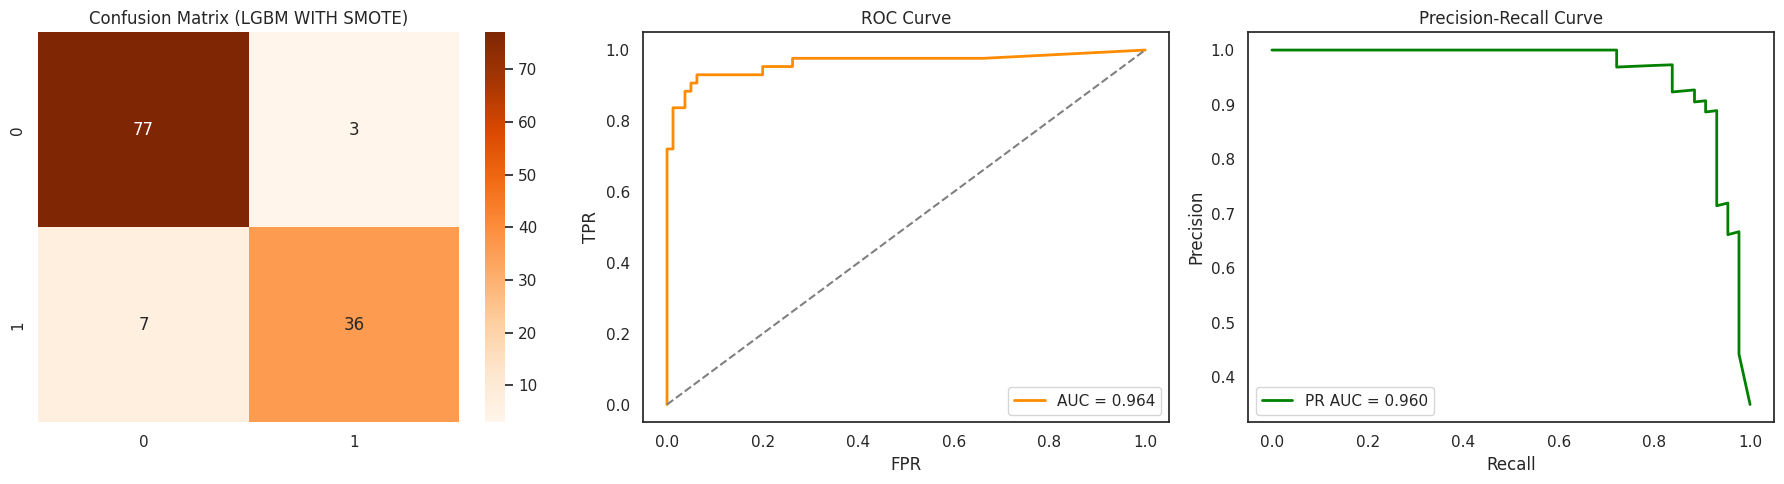


===== LGBM Evaluation (WITH SMOTE) =====
AUC (ROC) : 0.9641
PR-AUC    : 0.9599


===== Repeated Stratified K-Fold CV (LGBM with SMOTE + fold-wise scaling) =====



/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/ut

===== Repeated CV Results (n_splits=5, n_repeats=10, total runs=50) =====
Accuracy: 0.9689 ± 0.0182
Precision: 0.9669 ± 0.0203
Recall: 0.9655 ± 0.0208
F1: 0.9658 ± 0.0200
ROC: 0.9924 ± 0.0087
LogLoss: 0.1033 ± 0.0383
MCC: 0.9324 ± 0.0397


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,Model,Accuracy(cv),Precision(cv),Recall(cv),F1_score(cv),ROC(cv),Log_Loss(cv),mathew_corrcoef(cv),Accuracy(test),Precision(test),Recall(test),F1_score(test),ROC(test),Log_Loss(test),mathew_corrcoef(test)
0,RF (SMOTE),0.969553,0.966891,0.967450,0.966623,0.996861,0.095754,0.934253,0.959350,0.963404,0.947238,0.954542,0.989535,0.136854,0.910498
1,XGBoost (SMOTE),0.963410,0.960656,0.961384,0.960023,0.994787,0.102435,0.921900,0.943089,0.951548,0.923983,0.935578,0.976453,0.170344,0.875096
2,DT (SMOTE),0.951227,0.949893,0.945561,0.946262,0.982819,0.459084,0.895230,0.926829,0.926355,0.911483,0.918176,0.917878,1.835286,0.837706
3,AdaBoost (SMOTE),0.926881,0.915087,0.933185,0.921640,0.983113,0.295446,0.848025,0.926829,0.921517,0.916860,0.919109,0.973837,0.307622,0.838364
4,LightGBM (SMOTE),0.969532,0.969287,0.964718,0.966400,0.991982,0.106761,0.933906,0.918699,0.919872,0.899855,0.908537,0.964099,0.193061,0.819482
5,SVC (SMOTE),0.914677,0.901700,0.921003,0.909005,0.988083,0.163938,0.822460,0.910569,0.897939,0.909738,0.903170,0.961047,0.222713,0.807591
6,LR (SMOTE),0.892352,0.878519,0.898444,0.885350,0.977910,0.248953,0.776687,0.902439,0.896341,0.887355,0.891534,0.956686,0.268969,0.783645
7,MLP (SMOTE),0.874067,0.865439,0.856883,0.860104,0.944880,0.423712,0.722145,0.853659,0.841463,0.833721,0.837302,0.935756,0.347735,0.675140


In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold, RepeatedStratifiedKFold
from sklearn.preprocessing import MinMaxScaler
import lightgbm as lgb
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, log_loss, matthews_corrcoef, confusion_matrix,
                             roc_curve, auc, precision_recall_curve)
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# PART 1: K-Fold Cross Validation WITH SMOTE + Fold-wise Scaling
# ============================================================

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_acc, fold_precision, fold_recall = [], [], []
fold_f1, fold_roc, fold_logloss, fold_mcc = [], [], [], []

# Raw (unscaled) data - scaling will be done per fold
X_train_arr = X_train.values if hasattr(X_train, "values") else X_train
y_train_arr = y_train.values if hasattr(y_train, "values") else y_train

print("Fold-wise Results (LGBM - WITH SMOTE + fold-wise scaling):\n")

for i, (train_idx, val_idx) in enumerate(kf.split(X_train_arr, y_train_arr), 1):
    X_tr, X_val = X_train_arr[train_idx], X_train_arr[val_idx]
    y_tr, y_val = y_train_arr[train_idx], y_train_arr[val_idx]

    # ---- Fold-wise MinMax Scaling (fit ONLY on training fold) ----
    scaler = MinMaxScaler()
    X_tr = scaler.fit_transform(X_tr)
    X_val = scaler.transform(X_val)

    # Apply SMOTE only to the training fold (no data leakage)
    smote = SMOTE(random_state=42)
    X_tr_resampled, y_tr_resampled = smote.fit_resample(X_tr, y_tr)

    # Model: same hyperparameters as without SMOTE
    model = lgb.LGBMClassifier(
        n_estimators=100,
        learning_rate=0.03,
        num_leaves=15,
        min_data_in_leaf=10,
        lambda_l1=0.1,
        lambda_l2=0.1,
        min_gain_to_split=0.01,
        random_state=42,
        verbosity=-1
    )
    model.fit(X_tr_resampled, y_tr_resampled)                 # Train on resampled fold

    # Predict on the original validation set
    y_val_pred = model.predict(X_val)
    y_val_prob = model.predict_proba(X_val)[:,1]

    # Metrics
    acc = accuracy_score(y_val, y_val_pred)
    precision = precision_score(y_val, y_val_pred, average='macro')
    recall = recall_score(y_val, y_val_pred, average='macro')
    f1 = f1_score(y_val, y_val_pred, average='macro')
    roc = roc_auc_score(y_val, y_val_prob)
    logloss_val = log_loss(y_val, y_val_prob)
    mcc_val = matthews_corrcoef(y_val, y_val_pred)
    CM_val = confusion_matrix(y_val, y_val_pred)

    fold_acc.append(acc)
    fold_precision.append(precision)
    fold_recall.append(recall)
    fold_f1.append(f1)
    fold_roc.append(roc)
    fold_logloss.append(logloss_val)
    fold_mcc.append(mcc_val)

    print(f"Fold {i} → Acc:{acc:.3f} | Prec:{precision:.3f} | Recall:{recall:.3f} | "
          f"F1:{f1:.3f} | ROC:{roc:.3f} | LogLoss:{logloss_val:.3f} | MCC:{mcc_val:.3f}")
    print(f"Confusion Matrix (Fold {i}):\n{CM_val}\n")

# ===== Fold-wise averages =====
print("\n===== CV Fold Average Metrics (LGBM WITH SMOTE + fold-wise scaling) =====")
print(f"Accuracy: {np.mean(fold_acc):.4f} ± {np.std(fold_acc):.4f}")
print(f"Precision: {np.mean(fold_precision):.4f} ± {np.std(fold_precision):.4f}")
print(f"Recall: {np.mean(fold_recall):.4f} ± {np.std(fold_recall):.4f}")
print(f"F1: {np.mean(fold_f1):.4f} ± {np.std(fold_f1):.4f}")
print(f"ROC: {np.mean(fold_roc):.4f} ± {np.std(fold_roc):.4f}")
print(f"LogLoss: {np.mean(fold_logloss):.4f} ± {np.std(fold_logloss):.4f}")
print(f"MCC: {np.mean(fold_mcc):.4f} ± {np.std(fold_mcc):.4f}")

# ===== Train final model (WITH SMOTE) =====
# Final scaler: fit on entire training set, transform test set
final_scaler = MinMaxScaler()
X_train_scaled_final = final_scaler.fit_transform(X_train_arr)

X_test_arr = X_test.values if hasattr(X_test, "values") else X_test
X_test_scaled_final = final_scaler.transform(X_test_arr)

smote_final = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote_final.fit_resample(X_train_scaled_final, y_train_arr)

final_model = lgb.LGBMClassifier(
    n_estimators=100,
    learning_rate=0.03,
    num_leaves=15,
    min_data_in_leaf=10,
    lambda_l1=0.1,
    lambda_l2=0.1,
    min_gain_to_split=0.01,
    random_state=42,
    verbosity=-1
)
final_model.fit(X_train_resampled, y_train_resampled)

# ===== CV metrics (renamed as train/cv) =====
acc_cv       = np.mean(fold_acc)
precision_cv = np.mean(fold_precision)
recall_cv    = np.mean(fold_recall)
f1_cv        = np.mean(fold_f1)
roc_cv       = np.mean(fold_roc)
logloss_cv   = np.mean(fold_logloss)
mcc_cv       = np.mean(fold_mcc)

# ===== Test metrics =====
y_test_arr = y_test.values if hasattr(y_test, "values") else y_test

y_test_pred = final_model.predict(X_test_scaled_final)
y_test_prob = final_model.predict_proba(X_test_scaled_final)[:,1]

acc_test = accuracy_score(y_test_arr, y_test_pred)
precision_test = precision_score(y_test_arr, y_test_pred, average='macro')
recall_test = recall_score(y_test_arr, y_test_pred, average='macro')
f1_test = f1_score(y_test_arr, y_test_pred, average='macro')
roc_test = roc_auc_score(y_test_arr, y_test_prob)
logloss_test = log_loss(y_test_arr, y_test_prob)
mcc_test = matthews_corrcoef(y_test_arr, y_test_pred)

# ===== Curves =====
CM = confusion_matrix(y_test_arr, y_test_pred)
fpr, tpr, _ = roc_curve(y_test_arr, y_test_prob)
roc_auc = auc(fpr, tpr)
precision_vals, recall_vals, _ = precision_recall_curve(y_test_arr, y_test_prob)
pr_auc = auc(recall_vals, precision_vals)

plt.figure(figsize=(18,5))

plt.subplot(1,3,1)
sns.heatmap(CM, annot=True, fmt='d', cmap='Oranges')
plt.title("Confusion Matrix (LGBM WITH SMOTE)")

plt.subplot(1,3,2)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}", color='darkorange', lw=2)
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.legend(loc="lower right")

plt.subplot(1,3,3)
plt.plot(recall_vals, precision_vals, label=f"PR AUC = {pr_auc:.3f}", color='green', lw=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend(loc="lower left")

plt.tight_layout()
plt.show()

print("\n===== LGBM Evaluation (WITH SMOTE) =====")
print(f"AUC (ROC) : {roc_auc:.4f}")
print(f"PR-AUC    : {pr_auc:.4f}")


# ============================================================
# PART 2: Repeated Stratified K-Fold Cross-Validation
# Purpose: Assess the stability and robustness of the model
# across multiple train-validation splits.
# ============================================================

N_SPLITS = 5
N_REPEATS = 10   # Total runs = 5 x 10 = 50

rskf = RepeatedStratifiedKFold(
    n_splits=N_SPLITS,
    n_repeats=N_REPEATS,
    random_state=42
)

rep_acc, rep_precision, rep_recall = [], [], []
rep_f1, rep_roc, rep_logloss, rep_mcc = [], [], [], []

print("\n\n===== Repeated Stratified K-Fold CV (LGBM with SMOTE + fold-wise scaling) =====\n")

for i, (train_idx, val_idx) in enumerate(
    rskf.split(X_train_arr, y_train_arr), 1
):
    X_tr, X_val = X_train_arr[train_idx], X_train_arr[val_idx]
    y_tr, y_val = y_train_arr[train_idx], y_train_arr[val_idx]

    # ---- Fold-wise MinMax Scaling (fit ONLY on training fold) ----
    scaler_rep = MinMaxScaler()
    X_tr = scaler_rep.fit_transform(X_tr)
    X_val = scaler_rep.transform(X_val)

    # Apply SMOTE only to the training fold to avoid data leakage
    smote_rep = SMOTE(random_state=42)
    X_tr_resampled, y_tr_resampled = smote_rep.fit_resample(X_tr, y_tr)

    model_rep = lgb.LGBMClassifier(
        n_estimators=100,
        learning_rate=0.03,
        num_leaves=15,
        min_data_in_leaf=10,
        lambda_l1=0.1,
        lambda_l2=0.1,
        min_gain_to_split=0.01,
        random_state=42,
        verbosity=-1
    )

    model_rep.fit(X_tr_resampled, y_tr_resampled)

    y_val_pred = model_rep.predict(X_val)
    y_val_prob = model_rep.predict_proba(X_val)[:,1]

    rep_acc.append(accuracy_score(y_val, y_val_pred))
    rep_precision.append(precision_score(y_val, y_val_pred, average='macro'))
    rep_recall.append(recall_score(y_val, y_val_pred, average='macro'))
    rep_f1.append(f1_score(y_val, y_val_pred, average='macro'))
    rep_roc.append(roc_auc_score(y_val, y_val_prob))
    rep_logloss.append(log_loss(y_val, y_val_prob))
    rep_mcc.append(matthews_corrcoef(y_val, y_val_pred))

    # Printing every run would be too long (50 runs) – disabled.

# ===== Repeated CV Mean and Standard Deviation =====
print(f"===== Repeated CV Results (n_splits={N_SPLITS}, n_repeats={N_REPEATS}, total runs={N_SPLITS*N_REPEATS}) =====")
print(f"Accuracy: {np.mean(rep_acc):.4f} ± {np.std(rep_acc):.4f}")
print(f"Precision: {np.mean(rep_precision):.4f} ± {np.std(rep_precision):.4f}")
print(f"Recall: {np.mean(rep_recall):.4f} ± {np.std(rep_recall):.4f}")
print(f"F1: {np.mean(rep_f1):.4f} ± {np.std(rep_f1):.4f}")
print(f"ROC: {np.mean(rep_roc):.4f} ± {np.std(rep_roc):.4f}")
print(f"LogLoss: {np.mean(rep_logloss):.4f} ± {np.std(rep_logloss):.4f}")
print(f"MCC: {np.mean(rep_mcc):.4f} ± {np.std(rep_mcc):.4f}")


# ============================================================
# PART 3: Append metrics to comparison DataFrame
# Only the original CV/test metrics are added.
# Repeated CV results are NOT added to comp_ev.
# ============================================================

r = comp_ev.shape[0]
comp_ev.loc[r] = ['LightGBM (SMOTE)', acc_cv, precision_cv, recall_cv, f1_cv, roc_cv,
                  logloss_cv, mcc_cv, acc_test, precision_test, recall_test, f1_test, roc_test,
                  logloss_test, mcc_test]

comp_ev = comp_ev.sort_values(by='Accuracy(test)', ascending=False).reset_index(drop=True)
comp_ev

# **Feature Selection Algorithms**

## **Chi-Squared**

In [ ]:
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

# Scale to non-negative
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Apply chi2
chi2_selector = SelectKBest(chi2, k='all')
chi2_selector.fit(X_train_scaled, y_train)

# Create DataFrame
chi2_scores = pd.DataFrame({
    'Feature': X_train.columns,
    'Score': chi2_selector.scores_,
    'PValue': chi2_selector.pvalues_
}).sort_values('Score', ascending=False)

# Select significant features
significant_features = chi2_scores[chi2_scores['PValue'] < 0.05]['Feature'].tolist()

print(chi2_scores.head(24))
print(f"\nSelected Features: {significant_features}")
print(f"Total: {len(significant_features)}")

                          Feature      Score        PValue
6                Age_at_Diagnosis  90.259999  2.088322e-21
21                Low_Income_Flag  85.375150  2.468028e-20
7                Thalassemia_Type  71.270860  3.114011e-17
20      Severe_Iron_Overload_Flag  67.789969  1.818724e-16
19             Severe_Anemia_Flag  65.620690  5.466190e-16
4        Monthly_Household_Income  51.481222  7.228520e-13
14                HbF_Percent (%)  44.434032  2.630740e-11
23             Log_Serum_Ferritin  41.752440  1.035929e-10
13         Reticulocyte_Count (%)  40.081904  2.435346e-10
11                       MCH (pg)  37.002968  1.179496e-09
10                       MCV (fL)  36.865863  1.265423e-09
12                        RDW (%)  34.717982  3.810952e-09
8       Pre-Transfusion_Hb (g/dL)  27.451230  1.611064e-07
9          Serum_Ferritin (ng/mL)  25.308099  4.886526e-07
22                 Pediatric_Flag  21.397735  3.732118e-06
15                    BMI (kg/m²)  18.670089  1.554012e-

# **ANOVA**

In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Apply ANOVA
anova_selector = SelectKBest(f_classif, k='all')
anova_selector.fit(X_train_scaled, y_train)

# Create DataFrame
anova_scores = pd.DataFrame({
    'Feature': X_train.columns,
    'F_Score': anova_selector.scores_,
    'PValue': anova_selector.pvalues_
}).sort_values('F_Score', ascending=False)

# Select features
anova_selected = anova_scores[anova_scores['PValue'] < 0.05]['Feature'].tolist()

print(anova_scores.head(24))
print(f"\nSelected Features: {anova_selected}")
print(f"Total: {len(anova_selected)}")

                          Feature     F_Score         PValue
10                       MCV (fL)  820.803566  9.100566e-107
23             Log_Serum_Ferritin  740.555220  4.893038e-100
6                Age_at_Diagnosis  722.889077   1.699310e-98
11                       MCH (pg)  660.840243   6.695491e-93
4        Monthly_Household_Income  655.275426   2.199427e-92
7                Thalassemia_Type  632.532846   3.018337e-90
12                        RDW (%)  417.789919   1.305366e-67
8       Pre-Transfusion_Hb (g/dL)  394.474006   7.781453e-65
15                    BMI (kg/m²)  330.711493   7.482664e-57
14                HbF_Percent (%)  307.360136   9.013847e-54
17                    MCHC_approx  292.678908   8.685627e-52
21                Low_Income_Flag  243.751552   6.802853e-45
13         Reticulocyte_Count (%)  229.813200   7.618468e-43
9          Serum_Ferritin (ng/mL)  196.956318   7.518577e-38
20      Severe_Iron_Overload_Flag  111.015946   1.550704e-23
16            Iron_Overl

# **Mutual Information**

In [ ]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd
import numpy as np

# Stability improvement (average over multiple runs)
mi_runs = []
for i in range(5):
    mi = mutual_info_classif(X_train, y_train, random_state=i)
    mi_runs.append(mi)

mi_scores = np.mean(mi_runs, axis=0)

# Create DataFrame
mi_scores_df = pd.DataFrame({
    'Feature': X_train.columns,
    'MI_Score': mi_scores
}).sort_values('MI_Score', ascending=False)

# Select top-k features
k = 15
mi_selected = mi_scores_df.head(k)['Feature'].tolist()

print(mi_scores_df.head(24))
print(f"\nTop {k} MI Features: {mi_selected}")
print(f"Total selected features: {len(mi_selected)}")

                          Feature  MI_Score
8       Pre-Transfusion_Hb (g/dL)  0.517387
16            Iron_Overload_Index  0.479271
10                       MCV (fL)  0.472829
14                HbF_Percent (%)  0.452045
11                       MCH (pg)  0.442041
17                    MCHC_approx  0.430491
9          Serum_Ferritin (ng/mL)  0.417281
13         Reticulocyte_Count (%)  0.414861
23             Log_Serum_Ferritin  0.413751
12                        RDW (%)  0.408251
7                Thalassemia_Type  0.405537
6                Age_at_Diagnosis  0.396763
4        Monthly_Household_Income  0.372754
15                    BMI (kg/m²)  0.358300
5   Travel_Time_to_Hospital (min)  0.245153
21                Low_Income_Flag  0.183518
20      Severe_Iron_Overload_Flag  0.131885
18               Disease_Duration  0.131240
0                     Current_Age  0.127928
19             Severe_Anemia_Flag  0.125906
3                 Education_Level  0.098778
2                  Residence_Typ

# **Recursive Feature Elimination (RFE)**

In [ ]:
from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier

rfecv = RFECV(
    estimator=RandomForestClassifier(random_state=42, n_estimators=100),
    step=1,
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring='f1',
    min_features_to_select=1,
    n_jobs=-1
)

rfecv.fit(X_train, y_train)

rfe_selected_features = X_train.columns[rfecv.support_].tolist()

print("Selected Features:", rfe_selected_features)
print("Optimal Number:", rfecv.n_features_)
print("Ranking:", dict(zip(X_train.columns, rfecv.ranking_)))

Selected Features: ['Current_Age', 'Gender', 'Residence_Type', 'Education_Level', 'Monthly_Household_Income', 'Travel_Time_to_Hospital (min)', 'Age_at_Diagnosis', 'Thalassemia_Type', 'Pre-Transfusion_Hb (g/dL)', 'Serum_Ferritin (ng/mL)', 'MCV (fL)', 'MCH (pg)', 'RDW (%)', 'Reticulocyte_Count (%)', 'HbF_Percent (%)', 'BMI (kg/m²)', 'Iron_Overload_Index', 'MCHC_approx', 'Disease_Duration', 'Severe_Anemia_Flag', 'Severe_Iron_Overload_Flag', 'Low_Income_Flag', 'Pediatric_Flag', 'Log_Serum_Ferritin']
Optimal Number: 24
Ranking: {'Current_Age': np.int64(1), 'Gender': np.int64(1), 'Residence_Type': np.int64(1), 'Education_Level': np.int64(1), 'Monthly_Household_Income': np.int64(1), 'Travel_Time_to_Hospital (min)': np.int64(1), 'Age_at_Diagnosis': np.int64(1), 'Thalassemia_Type': np.int64(1), 'Pre-Transfusion_Hb (g/dL)': np.int64(1), 'Serum_Ferritin (ng/mL)': np.int64(1), 'MCV (fL)': np.int64(1), 'MCH (pg)': np.int64(1), 'RDW (%)': np.int64(1), 'Reticulocyte_Count (%)': np.int64(1), 'HbF_Perc

# **RFE-MI (Hybrid Approach)**

In [ ]:
from sklearn.feature_selection import mutual_info_classif, RFECV
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import numpy as np

# Step 1: Stable MI scores
mi_runs = []
for i in range(5):
    mi = mutual_info_classif(X_train, y_train, random_state=i)
    mi_runs.append(mi)

mi_scores_all = np.mean(mi_runs, axis=0)

mi_scores_df = pd.DataFrame({
    'Feature': X_train.columns,
    'MI_Score': mi_scores_all
}).sort_values('MI_Score', ascending=False)

# Step 2: Select top-k features
top_k = 15
selected_mi_features = mi_scores_df.head(top_k)['Feature'].tolist()

X_train_mi_selected = X_train[selected_mi_features]

# Step 3: RFECV
rfecv_mi = RFECV(
    estimator=RandomForestClassifier(random_state=42, n_estimators=100),
    step=1,
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring='f1',
    n_jobs=-1
)

rfecv_mi.fit(X_train_mi_selected, y_train)

# Step 4: Final features
rfe_mi_selected = X_train_mi_selected.columns[rfecv_mi.support_].tolist()

print("Final Selected Features:", rfe_mi_selected)
print("Optimal Number:", rfecv_mi.n_features_)

Final Selected Features: ['Pre-Transfusion_Hb (g/dL)', 'Iron_Overload_Index', 'MCV (fL)', 'HbF_Percent (%)', 'MCH (pg)', 'MCHC_approx', 'Serum_Ferritin (ng/mL)', 'Reticulocyte_Count (%)', 'Log_Serum_Ferritin', 'RDW (%)', 'Thalassemia_Type', 'Age_at_Diagnosis', 'Monthly_Household_Income', 'BMI (kg/m²)', 'Travel_Time_to_Hospital (min)']
Optimal Number: 15


# **Pearson correlation**

In [ ]:
import pandas as pd
from scipy.stats import pearsonr
from statsmodels.stats.multitest import multipletests

pearson_list = []

for feature in X_train.columns:
    corr, pval = pearsonr(X_train[feature], y_train)
    pearson_list.append({
        'Feature': feature,
        'Correlation': corr,
        'PValue': pval
    })

pearson_scores = pd.DataFrame(pearson_list)
pearson_scores['Abs_Correlation'] = pearson_scores['Correlation'].abs()

# Multiple testing correction
pearson_scores['Adj_PValue'] = multipletests(pearson_scores['PValue'], method='fdr_bh')[1]

# Sort by absolute correlation
pearson_scores = pearson_scores.sort_values('Abs_Correlation', ascending=False)

# Select significant features
pearson_selected = pearson_scores[pearson_scores['Adj_PValue'] < 0.05]['Feature'].tolist()

print("Top Pearson correlations:")
print(pearson_scores.head(22))
print(f"\nPearson-selected features: {pearson_selected}")
print(f"Total selected features: {len(pearson_selected)}")

Top Pearson correlations:
                      Feature  Correlation         PValue  Abs_Correlation  \
10                   MCV (fL)     0.791318  9.100566e-107         0.791318   
23         Log_Serum_Ferritin    -0.775761  4.893038e-100         0.775761   
6            Age_at_Diagnosis     0.772014   1.699310e-98         0.772014   
11                   MCH (pg)     0.757776   6.695491e-93         0.757776   
4    Monthly_Household_Income     0.756409   2.199427e-92         0.756409   
7            Thalassemia_Type    -0.750658   3.018337e-90         0.750658   
12                    RDW (%)    -0.678401   1.305366e-67         0.678401   
8   Pre-Transfusion_Hb (g/dL)     0.667831   7.781453e-65         0.667831   
15                BMI (kg/m²)     0.634789   7.482664e-57         0.634789   
14            HbF_Percent (%)    -0.620864   9.013847e-54         0.620864   
17                MCHC_approx     0.611510   8.685627e-52         0.611510   
21            Low_Income_Flag    -0.57

In [ ]:
pip install numpy pandas scikit-learn xgboost networkx

# **AMSE-DFI Feature Selection**

In [ ]:
import numpy as np
import pandas as pd
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import MinMaxScaler
import networkx as nx


# ------------------------------------------------
# AMSE-DFI Feature Selection
# ------------------------------------------------
def amse_dfi_feature_selection(X, y, keep_ratio=0.7, top_k=15):

    # -----------------------------
    # STEP 1 : Mutual Information
    # -----------------------------
    mi_scores = mutual_info_classif(X, y)

    mi_df = pd.DataFrame({
        "feature": X.columns,
        "mi_score": mi_scores
    })

    mi_df = mi_df.sort_values("mi_score", ascending=False)

    # Keep top % features
    k = int(len(mi_df) * keep_ratio)
    selected_mi_features = mi_df.head(k)["feature"].tolist()

    X_filtered = X[selected_mi_features]


    # -----------------------------
    # STEP 2 : Ensemble Importance
    # -----------------------------
    rf = RandomForestClassifier(
        n_estimators=200,
        random_state=42
    )

    rf.fit(X_filtered, y)
    rf_importance = rf.feature_importances_

    xgb = XGBClassifier(
        eval_metric='logloss',
        random_state=42
    )

    xgb.fit(X_filtered, y)
    xgb_importance = xgb.feature_importances_

    ensemble_importance = 0.5 * rf_importance + 0.5 * xgb_importance

    ensemble_df = pd.DataFrame({
        "feature": X_filtered.columns,
        "importance": ensemble_importance
    })


    # -----------------------------
    # STEP 3 : Feature Interaction
    # -----------------------------
    corr_matrix = X_filtered.corr()

    G = nx.Graph()

    for feature in X_filtered.columns:
        G.add_node(feature)

    for i in range(len(corr_matrix.columns)):
        for j in range(i + 1, len(corr_matrix.columns)):

            weight = abs(corr_matrix.iloc[i, j])

            if weight > 0.1:
                G.add_edge(
                    corr_matrix.columns[i],
                    corr_matrix.columns[j],
                    weight=weight
                )

    interaction_scores = {}

    for node in G.nodes():

        neighbors = list(G.neighbors(node))

        if len(neighbors) == 0:
            interaction_scores[node] = 0

        else:
            weights = [
                G[node][nbr]["weight"] for nbr in neighbors
            ]

            interaction_scores[node] = np.mean(weights)

    gat_df = pd.DataFrame({
        "feature": list(interaction_scores.keys()),
        "gat_score": list(interaction_scores.values())
    })


    # -----------------------------
    # STEP 4 : Combine Scores
    # -----------------------------
    merged = mi_df.merge(ensemble_df, on="feature")
    merged = merged.merge(gat_df, on="feature")

    scaler = MinMaxScaler()

    merged[["mi_score", "importance", "gat_score"]] = scaler.fit_transform(
        merged[["mi_score", "importance", "gat_score"]]
    )

    # Final Score
    merged["final_score"] = (
        0.3 * merged["mi_score"] +
        0.4 * merged["importance"] +
        0.3 * merged["gat_score"]
    )

    merged = merged.sort_values("final_score", ascending=False)

    selected_features = merged.head(top_k)["feature"].tolist()

    return selected_features, merged


# ------------------------------------------------
# Example Usage (WITH YOUR TRAIN DATA)
# ------------------------------------------------
selected_features, ranking = amse_dfi_feature_selection(
    X_train,
    y_train,
    top_k=24
)

print("Selected Features:")
print(selected_features)

print("\nTotal selected features:", len(selected_features))

print("\nFeature Ranking:")
print(ranking.head(24))

Selected Features:
['HbF_Percent (%)', 'MCV (fL)', 'Pre-Transfusion_Hb (g/dL)', 'Log_Serum_Ferritin', 'Serum_Ferritin (ng/mL)', 'MCH (pg)', 'Iron_Overload_Index', 'Reticulocyte_Count (%)', 'MCHC_approx', 'RDW (%)', 'Thalassemia_Type', 'Age_at_Diagnosis', 'BMI (kg/m²)', 'Monthly_Household_Income', 'Low_Income_Flag', 'Travel_Time_to_Hospital (min)']

Total selected features: 16

Feature Ranking:
                          feature  mi_score  importance  gat_score  \
2                 HbF_Percent (%)  0.857707    1.000000   0.967183   
3                        MCV (fL)  0.829207    0.527337   0.984849   
0       Pre-Transfusion_Hb (g/dL)  1.000000    0.131512   0.987540   
7              Log_Serum_Ferritin  0.732629    0.165816   0.981997   
5          Serum_Ferritin (ng/mL)  0.770159    0.185708   0.915517   
4                        MCH (pg)  0.808951    0.085630   0.998500   
1             Iron_Overload_Index  0.902358    0.152688   0.801599   
9          Reticulocyte_Count (%)  0.697856

# **Voating Technique with 7 Feature Selection Algorithms**

In [ ]:
import pandas as pd
from IPython.display import display

# ----------------------------
# 1. All features
# ----------------------------
all_features = X_train.columns.tolist()

# ----------------------------
# 2. Sob selected features from your code
# ----------------------------
pearson_features = pearson_selected
chi_features = significant_features
anova_features = anova_selected
mi_features = mi_selected
rfe_features = rfe_selected_features
rfe_mi_features = rfe_mi_selected
amse_features = selected_features

# ----------------------------
# 3. Create selection matrix
# ----------------------------
feature_matrix = pd.DataFrame({'Feature': all_features})

def mark_selected(feat, selected_list):
    return '✓' if feat in selected_list else '×'

feature_matrix['Pearson'] = feature_matrix['Feature'].apply(lambda x: mark_selected(x, pearson_features))
feature_matrix['Chi-Squared'] = feature_matrix['Feature'].apply(lambda x: mark_selected(x, chi_features))
feature_matrix['ANOVA'] = feature_matrix['Feature'].apply(lambda x: mark_selected(x, anova_features))
feature_matrix['MI'] = feature_matrix['Feature'].apply(lambda x: mark_selected(x, mi_features))
feature_matrix['RFE'] = feature_matrix['Feature'].apply(lambda x: mark_selected(x, rfe_features))
feature_matrix['RFE-MI'] = feature_matrix['Feature'].apply(lambda x: mark_selected(x, rfe_mi_features))
feature_matrix['AMSE-DFI'] = feature_matrix['Feature'].apply(lambda x: mark_selected(x, amse_features))

# ----------------------------
# 4. Add vote count column
# ----------------------------
algo_columns = ['Pearson','Chi-Squared','ANOVA','MI','RFE','RFE-MI','AMSE-DFI']
feature_matrix['Vote'] = feature_matrix[algo_columns].apply(lambda row: sum([1 if v=='✓' else 0 for v in row]), axis=1)

# ----------------------------
# 5. Sort by Vote descending & Feature name
# ----------------------------
feature_matrix = feature_matrix.sort_values(['Vote','Feature'], ascending=[False, True]).reset_index(drop=True)

# ----------------------------
# 6. Display in table format
# ----------------------------
# Using IPython.display for nicer DataFrame in Jupyter/Colab
display(feature_matrix)

,Feature,Pearson,Chi-Squared,ANOVA,MI,RFE,RFE-MI,AMSE-DFI,Vote
0,Age_at_Diagnosis,✓,✓,✓,✓,✓,✓,✓,7
1,BMI (kg/m²),✓,✓,✓,✓,✓,✓,✓,7
2,HbF_Percent (%),✓,✓,✓,✓,✓,✓,✓,7
3,Iron_Overload_Index,✓,✓,✓,✓,✓,✓,✓,7
4,Log_Serum_Ferritin,✓,✓,✓,✓,✓,✓,✓,7
5,MCH (pg),✓,✓,✓,✓,✓,✓,✓,7
6,MCHC_approx,✓,✓,✓,✓,✓,✓,✓,7
7,MCV (fL),✓,✓,✓,✓,✓,✓,✓,7
8,Monthly_Household_Income,✓,✓,✓,✓,✓,✓,✓,7
9,Pre-Transfusion_Hb (g/dL),✓,✓,✓,✓,✓,✓,✓,7


# **Apply ML Algorithms with Top 14 Selected Features**

In [ ]:
# segregating dataset into features i.e., X and target variables i.e., y
X = df.drop(['Mental_Health_Status'], axis=1)
y = df['Mental_Health_Status']

In [ ]:
top_14 = [
    'Age_at_Diagnosis',
    'BMI (kg/m²)',
    'HbF_Percent (%)',
    'Iron_Overload_Index',
    'Log_Serum_Ferritin',
    'MCH (pg)',
    'MCHC_approx',
    'MCV (fL)',
    'Monthly_Household_Income',
    'Pre-Transfusion_Hb (g/dL)',
    'RDW (%)',
    'Reticulocyte_Count (%)',
    'Serum_Ferritin (ng/mL)',
    'Thalassemia_Type'
]

In [ ]:
# subset of X with MI features
X_fs = X[top_14]

In [ ]:
print("Total features in X:", len(X.columns))
print("Top 14 selected:", len(top_14))

Total features in X: 24
Top 14 selected: 14


In [ ]:
# Selected features subset (X_fs)
X_fs = X[top_14]

X_train, X_test, y_train, y_test = train_test_split(X_fs, y, stratify=y, test_size=0.2, shuffle=True, random_state=42)

# Repeated CV
from sklearn.model_selection import RepeatedStratifiedKFold

rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)

# checking distribution
print('Distribution of target variable in training set')
print(y_train.value_counts())

print('Distribution of target variable in test set')
print(y_test.value_counts())

Distribution of target variable in training set
Mental_Health_Status
0    319
1    173
Name: count, dtype: int64
Distribution of target variable in test set
Mental_Health_Status
0    80
1    43
Name: count, dtype: int64


In [ ]:
comp_ev = pd.DataFrame({
    'Model'                  : [],
    'Accuracy(cv)'           : [],
    'Precision(cv)'          : [],
    'Recall(cv)'             : [],
    'F1_score(cv)'           : [],
    'ROC(cv)'                : [],
    'Log_Loss(cv)'           : [],
    'mathew_corrcoef(cv)'    : [],
    'Accuracy(test)'         : [],
    'Precision(test)'        : [],
    'Recall(test)'           : [],
    'F1_score(test)'         : [],
    'ROC(test)'              : [],
    'Log_Loss(test)'         : [],
    'mathew_corrcoef(test)'  : []
})

# **LR**

Fold-wise Results (Logistic Regression - WITH SMOTE):

Fold 1 → Acc:0.848 | Prec:0.886 | Recall:0.792 | F1:0.815 | ROC:0.905 | LogLoss:0.349 | MCC:0.672
Confusion Matrix (Fold 1):
[[63  1]
 [14 21]]

Fold 2 → Acc:0.889 | Prec:0.901 | Recall:0.856 | F1:0.872 | ROC:0.970 | LogLoss:0.307 | MCC:0.755
Confusion Matrix (Fold 2):
[[62  2]
 [ 9 26]]

Fold 3 → Acc:0.908 | Prec:0.925 | Recall:0.878 | F1:0.895 | ROC:0.932 | LogLoss:0.341 | MCC:0.801
Confusion Matrix (Fold 3):
[[62  1]
 [ 8 27]]

Fold 4 → Acc:0.949 | Prec:0.964 | Recall:0.926 | F1:0.942 | ROC:0.975 | LogLoss:0.258 | MCC:0.889
Confusion Matrix (Fold 4):
[[64  0]
 [ 5 29]]

Fold 5 → Acc:0.898 | Prec:0.918 | Recall:0.860 | F1:0.880 | ROC:0.959 | LogLoss:0.282 | MCC:0.776
Confusion Matrix (Fold 5):
[[63  1]
 [ 9 25]]


===== CV Fold Average Metrics (WITH SMOTE) =====
Accuracy: 0.8985 ± 0.0324
Precision: 0.9189 ± 0.0262
Recall: 0.8624 ± 0.0432
F1: 0.8807 ± 0.0406
ROC: 0.9481 ± 0.0262
LogLoss: 0.3075 ± 0.0345
MCC: 0.7788 ± 0.0703


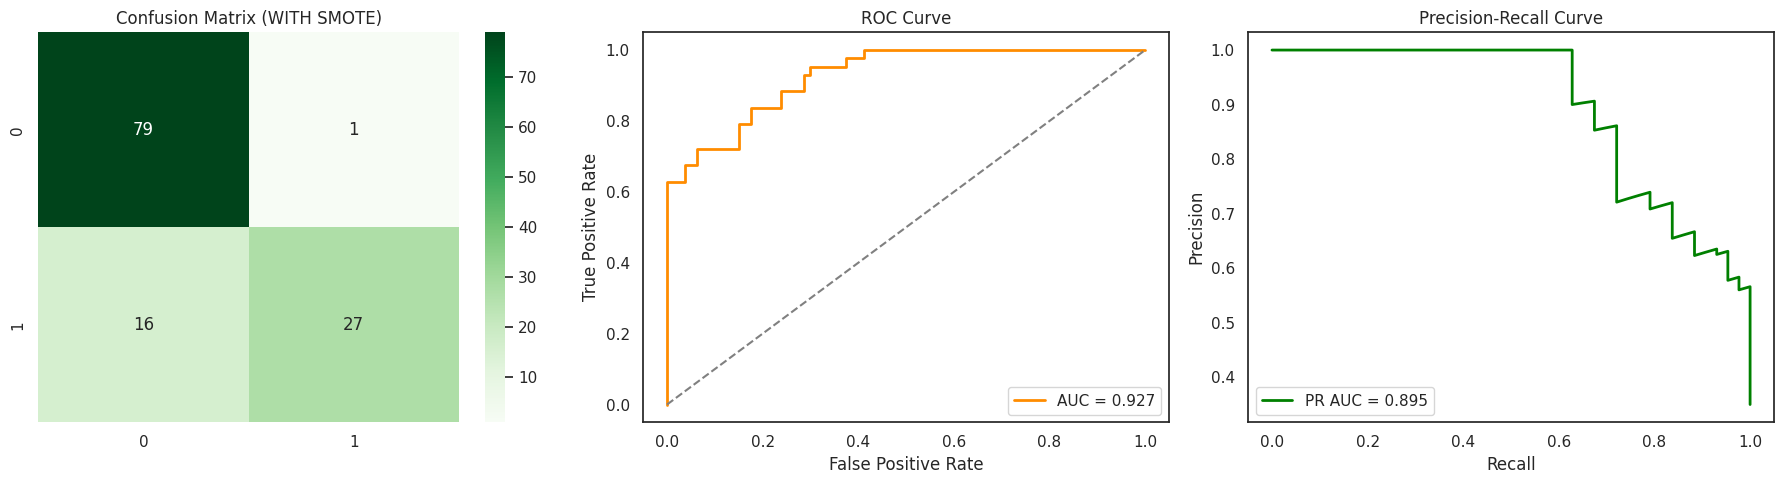



===== Repeated Stratified K-Fold CV (Logistic Regression with SMOTE) =====

===== Repeated CV Results (n_splits=5, n_repeats=10, total runs=50) =====
Accuracy: 0.8957 ± 0.0221
Precision: 0.9155 ± 0.0233
Recall: 0.8604 ± 0.0306
F1: 0.8781 ± 0.0277
ROC: 0.9500 ± 0.0183
LogLoss: 0.3062 ± 0.0273
MCC: 0.7734 ± 0.0486


,Model,Accuracy(cv),Precision(cv),Recall(cv),F1_score(cv),ROC(cv),Log_Loss(cv),mathew_corrcoef(cv),Accuracy(test),Precision(test),Recall(test),F1_score(test),ROC(test),Log_Loss(test),mathew_corrcoef(test)
0,LR (SMOTE),0.898495,0.918861,0.862415,0.880669,0.94807,0.307521,0.77882,0.861789,0.897932,0.807703,0.83171,0.927035,0.329323,0.699843


In [ ]:
from sklearn.model_selection import StratifiedKFold, RepeatedStratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, log_loss, matthews_corrcoef, confusion_matrix,
                             roc_curve, auc, precision_recall_curve)
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE

# ============================================================
# PART 1: 5-Fold Stratified Cross-Validation
# (X_train, X_test = RAW / UNSCALED data)
# ============================================================

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_acc, fold_precision, fold_recall = [], [], []
fold_f1, fold_roc, fold_logloss, fold_mcc = [], [], [], []

# X_train ke numpy array e convert kore nilam (DataFrame hole .values dorkar)
X_train_arr = X_train.values if hasattr(X_train, "values") else X_train
y_train_arr = y_train.values if hasattr(y_train, "values") else y_train

print("Fold-wise Results (Logistic Regression - WITH SMOTE):\n")

for i, (train_idx, val_idx) in enumerate(kf.split(X_train_arr, y_train_arr), 1):

    X_tr, X_val = X_train_arr[train_idx], X_train_arr[val_idx]
    y_tr, y_val = y_train_arr[train_idx], y_train_arr[val_idx]

    # ---- Fold-wise MinMax Scaling (fit ONLY on training fold) ----
    scaler = MinMaxScaler()
    X_tr = scaler.fit_transform(X_tr)
    X_val = scaler.transform(X_val)

    # Apply SMOTE only to the training fold to avoid data leakage
    smote = SMOTE(random_state=42)
    X_tr_resampled, y_tr_resampled = smote.fit_resample(X_tr, y_tr)

    model = LogisticRegression(
        C=0.1,
        solver='liblinear',
        max_iter=500,
        random_state=42
    )

    model.fit(X_tr_resampled, y_tr_resampled)

    y_val_pred = model.predict(X_val)
    y_val_prob = model.predict_proba(X_val)[:, 1]

    acc = accuracy_score(y_val, y_val_pred)
    precision = precision_score(y_val, y_val_pred, average='macro')
    recall = recall_score(y_val, y_val_pred, average='macro')
    f1 = f1_score(y_val, y_val_pred, average='macro')
    roc = roc_auc_score(y_val, y_val_prob)
    logloss_val = log_loss(y_val, y_val_prob)
    mcc_val = matthews_corrcoef(y_val, y_val_pred)
    CM_val = confusion_matrix(y_val, y_val_pred)

    fold_acc.append(acc)
    fold_precision.append(precision)
    fold_recall.append(recall)
    fold_f1.append(f1)
    fold_roc.append(roc)
    fold_logloss.append(logloss_val)
    fold_mcc.append(mcc_val)

    print(
        f"Fold {i} → "
        f"Acc:{acc:.3f} | "
        f"Prec:{precision:.3f} | "
        f"Recall:{recall:.3f} | "
        f"F1:{f1:.3f} | "
        f"ROC:{roc:.3f} | "
        f"LogLoss:{logloss_val:.3f} | "
        f"MCC:{mcc_val:.3f}"
    )

    print(f"Confusion Matrix (Fold {i}):\n{CM_val}\n")


# ============================================================
# 5-Fold CV Average Metrics
# ============================================================

print("\n===== CV Fold Average Metrics (WITH SMOTE) =====")

print(f"Accuracy: {np.mean(fold_acc):.4f} ± {np.std(fold_acc):.4f}")
print(f"Precision: {np.mean(fold_precision):.4f} ± {np.std(fold_precision):.4f}")
print(f"Recall: {np.mean(fold_recall):.4f} ± {np.std(fold_recall):.4f}")
print(f"F1: {np.mean(fold_f1):.4f} ± {np.std(fold_f1):.4f}")
print(f"ROC: {np.mean(fold_roc):.4f} ± {np.std(fold_roc):.4f}")
print(f"LogLoss: {np.mean(fold_logloss):.4f} ± {np.std(fold_logloss):.4f}")
print(f"MCC: {np.mean(fold_mcc):.4f} ± {np.std(fold_mcc):.4f}")


# ============================================================
# Train the Final Model Using the Entire Training Set + SMOTE
# (Final scaler fit on FULL training set, then applied to test set)
# ============================================================

final_scaler = MinMaxScaler()
X_train_scaled_final = final_scaler.fit_transform(X_train_arr)

X_test_arr = X_test.values if hasattr(X_test, "values") else X_test
X_test_scaled_final = final_scaler.transform(X_test_arr)   # only transform, NOT fit

smote_final = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote_final.fit_resample(
    X_train_scaled_final,
    y_train_arr
)

final_model = LogisticRegression(
    C=0.1,
    solver='liblinear',
    max_iter=500,
    random_state=42
)

final_model.fit(X_train_resampled, y_train_resampled)


# ============================================================
# CV Metrics (renamed from "train" to "CV" for clarity)
# ============================================================

acc_cv = np.mean(fold_acc)
precision_cv = np.mean(fold_precision)
recall_cv = np.mean(fold_recall)
f1_cv = np.mean(fold_f1)
roc_cv = np.mean(fold_roc)
logloss_cv = np.mean(fold_logloss)
mcc_cv = np.mean(fold_mcc)


# ============================================================
# Test Set Evaluation
# ============================================================

y_test_arr = y_test.values if hasattr(y_test, "values") else y_test

y_test_pred = final_model.predict(X_test_scaled_final)
y_test_prob = final_model.predict_proba(X_test_scaled_final)[:, 1]

acc_test = accuracy_score(y_test_arr, y_test_pred)
precision_test = precision_score(y_test_arr, y_test_pred, average='macro')
recall_test = recall_score(y_test_arr, y_test_pred, average='macro')
f1_test = f1_score(y_test_arr, y_test_pred, average='macro')
roc_test = roc_auc_score(y_test_arr, y_test_prob)
logloss_test = log_loss(y_test_arr, y_test_prob)
mcc_test = matthews_corrcoef(y_test_arr, y_test_pred)


# ============================================================
# Confusion Matrix, ROC Curve, and Precision-Recall Curve
# ============================================================

CM = confusion_matrix(y_test_arr, y_test_pred)

fpr, tpr, _ = roc_curve(y_test_arr, y_test_prob)
roc_auc = auc(fpr, tpr)

precision_vals, recall_vals, _ = precision_recall_curve(
    y_test_arr,
    y_test_prob
)

pr_auc = auc(recall_vals, precision_vals)


plt.figure(figsize=(18, 5))

# Confusion Matrix
plt.subplot(1, 3, 1)
sns.heatmap(CM, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix (WITH SMOTE)")

# ROC Curve
plt.subplot(1, 3, 2)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}", color='darkorange', lw=2)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")

# Precision-Recall Curve
plt.subplot(1, 3, 3)
plt.plot(recall_vals, precision_vals, label=f"PR AUC = {pr_auc:.3f}", color='green', lw=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend(loc="lower left")

plt.tight_layout()
plt.show()


# ============================================================
# PART 2: Repeated Stratified K-Fold Cross-Validation
# Purpose: Assess the stability and robustness of the model
# across multiple train-validation splits.
# ============================================================

N_SPLITS = 5
N_REPEATS = 10

rskf = RepeatedStratifiedKFold(
    n_splits=N_SPLITS,
    n_repeats=N_REPEATS,
    random_state=42
)

rep_acc, rep_precision, rep_recall = [], [], []
rep_f1, rep_roc, rep_logloss, rep_mcc = [], [], [], []

print(
    "\n\n===== Repeated Stratified K-Fold CV "
    "(Logistic Regression with SMOTE) =====\n"
)

for i, (train_idx, val_idx) in enumerate(
    rskf.split(X_train_arr, y_train_arr),
    1
):

    X_tr, X_val = X_train_arr[train_idx], X_train_arr[val_idx]
    y_tr, y_val = y_train_arr[train_idx], y_train_arr[val_idx]

    # ---- Fold-wise MinMax Scaling (fit ONLY on training fold) ----
    scaler_rep = MinMaxScaler()
    X_tr = scaler_rep.fit_transform(X_tr)
    X_val = scaler_rep.transform(X_val)

    # Apply SMOTE only to the training fold to avoid data leakage
    smote_rep = SMOTE(random_state=42)

    X_tr_resampled, y_tr_resampled = smote_rep.fit_resample(
        X_tr,
        y_tr
    )

    model_rep = LogisticRegression(
        C=0.1,
        solver='liblinear',
        max_iter=500,
        random_state=42
    )

    model_rep.fit(
        X_tr_resampled,
        y_tr_resampled
    )

    y_val_pred = model_rep.predict(X_val)
    y_val_prob = model_rep.predict_proba(X_val)[:, 1]

    rep_acc.append(accuracy_score(y_val, y_val_pred))
    rep_precision.append(precision_score(y_val, y_val_pred, average='macro'))
    rep_recall.append(recall_score(y_val, y_val_pred, average='macro'))
    rep_f1.append(f1_score(y_val, y_val_pred, average='macro'))
    rep_roc.append(roc_auc_score(y_val, y_val_prob))
    rep_logloss.append(log_loss(y_val, y_val_prob))
    rep_mcc.append(matthews_corrcoef(y_val, y_val_pred))


# ============================================================
# Repeated CV Mean and Standard Deviation
# ============================================================

print(
    f"===== Repeated CV Results "
    f"(n_splits={N_SPLITS}, "
    f"n_repeats={N_REPEATS}, "
    f"total runs={N_SPLITS * N_REPEATS}) ====="
)

print(f"Accuracy: {np.mean(rep_acc):.4f} ± {np.std(rep_acc):.4f}")
print(f"Precision: {np.mean(rep_precision):.4f} ± {np.std(rep_precision):.4f}")
print(f"Recall: {np.mean(rep_recall):.4f} ± {np.std(rep_recall):.4f}")
print(f"F1: {np.mean(rep_f1):.4f} ± {np.std(rep_f1):.4f}")
print(f"ROC: {np.mean(rep_roc):.4f} ± {np.std(rep_roc):.4f}")
print(f"LogLoss: {np.mean(rep_logloss):.4f} ± {np.std(rep_logloss):.4f}")
print(f"MCC: {np.mean(rep_mcc):.4f} ± {np.std(rep_mcc):.4f}")


# ============================================================
# Store Repeated CV Results for Reporting
# These values are NOT added to comp_ev.
# ============================================================

acc_repcv = np.mean(rep_acc)
acc_repcv_std = np.std(rep_acc)

f1_repcv = np.mean(rep_f1)
f1_repcv_std = np.std(rep_f1)

mcc_repcv = np.mean(rep_mcc)
mcc_repcv_std = np.std(rep_mcc)


# ============================================================
# PART 3: Add Logistic Regression Results to comp_ev
# CV metrics (5-Fold) + Test metrics only.
# Repeated CV results are NOT added to the DataFrame.
# ============================================================

r = comp_ev.shape[0]
comp_ev.loc[r] = ['LR (SMOTE)', acc_cv, precision_cv, recall_cv, f1_cv, roc_cv,
                  logloss_cv, mcc_cv, acc_test, precision_test, recall_test, f1_test, roc_test,
                  logloss_test, mcc_test]

comp_ev = comp_ev.sort_values(by='Accuracy(test)', ascending=False).reset_index(drop=True)
comp_ev

# **DT**

Fold-wise Results (Decision Tree - WITH SMOTE):

Fold 1 → Acc:0.939 | Prec:0.939 | Recall:0.927 | F1:0.933 | ROC:0.971 | LogLoss:0.492 | MCC:0.867
Confusion Matrix (Fold 1):
[[62  2]
 [ 4 31]]

Fold 2 → Acc:0.960 | Prec:0.956 | Recall:0.956 | F1:0.956 | ROC:0.965 | LogLoss:0.785 | MCC:0.912
Confusion Matrix (Fold 2):
[[62  2]
 [ 2 33]]

Fold 3 → Acc:0.949 | Prec:0.939 | Recall:0.954 | F1:0.945 | ROC:0.990 | LogLoss:0.438 | MCC:0.893
Confusion Matrix (Fold 3):
[[59  4]
 [ 1 34]]

Fold 4 → Acc:0.949 | Prec:0.938 | Recall:0.954 | F1:0.945 | ROC:0.989 | LogLoss:0.166 | MCC:0.892
Confusion Matrix (Fold 4):
[[60  4]
 [ 1 33]]

Fold 5 → Acc:0.939 | Prec:0.932 | Recall:0.932 | F1:0.932 | ROC:0.977 | LogLoss:0.471 | MCC:0.865
Confusion Matrix (Fold 5):
[[61  3]
 [ 3 31]]


===== CV Fold Average Metrics (DT WITH SMOTE) =====
Accuracy: 0.9471 ± 0.0076
Precision: 0.9409 ± 0.0079
Recall: 0.9447 ± 0.0123
F1: 0.9423 ± 0.0088
ROC: 0.9781 ± 0.0097
LogLoss: 0.4704 ± 0.1963
MCC: 0.8855 ± 0.0177


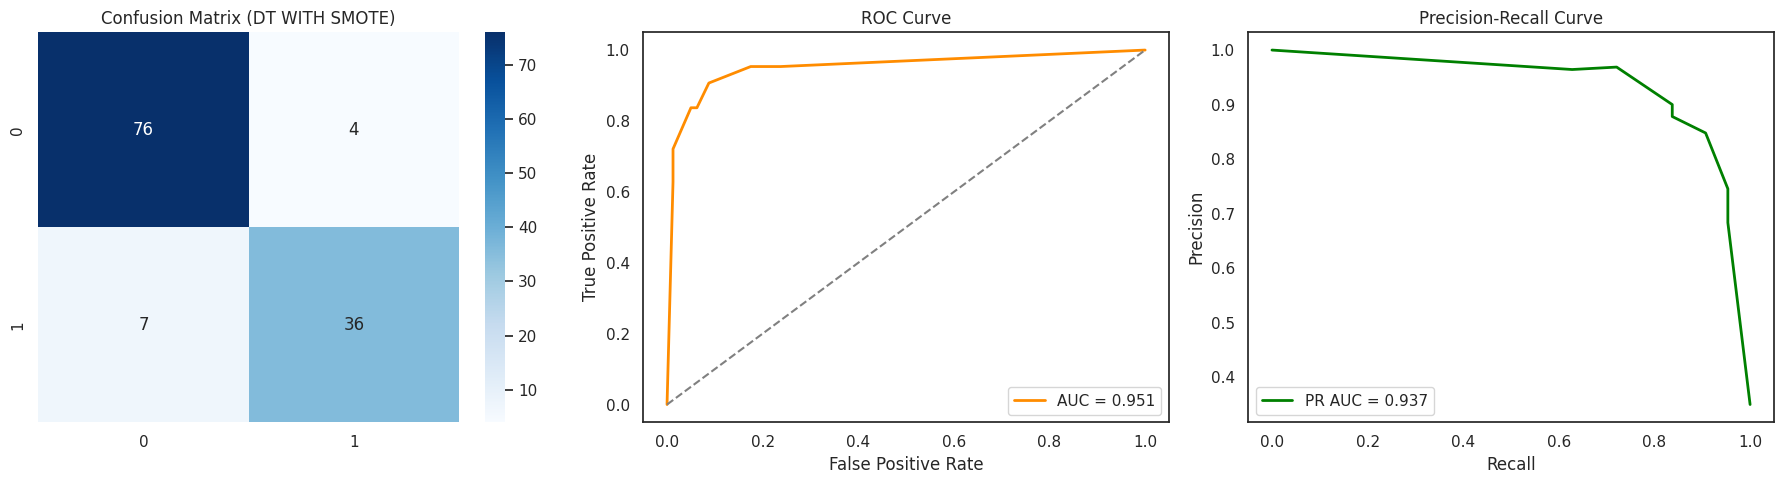


===== Decision Tree Evaluation (WITH SMOTE) =====
AUC (ROC) : 0.9512
PR-AUC    : 0.9365


===== Repeated Stratified K-Fold CV (Decision Tree with SMOTE) =====

===== Repeated CV Results (n_splits=5, n_repeats=10, total runs=50) =====
Accuracy: 0.9488 ± 0.0210
Precision: 0.9426 ± 0.0231
Recall: 0.9470 ± 0.0243
F1: 0.9442 ± 0.0231
ROC: 0.9731 ± 0.0201
LogLoss: 0.6202 ± 0.5253
MCC: 0.8895 ± 0.0460


,Model,Accuracy(cv),Precision(cv),Recall(cv),F1_score(cv),ROC(cv),Log_Loss(cv),mathew_corrcoef(cv),Accuracy(test),Precision(test),Recall(test),F1_score(test),ROC(test),Log_Loss(test),mathew_corrcoef(test)
0,DT (SMOTE),0.947145,0.940885,0.944699,0.942254,0.978119,0.470369,0.885512,0.910569,0.907831,0.893605,0.899993,0.951163,1.010819,0.801310
1,LR (SMOTE),0.898495,0.918861,0.862415,0.880669,0.948070,0.307521,0.778820,0.861789,0.897932,0.807703,0.831710,0.927035,0.329323,0.699843


In [ ]:
from imblearn.over_sampling import SMOTE                    # <-- Import SMOTE
from sklearn.model_selection import StratifiedKFold, RepeatedStratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, log_loss, matthews_corrcoef, confusion_matrix,
                             roc_curve, auc, precision_recall_curve)
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# ====== K-Fold Cross Validation WITH SMOTE + Fold-wise Scaling ======
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_acc, fold_precision, fold_recall = [], [], []
fold_f1, fold_roc, fold_logloss, fold_mcc = [], [], [], []

# Raw (unscaled) data
X_train_arr = X_train.values if hasattr(X_train, "values") else X_train
y_train_arr = y_train.values if hasattr(y_train, "values") else y_train

print("Fold-wise Results (Decision Tree - WITH SMOTE):\n")

for i, (train_idx, val_idx) in enumerate(kf.split(X_train_arr, y_train_arr), 1):
    X_tr, X_val = X_train_arr[train_idx], X_train_arr[val_idx]
    y_tr, y_val = y_train_arr[train_idx], y_train_arr[val_idx]

    # ---- Fold-wise MinMax Scaling (fit ONLY on training fold) ----
    scaler = MinMaxScaler()
    X_tr = scaler.fit_transform(X_tr)
    X_val = scaler.transform(X_val)

    # Apply SMOTE only to the training fold (no data leakage)
    smote = SMOTE(random_state=42)
    X_tr_resampled, y_tr_resampled = smote.fit_resample(X_tr, y_tr)

    # Model with pruning parameters
    model = DecisionTreeClassifier(
        max_depth=5,
        min_samples_leaf=10,
        criterion='gini',
        random_state=42
    )
    model.fit(X_tr_resampled, y_tr_resampled)                # Train on resampled fold

    # Predict on the original (unresampled) validation set
    y_val_pred = model.predict(X_val)
    y_val_prob = model.predict_proba(X_val)[:,1]

    # Metrics
    acc = accuracy_score(y_val, y_val_pred)
    precision = precision_score(y_val, y_val_pred, average='macro')
    recall = recall_score(y_val, y_val_pred, average='macro')
    f1 = f1_score(y_val, y_val_pred, average='macro')
    roc = roc_auc_score(y_val, y_val_prob)
    logloss_val = log_loss(y_val, y_val_prob)
    mcc_val = matthews_corrcoef(y_val, y_val_pred)
    CM_val = confusion_matrix(y_val, y_val_pred)

    fold_acc.append(acc)
    fold_precision.append(precision)
    fold_recall.append(recall)
    fold_f1.append(f1)
    fold_roc.append(roc)
    fold_logloss.append(logloss_val)
    fold_mcc.append(mcc_val)

    print(f"Fold {i} → Acc:{acc:.3f} | Prec:{precision:.3f} | Recall:{recall:.3f} | "
          f"F1:{f1:.3f} | ROC:{roc:.3f} | LogLoss:{logloss_val:.3f} | MCC:{mcc_val:.3f}")
    print(f"Confusion Matrix (Fold {i}):\n{CM_val}\n")

# ===== Fold-wise averages =====
print("\n===== CV Fold Average Metrics (DT WITH SMOTE) =====")
print(f"Accuracy: {np.mean(fold_acc):.4f} ± {np.std(fold_acc):.4f}")
print(f"Precision: {np.mean(fold_precision):.4f} ± {np.std(fold_precision):.4f}")
print(f"Recall: {np.mean(fold_recall):.4f} ± {np.std(fold_recall):.4f}")
print(f"F1: {np.mean(fold_f1):.4f} ± {np.std(fold_f1):.4f}")
print(f"ROC: {np.mean(fold_roc):.4f} ± {np.std(fold_roc):.4f}")
print(f"LogLoss: {np.mean(fold_logloss):.4f} ± {np.std(fold_logloss):.4f}")
print(f"MCC: {np.mean(fold_mcc):.4f} ± {np.std(fold_mcc):.4f}")

# ===== Train final model (WITH SMOTE) =====
# Final scaler: pura training set diye fit, test set e শুধু transform
final_scaler = MinMaxScaler()
X_train_scaled_final = final_scaler.fit_transform(X_train_arr)

X_test_arr = X_test.values if hasattr(X_test, "values") else X_test
X_test_scaled_final = final_scaler.transform(X_test_arr)

smote_final = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote_final.fit_resample(X_train_scaled_final, y_train_arr)

final_model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=10,
    criterion='gini',
    random_state=42
)
final_model.fit(X_train_resampled, y_train_resampled)

# ===== CV metrics (renamed train -> cv) =====
acc_cv       = np.mean(fold_acc)
precision_cv = np.mean(fold_precision)
recall_cv    = np.mean(fold_recall)
f1_cv        = np.mean(fold_f1)
roc_cv       = np.mean(fold_roc)
logloss_cv   = np.mean(fold_logloss)
mcc_cv       = np.mean(fold_mcc)

# ===== Test metrics =====
y_test_arr = y_test.values if hasattr(y_test, "values") else y_test

y_test_pred = final_model.predict(X_test_scaled_final)
y_test_prob = final_model.predict_proba(X_test_scaled_final)[:,1]

acc_test = accuracy_score(y_test_arr, y_test_pred)
precision_test = precision_score(y_test_arr, y_test_pred, average='macro')
recall_test = recall_score(y_test_arr, y_test_pred, average='macro')
f1_test = f1_score(y_test_arr, y_test_pred, average='macro')
roc_test = roc_auc_score(y_test_arr, y_test_prob)
logloss_test = log_loss(y_test_arr, y_test_prob)
mcc_test = matthews_corrcoef(y_test_arr, y_test_pred)

# ===== Curves =====
CM = confusion_matrix(y_test_arr, y_test_pred)
fpr, tpr, _ = roc_curve(y_test_arr, y_test_prob)
roc_auc = auc(fpr, tpr)
precision_vals, recall_vals, _ = precision_recall_curve(y_test_arr, y_test_prob)
pr_auc = auc(recall_vals, precision_vals)

plt.figure(figsize=(18,5))

plt.subplot(1,3,1)
sns.heatmap(CM, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (DT WITH SMOTE)")

plt.subplot(1,3,2)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}", color='darkorange', lw=2)
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")

plt.subplot(1,3,3)
plt.plot(recall_vals, precision_vals, label=f"PR AUC = {pr_auc:.3f}", color='green', lw=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend(loc="lower left")

plt.tight_layout()
plt.show()

print("\n===== Decision Tree Evaluation (WITH SMOTE) =====")
print(f"AUC (ROC) : {roc_auc:.4f}")
print(f"PR-AUC    : {pr_auc:.4f}")


# ============================================================
# Repeated Stratified K-Fold Cross-Validation (Fold-wise Scaling)
# ============================================================

N_SPLITS = 5
N_REPEATS = 10

rskf = RepeatedStratifiedKFold(
    n_splits=N_SPLITS,
    n_repeats=N_REPEATS,
    random_state=42
)

rep_acc, rep_precision, rep_recall = [], [], []
rep_f1, rep_roc, rep_logloss, rep_mcc = [], [], [], []

print("\n\n===== Repeated Stratified K-Fold CV "
      "(Decision Tree with SMOTE) =====\n")

for i, (train_idx, val_idx) in enumerate(
    rskf.split(X_train_arr, y_train_arr), 1
):

    X_tr, X_val = X_train_arr[train_idx], X_train_arr[val_idx]
    y_tr, y_val = y_train_arr[train_idx], y_train_arr[val_idx]

    # ---- Fold-wise MinMax Scaling (fit ONLY on training fold) ----
    scaler_rep = MinMaxScaler()
    X_tr = scaler_rep.fit_transform(X_tr)
    X_val = scaler_rep.transform(X_val)

    # Apply SMOTE only to the training fold to avoid data leakage
    smote_rep = SMOTE(random_state=42)

    X_tr_resampled, y_tr_resampled = smote_rep.fit_resample(
        X_tr,
        y_tr
    )

    model_rep = DecisionTreeClassifier(
        max_depth=5,
        min_samples_leaf=10,
        criterion='gini',
        random_state=42
    )

    model_rep.fit(
        X_tr_resampled,
        y_tr_resampled
    )

    y_val_pred = model_rep.predict(X_val)
    y_val_prob = model_rep.predict_proba(X_val)[:,1]

    rep_acc.append(accuracy_score(y_val, y_val_pred))
    rep_precision.append(precision_score(y_val, y_val_pred, average='macro'))
    rep_recall.append(recall_score(y_val, y_val_pred, average='macro'))
    rep_f1.append(f1_score(y_val, y_val_pred, average='macro'))
    rep_roc.append(roc_auc_score(y_val, y_val_prob))
    rep_logloss.append(log_loss(y_val, y_val_prob))
    rep_mcc.append(matthews_corrcoef(y_val, y_val_pred))


# ============================================================
# Repeated CV Mean and Standard Deviation
# ============================================================

print(
    f"===== Repeated CV Results "
    f"(n_splits={N_SPLITS}, "
    f"n_repeats={N_REPEATS}, "
    f"total runs={N_SPLITS * N_REPEATS}) ====="
)

print(f"Accuracy: {np.mean(rep_acc):.4f} ± {np.std(rep_acc):.4f}")
print(f"Precision: {np.mean(rep_precision):.4f} ± {np.std(rep_precision):.4f}")
print(f"Recall: {np.mean(rep_recall):.4f} ± {np.std(rep_recall):.4f}")
print(f"F1: {np.mean(rep_f1):.4f} ± {np.std(rep_f1):.4f}")
print(f"ROC: {np.mean(rep_roc):.4f} ± {np.std(rep_roc):.4f}")
print(f"LogLoss: {np.mean(rep_logloss):.4f} ± {np.std(rep_logloss):.4f}")
print(f"MCC: {np.mean(rep_mcc):.4f} ± {np.std(rep_mcc):.4f}")


# ============================================================
# Store Repeated CV Results for Reporting
# These values are not added to comp_ev.
# ============================================================

acc_repcv = np.mean(rep_acc)
acc_repcv_std = np.std(rep_acc)

f1_repcv = np.mean(rep_f1)
f1_repcv_std = np.std(rep_f1)

mcc_repcv = np.mean(rep_mcc)
mcc_repcv_std = np.std(rep_mcc)


# ===== Append metrics to comparison DataFrame =====
r = comp_ev.shape[0]
comp_ev.loc[r] = ['DT (SMOTE)', acc_cv, precision_cv, recall_cv, f1_cv, roc_cv,
                  logloss_cv, mcc_cv, acc_test, precision_test, recall_test, f1_test, roc_test,
                  logloss_test, mcc_test]

comp_ev = comp_ev.sort_values(by='Accuracy(test)', ascending=False).reset_index(drop=True)
comp_ev

# **MLP**

Fold-wise Results (MLP - WITH SMOTE):

Fold 1 → Acc:0.818 | Prec:0.800 | Recall:0.808 | F1:0.804 | ROC:0.900 | LogLoss:0.442 | MCC:0.608
Confusion Matrix (Fold 1):
[[54 10]
 [ 8 27]]

Fold 2 → Acc:0.909 | Prec:0.896 | Recall:0.910 | F1:0.902 | ROC:0.971 | LogLoss:0.381 | MCC:0.807
Confusion Matrix (Fold 2):
[[58  6]
 [ 3 32]]

Fold 3 → Acc:0.724 | Prec:0.759 | Recall:0.773 | F1:0.724 | ROC:0.929 | LogLoss:0.523 | MCC:0.532
Confusion Matrix (Fold 3):
[[38 25]
 [ 2 33]]

Fold 4 → Acc:0.796 | Prec:0.799 | Recall:0.830 | F1:0.792 | ROC:0.974 | LogLoss:0.469 | MCC:0.628
Confusion Matrix (Fold 4):
[[46 18]
 [ 2 32]]

Fold 5 → Acc:0.837 | Prec:0.824 | Recall:0.854 | F1:0.830 | ROC:0.960 | LogLoss:0.481 | MCC:0.678
Confusion Matrix (Fold 5):
[[51 13]
 [ 3 31]]


===== CV Fold Average Metrics (MLP WITH SMOTE) =====
Accuracy: 0.8169 ± 0.0598
Precision: 0.8160 ± 0.0453
Recall: 0.8350 ± 0.0462
F1: 0.8102 ± 0.0578
ROC: 0.9468 ± 0.0282
LogLoss: 0.4592 ± 0.0469
MCC: 0.6507 ± 0.0910


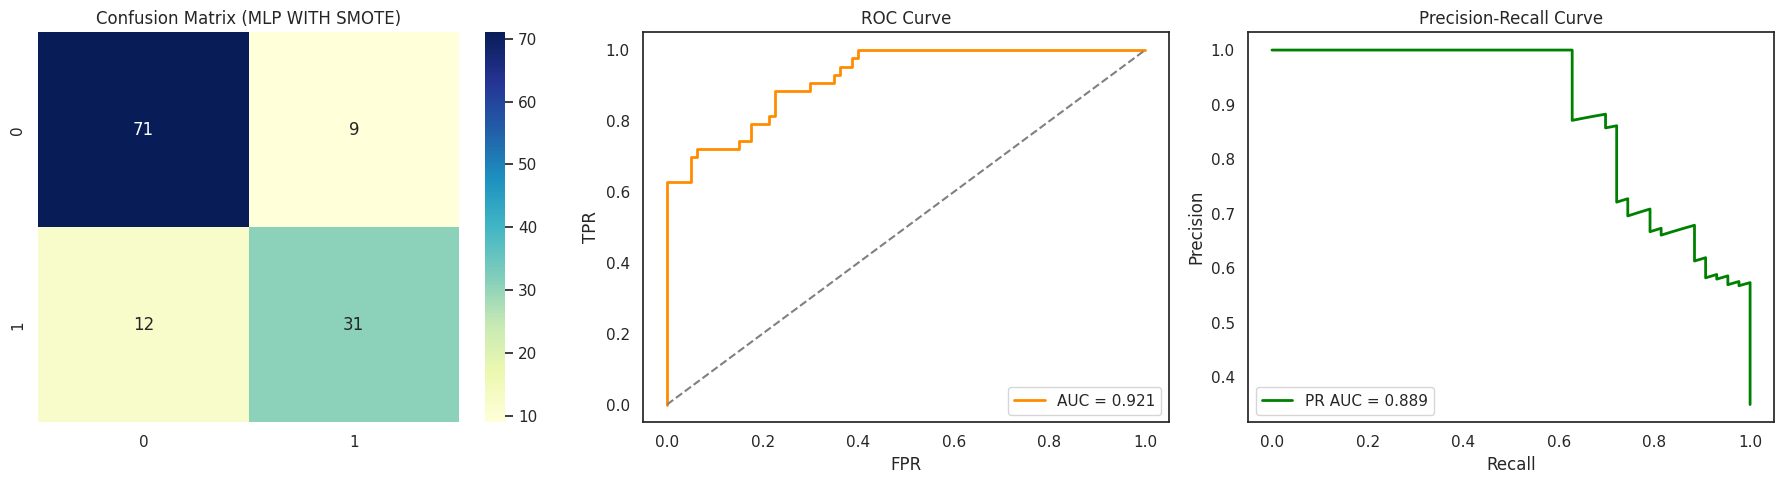


===== MLP Evaluation (WITH SMOTE) =====
AUC (ROC) : 0.9209
PR-AUC    : 0.8889


===== Repeated Stratified K-Fold CV (MLP with SMOTE) =====

===== Repeated CV Results (n_splits=5, n_repeats=10, total runs=50) =====
Accuracy: 0.8528 ± 0.0454
Precision: 0.8447 ± 0.0383
Recall: 0.8594 ± 0.0351
F1: 0.8445 ± 0.0438
ROC: 0.9502 ± 0.0186
LogLoss: 0.4404 ± 0.0490
MCC: 0.7038 ± 0.0719


,Model,Accuracy(cv),Precision(cv),Recall(cv),F1_score(cv),ROC(cv),Log_Loss(cv),mathew_corrcoef(cv),Accuracy(test),Precision(test),Recall(test),F1_score(test),ROC(test),Log_Loss(test),mathew_corrcoef(test)
0,DT (SMOTE),0.947145,0.940885,0.944699,0.942254,0.978119,0.470369,0.885512,0.910569,0.907831,0.893605,0.899993,0.951163,1.010819,0.801310
1,LR (SMOTE),0.898495,0.918861,0.862415,0.880669,0.948070,0.307521,0.778820,0.861789,0.897932,0.807703,0.831710,0.927035,0.329323,0.699843
2,MLP (SMOTE),0.816883,0.815991,0.835031,0.810201,0.946814,0.459181,0.650674,0.829268,0.815211,0.804215,0.809077,0.920930,0.451966,0.619328


In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold, RepeatedStratifiedKFold
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, log_loss, matthews_corrcoef, confusion_matrix,
                             roc_curve, auc, precision_recall_curve)
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# ====== K-Fold Cross Validation WITH SMOTE + Fold-wise Scaling ======
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_acc, fold_precision, fold_recall = [], [], []
fold_f1, fold_roc, fold_logloss, fold_mcc = [], [], [], []

# Raw (unscaled) data
X_train_arr = X_train.values if hasattr(X_train, "values") else X_train
y_train_arr = y_train.values if hasattr(y_train, "values") else y_train

print("Fold-wise Results (MLP - WITH SMOTE):\n")

for i, (train_idx, val_idx) in enumerate(kf.split(X_train_arr, y_train_arr), 1):
    X_tr, X_val = X_train_arr[train_idx], X_train_arr[val_idx]
    y_tr, y_val = y_train_arr[train_idx], y_train_arr[val_idx]

    # ---- Fold-wise MinMax Scaling (fit ONLY on training fold) ----
    scaler = MinMaxScaler()
    X_tr = scaler.fit_transform(X_tr)
    X_val = scaler.transform(X_val)

    # Apply SMOTE only to the training fold to avoid data leakage
    smote = SMOTE(random_state=42)
    X_tr_resampled, y_tr_resampled = smote.fit_resample(X_tr, y_tr)

    # Model with same hyperparameters
    model = MLPClassifier(
        hidden_layer_sizes=(50,),
        max_iter=300,
        alpha=0.1,
        solver='adam',
        early_stopping=True,
        validation_fraction=0.1,
        random_state=42
    )
    model.fit(X_tr_resampled, y_tr_resampled)

    # Predict on the original validation set
    y_val_pred = model.predict(X_val)
    y_val_prob = model.predict_proba(X_val)[:,1]

    # Metrics
    acc = accuracy_score(y_val, y_val_pred)
    precision = precision_score(y_val, y_val_pred, average='macro')
    recall = recall_score(y_val, y_val_pred, average='macro')
    f1 = f1_score(y_val, y_val_pred, average='macro')
    roc = roc_auc_score(y_val, y_val_prob)
    logloss_val = log_loss(y_val, y_val_prob)
    mcc_val = matthews_corrcoef(y_val, y_val_pred)
    CM_val = confusion_matrix(y_val, y_val_pred)

    fold_acc.append(acc)
    fold_precision.append(precision)
    fold_recall.append(recall)
    fold_f1.append(f1)
    fold_roc.append(roc)
    fold_logloss.append(logloss_val)
    fold_mcc.append(mcc_val)

    print(f"Fold {i} → Acc:{acc:.3f} | Prec:{precision:.3f} | Recall:{recall:.3f} | "
          f"F1:{f1:.3f} | ROC:{roc:.3f} | LogLoss:{logloss_val:.3f} | MCC:{mcc_val:.3f}")
    print(f"Confusion Matrix (Fold {i}):\n{CM_val}\n")

# ===== Fold-wise averages =====
print("\n===== CV Fold Average Metrics (MLP WITH SMOTE) =====")
print(f"Accuracy: {np.mean(fold_acc):.4f} ± {np.std(fold_acc):.4f}")
print(f"Precision: {np.mean(fold_precision):.4f} ± {np.std(fold_precision):.4f}")
print(f"Recall: {np.mean(fold_recall):.4f} ± {np.std(fold_recall):.4f}")
print(f"F1: {np.mean(fold_f1):.4f} ± {np.std(fold_f1):.4f}")
print(f"ROC: {np.mean(fold_roc):.4f} ± {np.std(fold_roc):.4f}")
print(f"LogLoss: {np.mean(fold_logloss):.4f} ± {np.std(fold_logloss):.4f}")
print(f"MCC: {np.mean(fold_mcc):.4f} ± {np.std(fold_mcc):.4f}")

# ===== Train final model (WITH SMOTE) =====
# Final scaler: পুরো training set দিয়ে fit, test set এ শুধু transform
final_scaler = MinMaxScaler()
X_train_scaled_final = final_scaler.fit_transform(X_train_arr)

X_test_arr = X_test.values if hasattr(X_test, "values") else X_test
X_test_scaled_final = final_scaler.transform(X_test_arr)

smote_final = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote_final.fit_resample(X_train_scaled_final, y_train_arr)

final_model = MLPClassifier(
    hidden_layer_sizes=(50,),
    max_iter=300,
    alpha=0.1,
    solver='adam',
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42
)
final_model.fit(X_train_resampled, y_train_resampled)

# ===== CV metrics (renamed train -> cv) =====
acc_cv       = np.mean(fold_acc)
precision_cv = np.mean(fold_precision)
recall_cv    = np.mean(fold_recall)
f1_cv        = np.mean(fold_f1)
roc_cv       = np.mean(fold_roc)
logloss_cv   = np.mean(fold_logloss)
mcc_cv       = np.mean(fold_mcc)

# ===== Test metrics =====
y_test_arr = y_test.values if hasattr(y_test, "values") else y_test

y_test_pred = final_model.predict(X_test_scaled_final)
y_test_prob = final_model.predict_proba(X_test_scaled_final)[:,1]

acc_test = accuracy_score(y_test_arr, y_test_pred)
precision_test = precision_score(y_test_arr, y_test_pred, average='macro')
recall_test = recall_score(y_test_arr, y_test_pred, average='macro')
f1_test = f1_score(y_test_arr, y_test_pred, average='macro')
roc_test = roc_auc_score(y_test_arr, y_test_prob)
logloss_test = log_loss(y_test_arr, y_test_prob)
mcc_test = matthews_corrcoef(y_test_arr, y_test_pred)

# ===== Curves =====
CM = confusion_matrix(y_test_arr, y_test_pred)
fpr, tpr, _ = roc_curve(y_test_arr, y_test_prob)
roc_auc = auc(fpr, tpr)
precision_vals, recall_vals, _ = precision_recall_curve(y_test_arr, y_test_prob)
pr_auc = auc(recall_vals, precision_vals)

plt.figure(figsize=(18,5))

plt.subplot(1,3,1)
sns.heatmap(CM, annot=True, fmt='d', cmap='YlGnBu')
plt.title("Confusion Matrix (MLP WITH SMOTE)")

plt.subplot(1,3,2)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}", color='darkorange', lw=2)
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.legend(loc="lower right")

plt.subplot(1,3,3)
plt.plot(recall_vals, precision_vals, label=f"PR AUC = {pr_auc:.3f}", color='green', lw=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend(loc="lower left")

plt.tight_layout()
plt.show()

print("\n===== MLP Evaluation (WITH SMOTE) =====")
print(f"AUC (ROC) : {roc_auc:.4f}")
print(f"PR-AUC    : {pr_auc:.4f}")


# ============================================================
# Repeated Stratified K-Fold Cross-Validation (Fold-wise Scaling)
# ============================================================

N_SPLITS = 5
N_REPEATS = 10

rskf = RepeatedStratifiedKFold(
    n_splits=N_SPLITS,
    n_repeats=N_REPEATS,
    random_state=42
)

rep_acc, rep_precision, rep_recall = [], [], []
rep_f1, rep_roc, rep_logloss, rep_mcc = [], [], [], []

print("\n\n===== Repeated Stratified K-Fold CV "
      "(MLP with SMOTE) =====\n")

for i, (train_idx, val_idx) in enumerate(
    rskf.split(X_train_arr, y_train_arr), 1
):

    X_tr, X_val = X_train_arr[train_idx], X_train_arr[val_idx]
    y_tr, y_val = y_train_arr[train_idx], y_train_arr[val_idx]

    # ---- Fold-wise MinMax Scaling (fit ONLY on training fold) ----
    scaler_rep = MinMaxScaler()
    X_tr = scaler_rep.fit_transform(X_tr)
    X_val = scaler_rep.transform(X_val)

    # Apply SMOTE only to the training fold to avoid data leakage
    smote_rep = SMOTE(random_state=42)

    X_tr_resampled, y_tr_resampled = smote_rep.fit_resample(
        X_tr,
        y_tr
    )

    model_rep = MLPClassifier(
        hidden_layer_sizes=(50,),
        max_iter=300,
        alpha=0.1,
        solver='adam',
        early_stopping=True,
        validation_fraction=0.1,
        random_state=42
    )

    model_rep.fit(
        X_tr_resampled,
        y_tr_resampled
    )

    y_val_pred = model_rep.predict(X_val)
    y_val_prob = model_rep.predict_proba(X_val)[:,1]

    rep_acc.append(accuracy_score(y_val, y_val_pred))
    rep_precision.append(precision_score(y_val, y_val_pred, average='macro'))
    rep_recall.append(recall_score(y_val, y_val_pred, average='macro'))
    rep_f1.append(f1_score(y_val, y_val_pred, average='macro'))
    rep_roc.append(roc_auc_score(y_val, y_val_prob))
    rep_logloss.append(log_loss(y_val, y_val_prob))
    rep_mcc.append(matthews_corrcoef(y_val, y_val_pred))


# ============================================================
# Repeated CV Mean and Standard Deviation
# ============================================================

print(
    f"===== Repeated CV Results "
    f"(n_splits={N_SPLITS}, "
    f"n_repeats={N_REPEATS}, "
    f"total runs={N_SPLITS * N_REPEATS}) ====="
)

print(f"Accuracy: {np.mean(rep_acc):.4f} ± {np.std(rep_acc):.4f}")
print(f"Precision: {np.mean(rep_precision):.4f} ± {np.std(rep_precision):.4f}")
print(f"Recall: {np.mean(rep_recall):.4f} ± {np.std(rep_recall):.4f}")
print(f"F1: {np.mean(rep_f1):.4f} ± {np.std(rep_f1):.4f}")
print(f"ROC: {np.mean(rep_roc):.4f} ± {np.std(rep_roc):.4f}")
print(f"LogLoss: {np.mean(rep_logloss):.4f} ± {np.std(rep_logloss):.4f}")
print(f"MCC: {np.mean(rep_mcc):.4f} ± {np.std(rep_mcc):.4f}")


# ============================================================
# Store Repeated CV Results for Reporting
# These values are not added to comp_ev.
# ============================================================

acc_repcv = np.mean(rep_acc)
acc_repcv_std = np.std(rep_acc)

f1_repcv = np.mean(rep_f1)
f1_repcv_std = np.std(rep_f1)

mcc_repcv = np.mean(rep_mcc)
mcc_repcv_std = np.std(rep_mcc)


# ============================================================
# Append metrics to comparison DataFrame
# Only the original CV/test metrics are added.
# ============================================================

r = comp_ev.shape[0]
comp_ev.loc[r] = ['MLP (SMOTE)', acc_cv, precision_cv, recall_cv, f1_cv, roc_cv,
                  logloss_cv, mcc_cv, acc_test, precision_test, recall_test, f1_test, roc_test,
                  logloss_test, mcc_test]

comp_ev = comp_ev.sort_values(by='Accuracy(test)', ascending=False).reset_index(drop=True)
comp_ev

# **RF**

Fold-wise Results (Random Forest - WITH SMOTE):

Fold 1 → Acc:0.949 | Prec:0.964 | Recall:0.929 | F1:0.943 | ROC:0.985 | LogLoss:0.160 | MCC:0.892
Confusion Matrix (Fold 1):
[[64  0]
 [ 5 30]]

Fold 2 → Acc:0.960 | Prec:0.956 | Recall:0.956 | F1:0.956 | ROC:0.991 | LogLoss:0.120 | MCC:0.912
Confusion Matrix (Fold 2):
[[62  2]
 [ 2 33]]

Fold 3 → Acc:0.949 | Prec:0.942 | Recall:0.948 | F1:0.945 | ROC:0.994 | LogLoss:0.135 | MCC:0.890
Confusion Matrix (Fold 3):
[[60  3]
 [ 2 33]]

Fold 4 → Acc:0.949 | Prec:0.936 | Recall:0.961 | F1:0.945 | ROC:0.997 | LogLoss:0.116 | MCC:0.896
Confusion Matrix (Fold 4):
[[59  5]
 [ 0 34]]

Fold 5 → Acc:0.969 | Prec:0.978 | Recall:0.956 | F1:0.965 | ROC:0.999 | LogLoss:0.087 | MCC:0.933
Confusion Matrix (Fold 5):
[[64  0]
 [ 3 31]]


===== CV Fold Average Metrics (RF WITH SMOTE) =====
Accuracy: 0.9553 ± 0.0081
Precision: 0.9551 ± 0.0149
Recall: 0.9498 ± 0.0114
F1: 0.9508 ± 0.0086
ROC: 0.9932 ± 0.0048
LogLoss: 0.1238 ± 0.0238
MCC: 0.9046 ± 0.0163


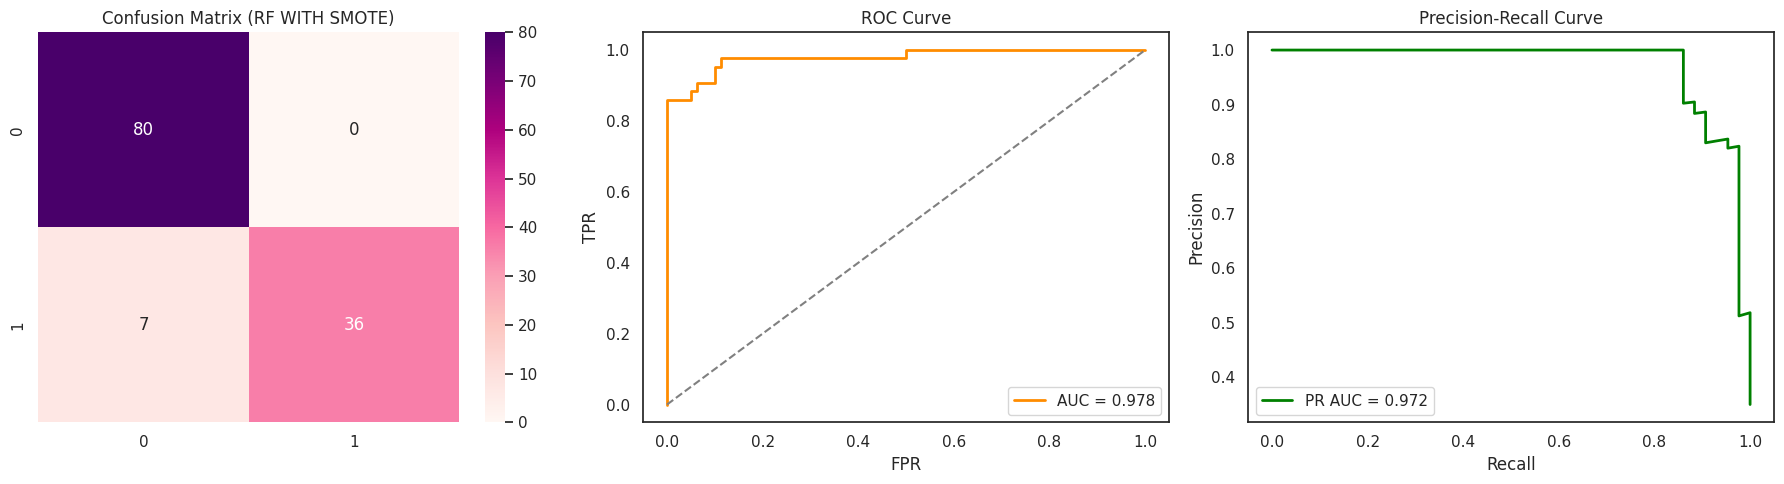


===== Random Forest Evaluation (WITH SMOTE) =====
AUC (ROC) : 0.9785
PR-AUC    : 0.9719


===== Repeated Stratified K-Fold CV (Random Forest) =====

===== Repeated CV Results (n_splits=5, n_repeats=10, total runs=50) =====
Accuracy: 0.9565 ± 0.0191
Precision: 0.9530 ± 0.0228
Recall: 0.9535 ± 0.0198
F1: 0.9524 ± 0.0206
ROC: 0.9933 ± 0.0055
LogLoss: 0.1200 ± 0.0254
MCC: 0.9064 ± 0.0404


,Model,Accuracy(cv),Precision(cv),Recall(cv),F1_score(cv),ROC(cv),Log_Loss(cv),mathew_corrcoef(cv),Accuracy(test),Precision(test),Recall(test),F1_score(test),ROC(test),Log_Loss(test),mathew_corrcoef(test)
0,RF (SMOTE),0.955288,0.955057,0.949763,0.950847,0.993171,0.123824,0.904557,0.943089,0.959770,0.918605,0.934738,0.978488,0.165459,0.877410
1,DT (SMOTE),0.947145,0.940885,0.944699,0.942254,0.978119,0.470369,0.885512,0.910569,0.907831,0.893605,0.899993,0.951163,1.010819,0.801310
2,LR (SMOTE),0.898495,0.918861,0.862415,0.880669,0.948070,0.307521,0.778820,0.861789,0.897932,0.807703,0.831710,0.927035,0.329323,0.699843
3,MLP (SMOTE),0.816883,0.815991,0.835031,0.810201,0.946814,0.459181,0.650674,0.829268,0.815211,0.804215,0.809077,0.920930,0.451966,0.619328


In [ ]:
from imblearn.over_sampling import SMOTE                      # <-- Import SMOTE
from sklearn.model_selection import StratifiedKFold, RepeatedStratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, log_loss, matthews_corrcoef, confusion_matrix,
                             roc_curve, auc, precision_recall_curve)
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# ====== K-Fold Cross Validation WITH SMOTE + Fold-wise Scaling ======
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_acc, fold_precision, fold_recall = [], [], []
fold_f1, fold_roc, fold_logloss, fold_mcc = [], [], [], []

# Raw (unscaled) data
X_train_arr = X_train.values if hasattr(X_train, "values") else X_train
y_train_arr = y_train.values if hasattr(y_train, "values") else y_train

print("Fold-wise Results (Random Forest - WITH SMOTE):\n")

for i, (train_idx, val_idx) in enumerate(kf.split(X_train_arr, y_train_arr), 1):
    X_tr, X_val = X_train_arr[train_idx], X_train_arr[val_idx]
    y_tr, y_val = y_train_arr[train_idx], y_train_arr[val_idx]

    # ---- Fold-wise MinMax Scaling (fit ONLY on training fold) ----
    scaler = MinMaxScaler()
    X_tr = scaler.fit_transform(X_tr)
    X_val = scaler.transform(X_val)

    # Apply SMOTE only to the training fold (no data leakage)
    smote = SMOTE(random_state=42)
    X_tr_resampled, y_tr_resampled = smote.fit_resample(X_tr, y_tr)

    # Model: same hyperparameters as without SMOTE
    model = RandomForestClassifier(
        n_estimators=100,
        max_depth=6,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_tr_resampled, y_tr_resampled)                 # Train on resampled fold

    # Predict on the original validation set
    y_val_pred = model.predict(X_val)
    y_val_prob = model.predict_proba(X_val)[:,1]

    # Metrics
    acc = accuracy_score(y_val, y_val_pred)
    precision = precision_score(y_val, y_val_pred, average='macro')
    recall = recall_score(y_val, y_val_pred, average='macro')
    f1 = f1_score(y_val, y_val_pred, average='macro')
    roc = roc_auc_score(y_val, y_val_prob)
    logloss_val = log_loss(y_val, y_val_prob)
    mcc_val = matthews_corrcoef(y_val, y_val_pred)
    CM_val = confusion_matrix(y_val, y_val_pred)

    fold_acc.append(acc)
    fold_precision.append(precision)
    fold_recall.append(recall)
    fold_f1.append(f1)
    fold_roc.append(roc)
    fold_logloss.append(logloss_val)
    fold_mcc.append(mcc_val)

    print(f"Fold {i} → Acc:{acc:.3f} | Prec:{precision:.3f} | Recall:{recall:.3f} | "
          f"F1:{f1:.3f} | ROC:{roc:.3f} | LogLoss:{logloss_val:.3f} | MCC:{mcc_val:.3f}")
    print(f"Confusion Matrix (Fold {i}):\n{CM_val}\n")

# ===== Fold-wise averages =====
print("\n===== CV Fold Average Metrics (RF WITH SMOTE) =====")
print(f"Accuracy: {np.mean(fold_acc):.4f} ± {np.std(fold_acc):.4f}")
print(f"Precision: {np.mean(fold_precision):.4f} ± {np.std(fold_precision):.4f}")
print(f"Recall: {np.mean(fold_recall):.4f} ± {np.std(fold_recall):.4f}")
print(f"F1: {np.mean(fold_f1):.4f} ± {np.std(fold_f1):.4f}")
print(f"ROC: {np.mean(fold_roc):.4f} ± {np.std(fold_roc):.4f}")
print(f"LogLoss: {np.mean(fold_logloss):.4f} ± {np.std(fold_logloss):.4f}")
print(f"MCC: {np.mean(fold_mcc):.4f} ± {np.std(fold_mcc):.4f}")

# ===== Train final model (WITH SMOTE) =====
# Final scaler: পুরো training set দিয়ে fit, test set এ শুধু transform
final_scaler = MinMaxScaler()
X_train_scaled_final = final_scaler.fit_transform(X_train_arr)

X_test_arr = X_test.values if hasattr(X_test, "values") else X_test
X_test_scaled_final = final_scaler.transform(X_test_arr)

smote_final = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote_final.fit_resample(X_train_scaled_final, y_train_arr)

final_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=6,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)
final_model.fit(X_train_resampled, y_train_resampled)

# ===== CV metrics (renamed train -> cv) =====
acc_cv       = np.mean(fold_acc)
precision_cv = np.mean(fold_precision)
recall_cv    = np.mean(fold_recall)
f1_cv        = np.mean(fold_f1)
roc_cv       = np.mean(fold_roc)
logloss_cv   = np.mean(fold_logloss)
mcc_cv       = np.mean(fold_mcc)

# ===== Test metrics =====
y_test_arr = y_test.values if hasattr(y_test, "values") else y_test

y_test_pred = final_model.predict(X_test_scaled_final)
y_test_prob = final_model.predict_proba(X_test_scaled_final)[:,1]

acc_test = accuracy_score(y_test_arr, y_test_pred)
precision_test = precision_score(y_test_arr, y_test_pred, average='macro')
recall_test = recall_score(y_test_arr, y_test_pred, average='macro')
f1_test = f1_score(y_test_arr, y_test_pred, average='macro')
roc_test = roc_auc_score(y_test_arr, y_test_prob)
logloss_test = log_loss(y_test_arr, y_test_prob)
mcc_test = matthews_corrcoef(y_test_arr, y_test_pred)

# ===== Curves =====
CM = confusion_matrix(y_test_arr, y_test_pred)
fpr, tpr, _ = roc_curve(y_test_arr, y_test_prob)
roc_auc = auc(fpr, tpr)
precision_vals, recall_vals, _ = precision_recall_curve(y_test_arr, y_test_prob)
pr_auc = auc(recall_vals, precision_vals)

plt.figure(figsize=(18,5))

plt.subplot(1,3,1)
sns.heatmap(CM, annot=True, fmt='d', cmap='RdPu')
plt.title("Confusion Matrix (RF WITH SMOTE)")

plt.subplot(1,3,2)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}", color='darkorange', lw=2)
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.legend(loc="lower right")

plt.subplot(1,3,3)
plt.plot(recall_vals, precision_vals, label=f"PR AUC = {pr_auc:.3f}", color='green', lw=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend(loc="lower left")

plt.tight_layout()
plt.show()

print("\n===== Random Forest Evaluation (WITH SMOTE) =====")
print(f"AUC (ROC) : {roc_auc:.4f}")
print(f"PR-AUC    : {pr_auc:.4f}")


# ============================================================
# PART 2: Repeated Stratified K-Fold CV (Fold-wise Scaling)
# ============================================================

N_SPLITS = 5
N_REPEATS = 10   # Total runs = 5 x 10 = 50

rskf = RepeatedStratifiedKFold(
    n_splits=N_SPLITS,
    n_repeats=N_REPEATS,
    random_state=42
)

rep_acc, rep_precision, rep_recall = [], [], []
rep_f1, rep_roc, rep_logloss, rep_mcc = [], [], [], []

print("\n\n===== Repeated Stratified K-Fold CV (Random Forest) =====\n")

for i, (train_idx, val_idx) in enumerate(rskf.split(X_train_arr, y_train_arr), 1):
    X_tr, X_val = X_train_arr[train_idx], X_train_arr[val_idx]
    y_tr, y_val = y_train_arr[train_idx], y_train_arr[val_idx]

    # ---- Fold-wise MinMax Scaling (fit ONLY on training fold) ----
    scaler_rep = MinMaxScaler()
    X_tr = scaler_rep.fit_transform(X_tr)
    X_val = scaler_rep.transform(X_val)

    # Apply SMOTE only to the training fold to avoid data leakage
    smote_rep = SMOTE(random_state=42)
    X_tr_resampled, y_tr_resampled = smote_rep.fit_resample(X_tr, y_tr)

    model_rep = RandomForestClassifier(
        n_estimators=100,
        max_depth=6,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    )

    model_rep.fit(X_tr_resampled, y_tr_resampled)

    y_val_pred = model_rep.predict(X_val)
    y_val_prob = model_rep.predict_proba(X_val)[:,1]

    rep_acc.append(accuracy_score(y_val, y_val_pred))
    rep_precision.append(precision_score(y_val, y_val_pred, average='macro'))
    rep_recall.append(recall_score(y_val, y_val_pred, average='macro'))
    rep_f1.append(f1_score(y_val, y_val_pred, average='macro'))
    rep_roc.append(roc_auc_score(y_val, y_val_prob))
    rep_logloss.append(log_loss(y_val, y_val_prob))
    rep_mcc.append(matthews_corrcoef(y_val, y_val_pred))

    # Printing every run separately would produce a large output (50 runs),
    # so printing is disabled here.


# ===== Repeated CV Mean and Standard Deviation =====
print(f"===== Repeated CV Results (n_splits={N_SPLITS}, n_repeats={N_REPEATS}, total runs={N_SPLITS*N_REPEATS}) =====")
print(f"Accuracy: {np.mean(rep_acc):.4f} ± {np.std(rep_acc):.4f}")
print(f"Precision: {np.mean(rep_precision):.4f} ± {np.std(rep_precision):.4f}")
print(f"Recall: {np.mean(rep_recall):.4f} ± {np.std(rep_recall):.4f}")
print(f"F1: {np.mean(rep_f1):.4f} ± {np.std(rep_f1):.4f}")
print(f"ROC: {np.mean(rep_roc):.4f} ± {np.std(rep_roc):.4f}")
print(f"LogLoss: {np.mean(rep_logloss):.4f} ± {np.std(rep_logloss):.4f}")
print(f"MCC: {np.mean(rep_mcc):.4f} ± {np.std(rep_mcc):.4f}")


# ===== Store Repeated CV Results for Reporting =====
# These values are not added to comp_ev.

acc_repcv       = np.mean(rep_acc)
acc_repcv_std   = np.std(rep_acc)
f1_repcv        = np.mean(rep_f1)
f1_repcv_std    = np.std(rep_f1)
mcc_repcv       = np.mean(rep_mcc)
mcc_repcv_std   = np.std(rep_mcc)


# ===== Append metrics to comparison DataFrame =====
r = comp_ev.shape[0]
comp_ev.loc[r] = ['RF (SMOTE)', acc_cv, precision_cv, recall_cv, f1_cv, roc_cv,
                  logloss_cv, mcc_cv, acc_test, precision_test, recall_test, f1_test, roc_test,
                  logloss_test, mcc_test]

comp_ev = comp_ev.sort_values(by='Accuracy(test)', ascending=False).reset_index(drop=True)
comp_ev

# **AdaB**

Fold-wise Results (AdaBoost - WITH SMOTE):

Fold 1 → Acc:0.818 | Prec:0.800 | Recall:0.808 | F1:0.804 | ROC:0.935 | LogLoss:0.314 | MCC:0.608
Confusion Matrix (Fold 1):
[[54 10]
 [ 8 27]]

Fold 2 → Acc:0.909 | Prec:0.896 | Recall:0.923 | F1:0.904 | ROC:0.980 | LogLoss:0.269 | MCC:0.819
Confusion Matrix (Fold 2):
[[56  8]
 [ 1 34]]

Fold 3 → Acc:0.867 | Prec:0.854 | Recall:0.859 | F1:0.856 | ROC:0.965 | LogLoss:0.308 | MCC:0.713
Confusion Matrix (Fold 3):
[[56  7]
 [ 6 29]]

Fold 4 → Acc:0.837 | Prec:0.840 | Recall:0.875 | F1:0.833 | ROC:0.985 | LogLoss:0.284 | MCC:0.714
Confusion Matrix (Fold 4):
[[48 16]
 [ 0 34]]

Fold 5 → Acc:0.918 | Prec:0.906 | Recall:0.917 | F1:0.911 | ROC:0.987 | LogLoss:0.254 | MCC:0.823
Confusion Matrix (Fold 5):
[[59  5]
 [ 3 31]]


===== CV Fold Average Metrics (AdaBoost WITH SMOTE) =====
Accuracy: 0.8699 ± 0.0392
Precision: 0.8594 ± 0.0386
Recall: 0.8763 ± 0.0421
F1: 0.8618 ± 0.0412
ROC: 0.9706 ± 0.0192
LogLoss: 0.2861 ± 0.0229
MCC: 0.7354 ± 0.0798


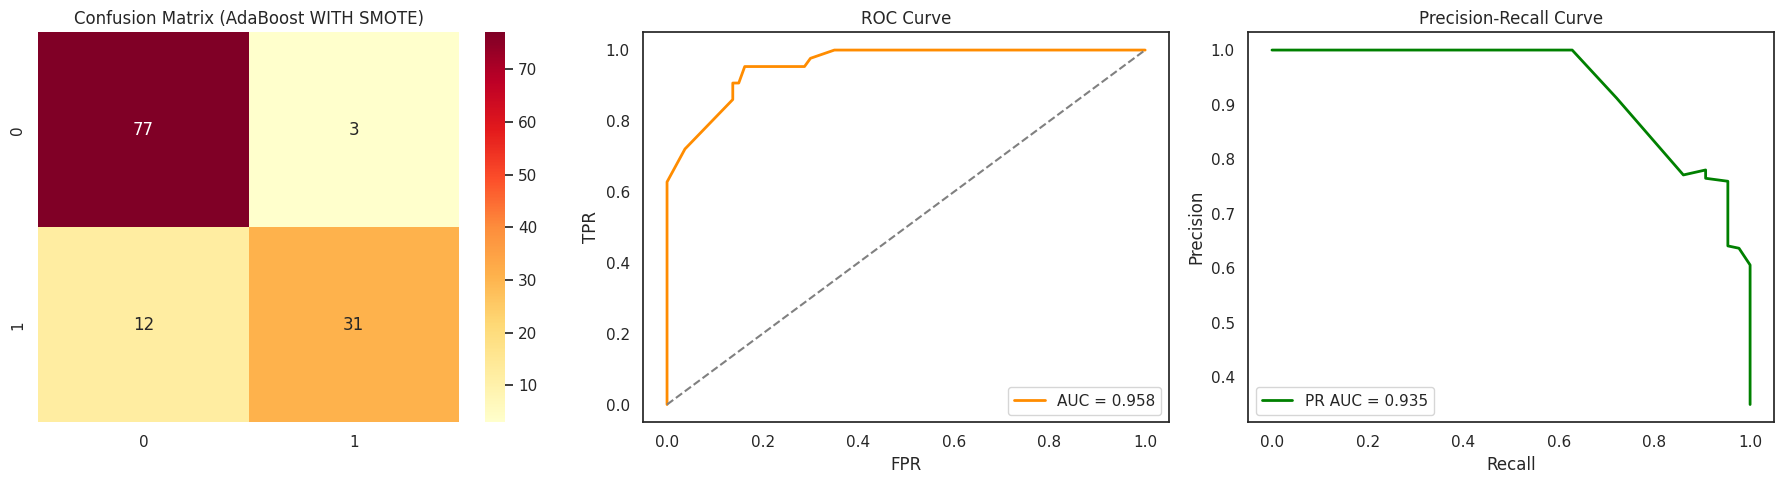


===== AdaBoost Evaluation (WITH SMOTE) =====
AUC (ROC) : 0.9580
PR-AUC    : 0.9350


===== Repeated Stratified K-Fold CV (AdaBoost) =====

===== Repeated CV Results (n_splits=5, n_repeats=10, total runs=50) =====
Accuracy: 0.8663 ± 0.0278
Precision: 0.8574 ± 0.0301
Recall: 0.8738 ± 0.0269
F1: 0.8583 ± 0.0277
ROC: 0.9694 ± 0.0131
LogLoss: 0.2842 ± 0.0242
MCC: 0.7307 ± 0.0528


,Model,Accuracy(cv),Precision(cv),Recall(cv),F1_score(cv),ROC(cv),Log_Loss(cv),mathew_corrcoef(cv),Accuracy(test),Precision(test),Recall(test),F1_score(test),ROC(test),Log_Loss(test),mathew_corrcoef(test)
0,RF (SMOTE),0.955288,0.955057,0.949763,0.950847,0.993171,0.123824,0.904557,0.943089,0.959770,0.918605,0.934738,0.978488,0.165459,0.877410
1,DT (SMOTE),0.947145,0.940885,0.944699,0.942254,0.978119,0.470369,0.885512,0.910569,0.907831,0.893605,0.899993,0.951163,1.010819,0.801310
2,AdaBoost (SMOTE),0.869944,0.859418,0.876271,0.861767,0.970627,0.286051,0.735403,0.878049,0.888467,0.841715,0.858219,0.957994,0.304761,0.728684
3,LR (SMOTE),0.898495,0.918861,0.862415,0.880669,0.948070,0.307521,0.778820,0.861789,0.897932,0.807703,0.831710,0.927035,0.329323,0.699843
4,MLP (SMOTE),0.816883,0.815991,0.835031,0.810201,0.946814,0.459181,0.650674,0.829268,0.815211,0.804215,0.809077,0.920930,0.451966,0.619328


In [ ]:
from imblearn.over_sampling import SMOTE                      # <-- Import SMOTE
from sklearn.model_selection import StratifiedKFold, RepeatedStratifiedKFold
from sklearn.ensemble import AdaBoostClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, log_loss, matthews_corrcoef, confusion_matrix,
                             roc_curve, auc, precision_recall_curve)
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# ====== K-Fold Cross Validation WITH SMOTE + Fold-wise Scaling ======
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_acc, fold_precision, fold_recall = [], [], []
fold_f1, fold_roc, fold_logloss, fold_mcc = [], [], [], []

# Raw (unscaled) data
X_train_arr = X_train.values if hasattr(X_train, "values") else X_train
y_train_arr = y_train.values if hasattr(y_train, "values") else y_train

print("Fold-wise Results (AdaBoost - WITH SMOTE):\n")

for i, (train_idx, val_idx) in enumerate(kf.split(X_train_arr, y_train_arr), 1):
    X_tr, X_val = X_train_arr[train_idx], X_train_arr[val_idx]
    y_tr, y_val = y_train_arr[train_idx], y_train_arr[val_idx]

    # ---- Fold-wise MinMax Scaling (fit ONLY on training fold) ----
    scaler = MinMaxScaler()
    X_tr = scaler.fit_transform(X_tr)
    X_val = scaler.transform(X_val)

    # Apply SMOTE only to the training fold (no data leakage)
    smote = SMOTE(random_state=42)
    X_tr_resampled, y_tr_resampled = smote.fit_resample(X_tr, y_tr)

    # Model: same hyperparameters as without SMOTE
    model = AdaBoostClassifier(
        n_estimators=50,
        learning_rate=0.1,
        random_state=42
    )
    model.fit(X_tr_resampled, y_tr_resampled)                 # Train on resampled fold

    # Predict on the original validation set
    y_val_pred = model.predict(X_val)
    y_val_prob = model.predict_proba(X_val)[:,1]

    # Metrics
    acc = accuracy_score(y_val, y_val_pred)
    precision = precision_score(y_val, y_val_pred, average='macro')
    recall = recall_score(y_val, y_val_pred, average='macro')
    f1 = f1_score(y_val, y_val_pred, average='macro')
    roc = roc_auc_score(y_val, y_val_prob)
    logloss_val = log_loss(y_val, y_val_prob)
    mcc_val = matthews_corrcoef(y_val, y_val_pred)
    CM_val = confusion_matrix(y_val, y_val_pred)

    fold_acc.append(acc)
    fold_precision.append(precision)
    fold_recall.append(recall)
    fold_f1.append(f1)
    fold_roc.append(roc)
    fold_logloss.append(logloss_val)
    fold_mcc.append(mcc_val)

    print(f"Fold {i} → Acc:{acc:.3f} | Prec:{precision:.3f} | Recall:{recall:.3f} | "
          f"F1:{f1:.3f} | ROC:{roc:.3f} | LogLoss:{logloss_val:.3f} | MCC:{mcc_val:.3f}")
    print(f"Confusion Matrix (Fold {i}):\n{CM_val}\n")

# ===== Fold-wise averages =====
print("\n===== CV Fold Average Metrics (AdaBoost WITH SMOTE) =====")
print(f"Accuracy: {np.mean(fold_acc):.4f} ± {np.std(fold_acc):.4f}")
print(f"Precision: {np.mean(fold_precision):.4f} ± {np.std(fold_precision):.4f}")
print(f"Recall: {np.mean(fold_recall):.4f} ± {np.std(fold_recall):.4f}")
print(f"F1: {np.mean(fold_f1):.4f} ± {np.std(fold_f1):.4f}")
print(f"ROC: {np.mean(fold_roc):.4f} ± {np.std(fold_roc):.4f}")
print(f"LogLoss: {np.mean(fold_logloss):.4f} ± {np.std(fold_logloss):.4f}")
print(f"MCC: {np.mean(fold_mcc):.4f} ± {np.std(fold_mcc):.4f}")

# ===== Train final model (WITH SMOTE) =====
# Final scaler: পুরো training set দিয়ে fit, test set এ শুধু transform
final_scaler = MinMaxScaler()
X_train_scaled_final = final_scaler.fit_transform(X_train_arr)

X_test_arr = X_test.values if hasattr(X_test, "values") else X_test
X_test_scaled_final = final_scaler.transform(X_test_arr)

smote_final = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote_final.fit_resample(X_train_scaled_final, y_train_arr)

final_model = AdaBoostClassifier(
    n_estimators=50,
    learning_rate=0.1,
    random_state=42
)
final_model.fit(X_train_resampled, y_train_resampled)

# ===== CV metrics (renamed train -> cv) =====
acc_cv       = np.mean(fold_acc)
precision_cv = np.mean(fold_precision)
recall_cv    = np.mean(fold_recall)
f1_cv        = np.mean(fold_f1)
roc_cv       = np.mean(fold_roc)
logloss_cv   = np.mean(fold_logloss)
mcc_cv       = np.mean(fold_mcc)

# ===== Test metrics =====
y_test_arr = y_test.values if hasattr(y_test, "values") else y_test

y_test_pred = final_model.predict(X_test_scaled_final)
y_test_prob = final_model.predict_proba(X_test_scaled_final)[:,1]

acc_test = accuracy_score(y_test_arr, y_test_pred)
precision_test = precision_score(y_test_arr, y_test_pred, average='macro')
recall_test = recall_score(y_test_arr, y_test_pred, average='macro')
f1_test = f1_score(y_test_arr, y_test_pred, average='macro')
roc_test = roc_auc_score(y_test_arr, y_test_prob)
logloss_test = log_loss(y_test_arr, y_test_prob)
mcc_test = matthews_corrcoef(y_test_arr, y_test_pred)

# ===== Curves =====
CM = confusion_matrix(y_test_arr, y_test_pred)
fpr, tpr, _ = roc_curve(y_test_arr, y_test_prob)
roc_auc = auc(fpr, tpr)
precision_vals, recall_vals, _ = precision_recall_curve(y_test_arr, y_test_prob)
pr_auc = auc(recall_vals, precision_vals)

plt.figure(figsize=(18,5))

plt.subplot(1,3,1)
sns.heatmap(CM, annot=True, fmt='d', cmap='YlOrRd')
plt.title("Confusion Matrix (AdaBoost WITH SMOTE)")

plt.subplot(1,3,2)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}", color='darkorange', lw=2)
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.legend(loc="lower right")

plt.subplot(1,3,3)
plt.plot(recall_vals, precision_vals, label=f"PR AUC = {pr_auc:.3f}", color='green', lw=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend(loc="lower left")

plt.tight_layout()
plt.show()

print("\n===== AdaBoost Evaluation (WITH SMOTE) =====")
print(f"AUC (ROC) : {roc_auc:.4f}")
print(f"PR-AUC    : {pr_auc:.4f}")


# ============================================================
# PART 2: Repeated Stratified K-Fold CV (Fold-wise Scaling)
# ============================================================

N_SPLITS = 5
N_REPEATS = 10   # Total runs = 5 x 10 = 50

rskf = RepeatedStratifiedKFold(
    n_splits=N_SPLITS,
    n_repeats=N_REPEATS,
    random_state=42
)

rep_acc, rep_precision, rep_recall = [], [], []
rep_f1, rep_roc, rep_logloss, rep_mcc = [], [], [], []

print("\n\n===== Repeated Stratified K-Fold CV (AdaBoost) =====\n")

for i, (train_idx, val_idx) in enumerate(
    rskf.split(X_train_arr, y_train_arr), 1
):
    X_tr, X_val = X_train_arr[train_idx], X_train_arr[val_idx]
    y_tr, y_val = y_train_arr[train_idx], y_train_arr[val_idx]

    # ---- Fold-wise MinMax Scaling (fit ONLY on training fold) ----
    scaler_rep = MinMaxScaler()
    X_tr = scaler_rep.fit_transform(X_tr)
    X_val = scaler_rep.transform(X_val)

    # Apply SMOTE only to the training fold to avoid data leakage
    smote_rep = SMOTE(random_state=42)
    X_tr_resampled, y_tr_resampled = smote_rep.fit_resample(X_tr, y_tr)

    model_rep = AdaBoostClassifier(
        n_estimators=50,
        learning_rate=0.1,
        random_state=42
    )

    model_rep.fit(X_tr_resampled, y_tr_resampled)

    y_val_pred = model_rep.predict(X_val)
    y_val_prob = model_rep.predict_proba(X_val)[:,1]

    rep_acc.append(accuracy_score(y_val, y_val_pred))
    rep_precision.append(precision_score(y_val, y_val_pred, average='macro'))
    rep_recall.append(recall_score(y_val, y_val_pred, average='macro'))
    rep_f1.append(f1_score(y_val, y_val_pred, average='macro'))
    rep_roc.append(roc_auc_score(y_val, y_val_prob))
    rep_logloss.append(log_loss(y_val, y_val_prob))
    rep_mcc.append(matthews_corrcoef(y_val, y_val_pred))

    # Printing every run separately would produce a large output (50 runs),
    # so printing is disabled here.


# ===== Repeated CV Mean and Standard Deviation =====
print(f"===== Repeated CV Results (n_splits={N_SPLITS}, n_repeats={N_REPEATS}, total runs={N_SPLITS*N_REPEATS}) =====")
print(f"Accuracy: {np.mean(rep_acc):.4f} ± {np.std(rep_acc):.4f}")
print(f"Precision: {np.mean(rep_precision):.4f} ± {np.std(rep_precision):.4f}")
print(f"Recall: {np.mean(rep_recall):.4f} ± {np.std(rep_recall):.4f}")
print(f"F1: {np.mean(rep_f1):.4f} ± {np.std(rep_f1):.4f}")
print(f"ROC: {np.mean(rep_roc):.4f} ± {np.std(rep_roc):.4f}")
print(f"LogLoss: {np.mean(rep_logloss):.4f} ± {np.std(rep_logloss):.4f}")
print(f"MCC: {np.mean(rep_mcc):.4f} ± {np.std(rep_mcc):.4f}")


# ===== Store Repeated CV Results for Reporting =====
# These values are not added to comp_ev

acc_repcv       = np.mean(rep_acc)
acc_repcv_std   = np.std(rep_acc)
f1_repcv        = np.mean(rep_f1)
f1_repcv_std    = np.std(rep_f1)
mcc_repcv       = np.mean(rep_mcc)
mcc_repcv_std   = np.std(rep_mcc)


# ===== Append metrics to comparison DataFrame =====
r = comp_ev.shape[0]
comp_ev.loc[r] = ['AdaBoost (SMOTE)', acc_cv, precision_cv, recall_cv, f1_cv, roc_cv,
                  logloss_cv, mcc_cv, acc_test, precision_test, recall_test, f1_test, roc_test,
                  logloss_test, mcc_test]

comp_ev = comp_ev.sort_values(by='Accuracy(test)', ascending=False).reset_index(drop=True)
comp_ev

# **XGB**

Fold-wise Results (XGBoost - WITH SMOTE):

Fold 1 → Acc:0.960 | Prec:0.971 | Recall:0.943 | F1:0.955 | ROC:0.980 | LogLoss:0.166 | MCC:0.913
Confusion Matrix (Fold 1):
[[64  0]
 [ 4 31]]

Fold 2 → Acc:0.960 | Prec:0.956 | Recall:0.956 | F1:0.956 | ROC:0.994 | LogLoss:0.110 | MCC:0.912
Confusion Matrix (Fold 2):
[[62  2]
 [ 2 33]]

Fold 3 → Acc:0.959 | Prec:0.949 | Recall:0.968 | F1:0.957 | ROC:0.995 | LogLoss:0.123 | MCC:0.917
Confusion Matrix (Fold 3):
[[59  4]
 [ 0 35]]

Fold 4 → Acc:0.959 | Prec:0.947 | Recall:0.969 | F1:0.956 | ROC:0.998 | LogLoss:0.102 | MCC:0.916
Confusion Matrix (Fold 4):
[[60  4]
 [ 0 34]]

Fold 5 → Acc:0.949 | Prec:0.947 | Recall:0.940 | F1:0.943 | ROC:0.994 | LogLoss:0.099 | MCC:0.887
Confusion Matrix (Fold 5):
[[62  2]
 [ 3 31]]


===== CV Fold Average Metrics (XGBoost WITH SMOTE) =====
Accuracy: 0.9573 ± 0.0042
Precision: 0.9538 ± 0.0090
Recall: 0.9552 ± 0.0121
F1: 0.9533 ± 0.0050
ROC: 0.9922 ± 0.0063
LogLoss: 0.1198 ± 0.0246
MCC: 0.9088 ± 0.0111


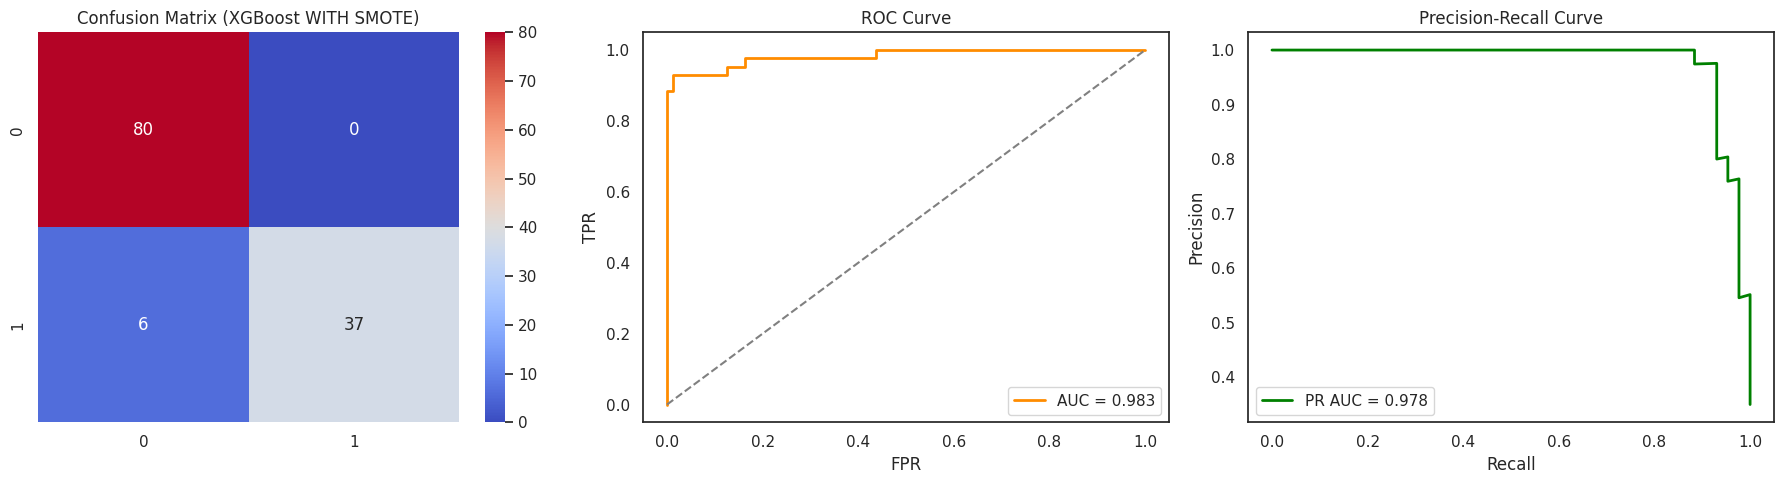


===== XGBoost Evaluation (WITH SMOTE) =====
AUC (ROC) : 0.9826
PR-AUC    : 0.9782


===== Repeated Stratified K-Fold CV (XGBoost with SMOTE) =====

===== Repeated CV Results (n_splits=5, n_repeats=10, total runs=50) =====
Accuracy: 0.9636 ± 0.0181
Precision: 0.9597 ± 0.0209
Recall: 0.9619 ± 0.0194
F1: 0.9603 ± 0.0197
ROC: 0.9933 ± 0.0059
LogLoss: 0.1113 ± 0.0308
MCC: 0.9215 ± 0.0388


,Model,Accuracy(cv),Precision(cv),Recall(cv),F1_score(cv),ROC(cv),Log_Loss(cv),mathew_corrcoef(cv),Accuracy(test),Precision(test),Recall(test),F1_score(test),ROC(test),Log_Loss(test),mathew_corrcoef(test)
0,XGBoost (SMOTE),0.957308,0.953820,0.955184,0.953266,0.992172,0.119800,0.908824,0.951220,0.965116,0.930233,0.944428,0.982558,0.149090,0.894669
1,RF (SMOTE),0.955288,0.955057,0.949763,0.950847,0.993171,0.123824,0.904557,0.943089,0.959770,0.918605,0.934738,0.978488,0.165459,0.877410
2,DT (SMOTE),0.947145,0.940885,0.944699,0.942254,0.978119,0.470369,0.885512,0.910569,0.907831,0.893605,0.899993,0.951163,1.010819,0.801310
3,AdaBoost (SMOTE),0.869944,0.859418,0.876271,0.861767,0.970627,0.286051,0.735403,0.878049,0.888467,0.841715,0.858219,0.957994,0.304761,0.728684
4,LR (SMOTE),0.898495,0.918861,0.862415,0.880669,0.948070,0.307521,0.778820,0.861789,0.897932,0.807703,0.831710,0.927035,0.329323,0.699843
5,MLP (SMOTE),0.816883,0.815991,0.835031,0.810201,0.946814,0.459181,0.650674,0.829268,0.815211,0.804215,0.809077,0.920930,0.451966,0.619328


In [ ]:
from imblearn.over_sampling import SMOTE                      # <-- Import SMOTE
from sklearn.model_selection import StratifiedKFold, RepeatedStratifiedKFold
from sklearn.preprocessing import MinMaxScaler
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, log_loss, matthews_corrcoef, confusion_matrix,
                             roc_curve, auc, precision_recall_curve)
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# PART 1: K-Fold Cross Validation WITH SMOTE + Fold-wise Scaling
# ============================================================

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_acc, fold_precision, fold_recall = [], [], []
fold_f1, fold_roc, fold_logloss, fold_mcc = [], [], [], []

# Raw (unscaled) data
X_train_arr = X_train.values if hasattr(X_train, "values") else X_train
y_train_arr = y_train.values if hasattr(y_train, "values") else y_train

print("Fold-wise Results (XGBoost - WITH SMOTE):\n")

for i, (train_idx, val_idx) in enumerate(kf.split(X_train_arr, y_train_arr), 1):
    X_tr, X_val = X_train_arr[train_idx], X_train_arr[val_idx]
    y_tr, y_val = y_train_arr[train_idx], y_train_arr[val_idx]

    # ---- Fold-wise MinMax Scaling (fit ONLY on training fold) ----
    scaler = MinMaxScaler()
    X_tr = scaler.fit_transform(X_tr)
    X_val = scaler.transform(X_val)

    # Apply SMOTE only to the training fold (no data leakage)
    smote = SMOTE(random_state=42)
    X_tr_resampled, y_tr_resampled = smote.fit_resample(X_tr, y_tr)

    # Model: same hyperparameters as without SMOTE
    model = XGBClassifier(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.05,
        gamma=1,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=2,
        random_state=42,
        eval_metric='logloss'
    )
    model.fit(X_tr_resampled, y_tr_resampled)                 # Train on resampled fold

    # Predict on the original validation set
    y_val_pred = model.predict(X_val)
    y_val_prob = model.predict_proba(X_val)[:,1]

    # Metrics
    acc = accuracy_score(y_val, y_val_pred)
    precision = precision_score(y_val, y_val_pred, average='macro')
    recall = recall_score(y_val, y_val_pred, average='macro')
    f1 = f1_score(y_val, y_val_pred, average='macro')
    roc = roc_auc_score(y_val, y_val_prob)
    logloss_val = log_loss(y_val, y_val_prob)
    mcc_val = matthews_corrcoef(y_val, y_val_pred)
    CM_val = confusion_matrix(y_val, y_val_pred)

    fold_acc.append(acc)
    fold_precision.append(precision)
    fold_recall.append(recall)
    fold_f1.append(f1)
    fold_roc.append(roc)
    fold_logloss.append(logloss_val)
    fold_mcc.append(mcc_val)

    print(f"Fold {i} → Acc:{acc:.3f} | Prec:{precision:.3f} | Recall:{recall:.3f} | "
          f"F1:{f1:.3f} | ROC:{roc:.3f} | LogLoss:{logloss_val:.3f} | MCC:{mcc_val:.3f}")
    print(f"Confusion Matrix (Fold {i}):\n{CM_val}\n")

# ===== Fold-wise averages =====
print("\n===== CV Fold Average Metrics (XGBoost WITH SMOTE) =====")
print(f"Accuracy: {np.mean(fold_acc):.4f} ± {np.std(fold_acc):.4f}")
print(f"Precision: {np.mean(fold_precision):.4f} ± {np.std(fold_precision):.4f}")
print(f"Recall: {np.mean(fold_recall):.4f} ± {np.std(fold_recall):.4f}")
print(f"F1: {np.mean(fold_f1):.4f} ± {np.std(fold_f1):.4f}")
print(f"ROC: {np.mean(fold_roc):.4f} ± {np.std(fold_roc):.4f}")
print(f"LogLoss: {np.mean(fold_logloss):.4f} ± {np.std(fold_logloss):.4f}")
print(f"MCC: {np.mean(fold_mcc):.4f} ± {np.std(fold_mcc):.4f}")

# ===== Train final model (WITH SMOTE) =====
# Final scaler: পুরো training set দিয়ে fit, test set এ শুধু transform
final_scaler = MinMaxScaler()
X_train_scaled_final = final_scaler.fit_transform(X_train_arr)

X_test_arr = X_test.values if hasattr(X_test, "values") else X_test
X_test_scaled_final = final_scaler.transform(X_test_arr)

smote_final = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote_final.fit_resample(X_train_scaled_final, y_train_arr)

final_model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    gamma=1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=2,
    random_state=42,
    eval_metric='logloss'
)
final_model.fit(X_train_resampled, y_train_resampled)

# ===== CV metrics (renamed train -> cv) =====
acc_cv       = np.mean(fold_acc)
precision_cv = np.mean(fold_precision)
recall_cv    = np.mean(fold_recall)
f1_cv        = np.mean(fold_f1)
roc_cv       = np.mean(fold_roc)
logloss_cv   = np.mean(fold_logloss)
mcc_cv       = np.mean(fold_mcc)

# ===== Test metrics =====
y_test_arr = y_test.values if hasattr(y_test, "values") else y_test

y_test_pred = final_model.predict(X_test_scaled_final)
y_test_prob = final_model.predict_proba(X_test_scaled_final)[:,1]

acc_test = accuracy_score(y_test_arr, y_test_pred)
precision_test = precision_score(y_test_arr, y_test_pred, average='macro')
recall_test = recall_score(y_test_arr, y_test_pred, average='macro')
f1_test = f1_score(y_test_arr, y_test_pred, average='macro')
roc_test = roc_auc_score(y_test_arr, y_test_prob)
logloss_test = log_loss(y_test_arr, y_test_prob)
mcc_test = matthews_corrcoef(y_test_arr, y_test_pred)

# ===== Curves =====
CM = confusion_matrix(y_test_arr, y_test_pred)
fpr, tpr, _ = roc_curve(y_test_arr, y_test_prob)
roc_auc = auc(fpr, tpr)
precision_vals, recall_vals, _ = precision_recall_curve(y_test_arr, y_test_prob)
pr_auc = auc(recall_vals, precision_vals)

plt.figure(figsize=(18,5))

plt.subplot(1,3,1)
sns.heatmap(CM, annot=True, fmt='d', cmap='coolwarm')
plt.title("Confusion Matrix (XGBoost WITH SMOTE)")

plt.subplot(1,3,2)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}", color='darkorange', lw=2)
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.legend(loc="lower right")

plt.subplot(1,3,3)
plt.plot(recall_vals, precision_vals, label=f"PR AUC = {pr_auc:.3f}", color='green', lw=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend(loc="lower left")

plt.tight_layout()
plt.show()

print("\n===== XGBoost Evaluation (WITH SMOTE) =====")
print(f"AUC (ROC) : {roc_auc:.4f}")
print(f"PR-AUC    : {pr_auc:.4f}")


# ============================================================
# PART 2: Repeated Stratified K-Fold Cross-Validation
# Purpose: Assess the stability and robustness of the model
# across multiple train-validation splits.
# ============================================================

N_SPLITS = 5
N_REPEATS = 10   # Total runs = 5 x 10 = 50

rskf = RepeatedStratifiedKFold(
    n_splits=N_SPLITS,
    n_repeats=N_REPEATS,
    random_state=42
)

rep_acc, rep_precision, rep_recall = [], [], []
rep_f1, rep_roc, rep_logloss, rep_mcc = [], [], [], []

print("\n\n===== Repeated Stratified K-Fold CV (XGBoost with SMOTE) =====\n")

for i, (train_idx, val_idx) in enumerate(
    rskf.split(X_train_arr, y_train_arr), 1
):
    X_tr, X_val = X_train_arr[train_idx], X_train_arr[val_idx]
    y_tr, y_val = y_train_arr[train_idx], y_train_arr[val_idx]

    # ---- Fold-wise MinMax Scaling (fit ONLY on training fold) ----
    scaler_rep = MinMaxScaler()
    X_tr = scaler_rep.fit_transform(X_tr)
    X_val = scaler_rep.transform(X_val)

    # Apply SMOTE only to the training fold to avoid data leakage
    smote_rep = SMOTE(random_state=42)
    X_tr_resampled, y_tr_resampled = smote_rep.fit_resample(X_tr, y_tr)

    model_rep = XGBClassifier(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.05,
        gamma=1,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=2,
        random_state=42,
        eval_metric='logloss'
    )

    model_rep.fit(X_tr_resampled, y_tr_resampled)

    y_val_pred = model_rep.predict(X_val)
    y_val_prob = model_rep.predict_proba(X_val)[:,1]

    rep_acc.append(accuracy_score(y_val, y_val_pred))
    rep_precision.append(precision_score(y_val, y_val_pred, average='macro'))
    rep_recall.append(recall_score(y_val, y_val_pred, average='macro'))
    rep_f1.append(f1_score(y_val, y_val_pred, average='macro'))
    rep_roc.append(roc_auc_score(y_val, y_val_prob))
    rep_logloss.append(log_loss(y_val, y_val_prob))
    rep_mcc.append(matthews_corrcoef(y_val, y_val_pred))

    # Printing every run separately would produce a large output (50 runs),
    # so printing is disabled here.


# ===== Repeated CV Mean and Standard Deviation =====
print(f"===== Repeated CV Results (n_splits={N_SPLITS}, n_repeats={N_REPEATS}, total runs={N_SPLITS*N_REPEATS}) =====")
print(f"Accuracy: {np.mean(rep_acc):.4f} ± {np.std(rep_acc):.4f}")
print(f"Precision: {np.mean(rep_precision):.4f} ± {np.std(rep_precision):.4f}")
print(f"Recall: {np.mean(rep_recall):.4f} ± {np.std(rep_recall):.4f}")
print(f"F1: {np.mean(rep_f1):.4f} ± {np.std(rep_f1):.4f}")
print(f"ROC: {np.mean(rep_roc):.4f} ± {np.std(rep_roc):.4f}")
print(f"LogLoss: {np.mean(rep_logloss):.4f} ± {np.std(rep_logloss):.4f}")
print(f"MCC: {np.mean(rep_mcc):.4f} ± {np.std(rep_mcc):.4f}")


# ===== Store Repeated CV Results for Reporting =====
# These values are not added to comp_ev

acc_repcv       = np.mean(rep_acc)
acc_repcv_std   = np.std(rep_acc)
f1_repcv        = np.mean(rep_f1)
f1_repcv_std    = np.std(rep_f1)
mcc_repcv       = np.mean(rep_mcc)
mcc_repcv_std   = np.std(rep_mcc)


# ============================================================
# PART 3: Append metrics to comparison DataFrame
# Only the original CV/test metrics are added.
# Repeated CV results are NOT added to comp_ev.
# ============================================================

r = comp_ev.shape[0]
comp_ev.loc[r] = ['XGBoost (SMOTE)', acc_cv, precision_cv, recall_cv, f1_cv, roc_cv,
                  logloss_cv, mcc_cv, acc_test, precision_test, recall_test, f1_test, roc_test,
                  logloss_test, mcc_test]

comp_ev = comp_ev.sort_values(by='Accuracy(test)', ascending=False).reset_index(drop=True)
comp_ev

# **SVC**

Fold-wise Results (SVC - WITH SMOTE):

Fold 1 → Acc:0.859 | Prec:0.910 | Recall:0.800 | F1:0.826 | ROC:0.942 | LogLoss:0.304 | MCC:0.702
Confusion Matrix (Fold 1):
[[64  0]
 [14 21]]

Fold 2 → Acc:0.899 | Prec:0.932 | Recall:0.857 | F1:0.880 | ROC:0.982 | LogLoss:0.199 | MCC:0.786
Confusion Matrix (Fold 2):
[[64  0]
 [10 25]]

Fold 3 → Acc:0.908 | Prec:0.938 | Recall:0.871 | F1:0.893 | ROC:0.969 | LogLoss:0.214 | MCC:0.806
Confusion Matrix (Fold 3):
[[63  0]
 [ 9 26]]

Fold 4 → Acc:0.949 | Prec:0.964 | Recall:0.926 | F1:0.942 | ROC:0.990 | LogLoss:0.161 | MCC:0.889
Confusion Matrix (Fold 4):
[[64  0]
 [ 5 29]]

Fold 5 → Acc:0.908 | Prec:0.938 | Recall:0.868 | F1:0.891 | ROC:0.983 | LogLoss:0.184 | MCC:0.803
Confusion Matrix (Fold 5):
[[64  0]
 [ 9 25]]


===== CV Fold Average Metrics (SVC WITH SMOTE) =====
Accuracy: 0.9046 ± 0.0288
Precision: 0.9365 ± 0.0170
Recall: 0.8645 ± 0.0403
F1: 0.8863 ± 0.0369
ROC: 0.9730 ± 0.0170
LogLoss: 0.2121 ± 0.0489
MCC: 0.7972 ± 0.0598


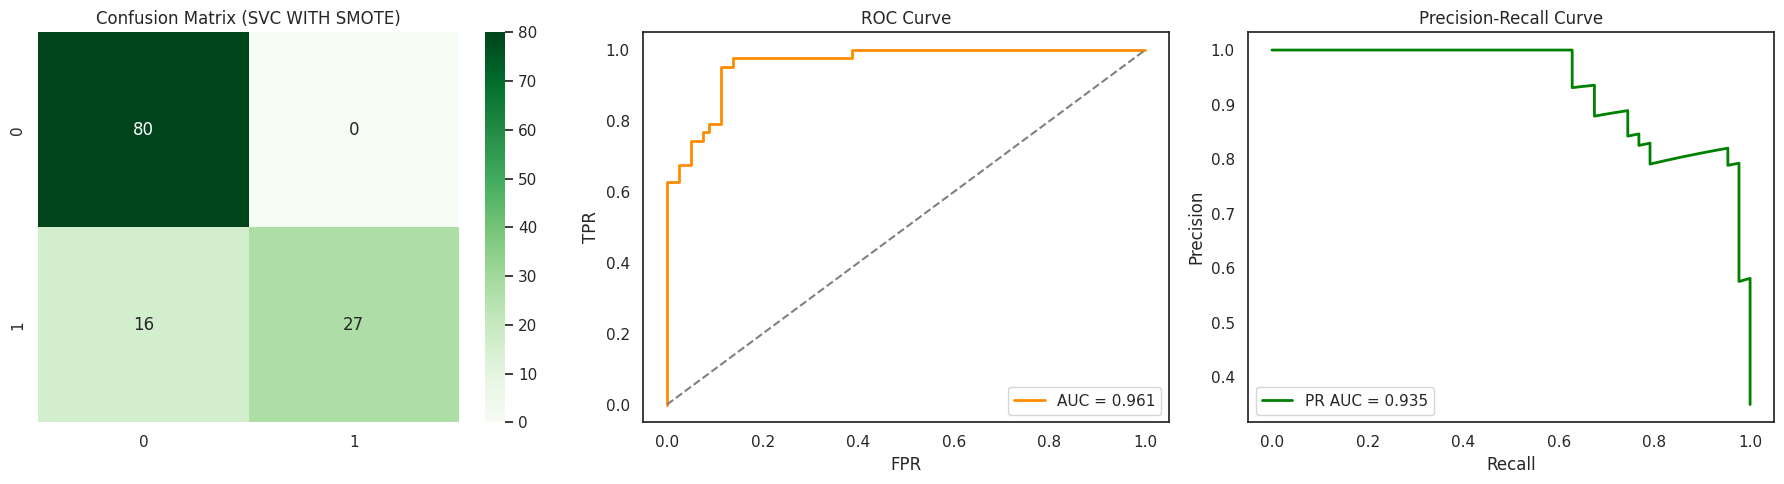


===== SVC Evaluation (WITH SMOTE) =====
AUC (ROC) : 0.9610
PR-AUC    : 0.9349


===== Repeated Stratified K-Fold CV (SVC with SMOTE) =====

===== Repeated CV Results (n_splits=5, n_repeats=10, total runs=50) =====
Accuracy: 0.9043 ± 0.0221
Precision: 0.9351 ± 0.0131
Recall: 0.8646 ± 0.0320
F1: 0.8864 ± 0.0287
ROC: 0.9758 ± 0.0103
LogLoss: 0.2093 ± 0.0361
MCC: 0.7961 ± 0.0460


,Model,Accuracy(cv),Precision(cv),Recall(cv),F1_score(cv),ROC(cv),Log_Loss(cv),mathew_corrcoef(cv),Accuracy(test),Precision(test),Recall(test),F1_score(test),ROC(test),Log_Loss(test),mathew_corrcoef(test)
0,XGBoost (SMOTE),0.957308,0.953820,0.955184,0.953266,0.992172,0.119800,0.908824,0.951220,0.965116,0.930233,0.944428,0.982558,0.149090,0.894669
1,RF (SMOTE),0.955288,0.955057,0.949763,0.950847,0.993171,0.123824,0.904557,0.943089,0.959770,0.918605,0.934738,0.978488,0.165459,0.877410
2,DT (SMOTE),0.947145,0.940885,0.944699,0.942254,0.978119,0.470369,0.885512,0.910569,0.907831,0.893605,0.899993,0.951163,1.010819,0.801310
3,AdaBoost (SMOTE),0.869944,0.859418,0.876271,0.861767,0.970627,0.286051,0.735403,0.878049,0.888467,0.841715,0.858219,0.957994,0.304761,0.728684
4,SVC (SMOTE),0.904576,0.936463,0.864538,0.886288,0.973048,0.212145,0.797240,0.869919,0.916667,0.813953,0.840260,0.961047,0.235815,0.723364
5,LR (SMOTE),0.898495,0.918861,0.862415,0.880669,0.948070,0.307521,0.778820,0.861789,0.897932,0.807703,0.831710,0.927035,0.329323,0.699843
6,MLP (SMOTE),0.816883,0.815991,0.835031,0.810201,0.946814,0.459181,0.650674,0.829268,0.815211,0.804215,0.809077,0.920930,0.451966,0.619328


In [ ]:
from imblearn.over_sampling import SMOTE                      # <-- Import SMOTE
from sklearn.model_selection import StratifiedKFold, RepeatedStratifiedKFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, log_loss, matthews_corrcoef, confusion_matrix,
                             roc_curve, auc, precision_recall_curve)
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# PART 1: K-Fold Cross Validation WITH SMOTE + Fold-wise Scaling
# ============================================================

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_acc, fold_precision, fold_recall = [], [], []
fold_f1, fold_roc, fold_logloss, fold_mcc = [], [], [], []

# Raw (unscaled) data
X_train_arr = X_train.values if hasattr(X_train, "values") else X_train
y_train_arr = y_train.values if hasattr(y_train, "values") else y_train

print("Fold-wise Results (SVC - WITH SMOTE):\n")

for i, (train_idx, val_idx) in enumerate(kf.split(X_train_arr, y_train_arr), 1):
    X_tr, X_val = X_train_arr[train_idx], X_train_arr[val_idx]
    y_tr, y_val = y_train_arr[train_idx], y_train_arr[val_idx]

    # ---- Fold-wise MinMax Scaling (fit ONLY on training fold) ----
    scaler = MinMaxScaler()
    X_tr = scaler.fit_transform(X_tr)
    X_val = scaler.transform(X_val)

    # Apply SMOTE only to the training fold (no data leakage)
    smote = SMOTE(random_state=42)
    X_tr_resampled, y_tr_resampled = smote.fit_resample(X_tr, y_tr)

    # Model: removed class_weight='balanced' because SMOTE handles imbalance
    model = SVC(
        kernel='rbf',
        C=0.5,
        gamma='scale',
        probability=True,
        random_state=42
    )
    model.fit(X_tr_resampled, y_tr_resampled)                 # Train on resampled fold

    # Predict on the original validation set
    y_val_pred = model.predict(X_val)
    y_val_prob = model.predict_proba(X_val)[:,1]

    # Metrics
    acc = accuracy_score(y_val, y_val_pred)
    precision = precision_score(y_val, y_val_pred, average='macro')
    recall = recall_score(y_val, y_val_pred, average='macro')
    f1 = f1_score(y_val, y_val_pred, average='macro')
    roc = roc_auc_score(y_val, y_val_prob)
    logloss_val = log_loss(y_val, y_val_prob)
    mcc_val = matthews_corrcoef(y_val, y_val_pred)
    CM_val = confusion_matrix(y_val, y_val_pred)

    fold_acc.append(acc)
    fold_precision.append(precision)
    fold_recall.append(recall)
    fold_f1.append(f1)
    fold_roc.append(roc)
    fold_logloss.append(logloss_val)
    fold_mcc.append(mcc_val)

    print(f"Fold {i} → Acc:{acc:.3f} | Prec:{precision:.3f} | Recall:{recall:.3f} | "
          f"F1:{f1:.3f} | ROC:{roc:.3f} | LogLoss:{logloss_val:.3f} | MCC:{mcc_val:.3f}")
    print(f"Confusion Matrix (Fold {i}):\n{CM_val}\n")

# ===== Fold-wise averages =====
print("\n===== CV Fold Average Metrics (SVC WITH SMOTE) =====")
print(f"Accuracy: {np.mean(fold_acc):.4f} ± {np.std(fold_acc):.4f}")
print(f"Precision: {np.mean(fold_precision):.4f} ± {np.std(fold_precision):.4f}")
print(f"Recall: {np.mean(fold_recall):.4f} ± {np.std(fold_recall):.4f}")
print(f"F1: {np.mean(fold_f1):.4f} ± {np.std(fold_f1):.4f}")
print(f"ROC: {np.mean(fold_roc):.4f} ± {np.std(fold_roc):.4f}")
print(f"LogLoss: {np.mean(fold_logloss):.4f} ± {np.std(fold_logloss):.4f}")
print(f"MCC: {np.mean(fold_mcc):.4f} ± {np.std(fold_mcc):.4f}")

# ===== Train final model (WITH SMOTE) =====
# Final scaler: পুরো training set দিয়ে fit, test set এ শুধু transform
final_scaler = MinMaxScaler()
X_train_scaled_final = final_scaler.fit_transform(X_train_arr)

X_test_arr = X_test.values if hasattr(X_test, "values") else X_test
X_test_scaled_final = final_scaler.transform(X_test_arr)

smote_final = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote_final.fit_resample(X_train_scaled_final, y_train_arr)

final_model = SVC(
    kernel='rbf',
    C=0.5,
    gamma='scale',
    probability=True,
    random_state=42
)
final_model.fit(X_train_resampled, y_train_resampled)

# ===== CV metrics (renamed train -> cv) =====
acc_cv       = np.mean(fold_acc)
precision_cv = np.mean(fold_precision)
recall_cv    = np.mean(fold_recall)
f1_cv        = np.mean(fold_f1)
roc_cv       = np.mean(fold_roc)
logloss_cv   = np.mean(fold_logloss)
mcc_cv       = np.mean(fold_mcc)

# ===== Test metrics =====
y_test_arr = y_test.values if hasattr(y_test, "values") else y_test

y_test_pred = final_model.predict(X_test_scaled_final)
y_test_prob = final_model.predict_proba(X_test_scaled_final)[:,1]

acc_test = accuracy_score(y_test_arr, y_test_pred)
precision_test = precision_score(y_test_arr, y_test_pred, average='macro')
recall_test = recall_score(y_test_arr, y_test_pred, average='macro')
f1_test = f1_score(y_test_arr, y_test_pred, average='macro')
roc_test = roc_auc_score(y_test_arr, y_test_prob)
logloss_test = log_loss(y_test_arr, y_test_prob)
mcc_test = matthews_corrcoef(y_test_arr, y_test_pred)

# ===== Curves =====
CM = confusion_matrix(y_test_arr, y_test_pred)
fpr, tpr, _ = roc_curve(y_test_arr, y_test_prob)
roc_auc = auc(fpr, tpr)
precision_vals, recall_vals, _ = precision_recall_curve(y_test_arr, y_test_prob)
pr_auc = auc(recall_vals, precision_vals)

plt.figure(figsize=(18,5))

plt.subplot(1,3,1)
sns.heatmap(CM, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix (SVC WITH SMOTE)")

plt.subplot(1,3,2)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}", color='darkorange', lw=2)
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.legend(loc="lower right")

plt.subplot(1,3,3)
plt.plot(recall_vals, precision_vals, label=f"PR AUC = {pr_auc:.3f}", color='green', lw=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend(loc="lower left")

plt.tight_layout()
plt.show()

print("\n===== SVC Evaluation (WITH SMOTE) =====")
print(f"AUC (ROC) : {roc_auc:.4f}")
print(f"PR-AUC    : {pr_auc:.4f}")


# ============================================================
# PART 2: Repeated Stratified K-Fold Cross-Validation
# Purpose: Assess the stability and robustness of the model
# across multiple train-validation splits.
# ============================================================

N_SPLITS = 5
N_REPEATS = 10   # Total runs = 5 x 10 = 50

rskf = RepeatedStratifiedKFold(
    n_splits=N_SPLITS,
    n_repeats=N_REPEATS,
    random_state=42
)

rep_acc, rep_precision, rep_recall = [], [], []
rep_f1, rep_roc, rep_logloss, rep_mcc = [], [], [], []

print("\n\n===== Repeated Stratified K-Fold CV (SVC with SMOTE) =====\n")

for i, (train_idx, val_idx) in enumerate(
    rskf.split(X_train_arr, y_train_arr), 1
):
    X_tr, X_val = X_train_arr[train_idx], X_train_arr[val_idx]
    y_tr, y_val = y_train_arr[train_idx], y_train_arr[val_idx]

    # ---- Fold-wise MinMax Scaling (fit ONLY on training fold) ----
    scaler_rep = MinMaxScaler()
    X_tr = scaler_rep.fit_transform(X_tr)
    X_val = scaler_rep.transform(X_val)

    # Apply SMOTE only to the training fold to avoid data leakage
    smote_rep = SMOTE(random_state=42)
    X_tr_resampled, y_tr_resampled = smote_rep.fit_resample(X_tr, y_tr)

    model_rep = SVC(
        kernel='rbf',
        C=0.5,
        gamma='scale',
        probability=True,
        random_state=42
    )

    model_rep.fit(X_tr_resampled, y_tr_resampled)

    y_val_pred = model_rep.predict(X_val)
    y_val_prob = model_rep.predict_proba(X_val)[:,1]

    rep_acc.append(accuracy_score(y_val, y_val_pred))
    rep_precision.append(precision_score(y_val, y_val_pred, average='macro'))
    rep_recall.append(recall_score(y_val, y_val_pred, average='macro'))
    rep_f1.append(f1_score(y_val, y_val_pred, average='macro'))
    rep_roc.append(roc_auc_score(y_val, y_val_prob))
    rep_logloss.append(log_loss(y_val, y_val_prob))
    rep_mcc.append(matthews_corrcoef(y_val, y_val_pred))

    # Printing every run separately would produce a large output (50 runs),
    # so printing is disabled here.


# ===== Repeated CV Mean and Standard Deviation =====
print(f"===== Repeated CV Results (n_splits={N_SPLITS}, n_repeats={N_REPEATS}, total runs={N_SPLITS*N_REPEATS}) =====")
print(f"Accuracy: {np.mean(rep_acc):.4f} ± {np.std(rep_acc):.4f}")
print(f"Precision: {np.mean(rep_precision):.4f} ± {np.std(rep_precision):.4f}")
print(f"Recall: {np.mean(rep_recall):.4f} ± {np.std(rep_recall):.4f}")
print(f"F1: {np.mean(rep_f1):.4f} ± {np.std(rep_f1):.4f}")
print(f"ROC: {np.mean(rep_roc):.4f} ± {np.std(rep_roc):.4f}")
print(f"LogLoss: {np.mean(rep_logloss):.4f} ± {np.std(rep_logloss):.4f}")
print(f"MCC: {np.mean(rep_mcc):.4f} ± {np.std(rep_mcc):.4f}")


# ===== Store Repeated CV Results for Reporting =====
# These values are not added to comp_ev

acc_repcv       = np.mean(rep_acc)
acc_repcv_std   = np.std(rep_acc)
f1_repcv        = np.mean(rep_f1)
f1_repcv_std    = np.std(rep_f1)
mcc_repcv       = np.mean(rep_mcc)
mcc_repcv_std   = np.std(rep_mcc)


# ============================================================
# PART 3: Append metrics to comparison DataFrame
# Only the original CV/test metrics are added.
# ============================================================

r = comp_ev.shape[0]
comp_ev.loc[r] = ['SVC (SMOTE)', acc_cv, precision_cv, recall_cv, f1_cv, roc_cv,
                  logloss_cv, mcc_cv, acc_test, precision_test, recall_test, f1_test, roc_test,
                  logloss_test, mcc_test]

comp_ev = comp_ev.sort_values(by='Accuracy(test)', ascending=False).reset_index(drop=True)
comp_ev

# **LGBM**

Fold-wise Results (LGBM - WITH SMOTE + fold-wise scaling):

Fold 1 → Acc:0.949 | Prec:0.955 | Recall:0.935 | F1:0.944 | ROC:0.981 | LogLoss:0.132 | MCC:0.889
Confusion Matrix (Fold 1):
[[63  1]
 [ 4 31]]

Fold 2 → Acc:0.960 | Prec:0.956 | Recall:0.956 | F1:0.956 | ROC:0.971 | LogLoss:0.121 | MCC:0.912
Confusion Matrix (Fold 2):
[[62  2]
 [ 2 33]]

Fold 3 → Acc:0.969 | Prec:0.970 | Recall:0.963 | F1:0.966 | ROC:0.997 | LogLoss:0.104 | MCC:0.933
Confusion Matrix (Fold 3):
[[62  1]
 [ 2 33]]

Fold 4 → Acc:0.949 | Prec:0.941 | Recall:0.947 | F1:0.944 | ROC:0.983 | LogLoss:0.153 | MCC:0.888
Confusion Matrix (Fold 4):
[[61  3]
 [ 2 32]]



/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/ut

Fold 5 → Acc:0.939 | Prec:0.947 | Recall:0.919 | F1:0.930 | ROC:0.994 | LogLoss:0.132 | MCC:0.865
Confusion Matrix (Fold 5):
[[63  1]
 [ 5 29]]


===== CV Fold Average Metrics (LGBM WITH SMOTE + fold-wise scaling) =====
Accuracy: 0.9532 ± 0.0104
Precision: 0.9536 ± 0.0096
Recall: 0.9440 ± 0.0158
F1: 0.9481 ± 0.0122
ROC: 0.9850 ± 0.0094
LogLoss: 0.1284 ± 0.0159
MCC: 0.8975 ± 0.0232


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


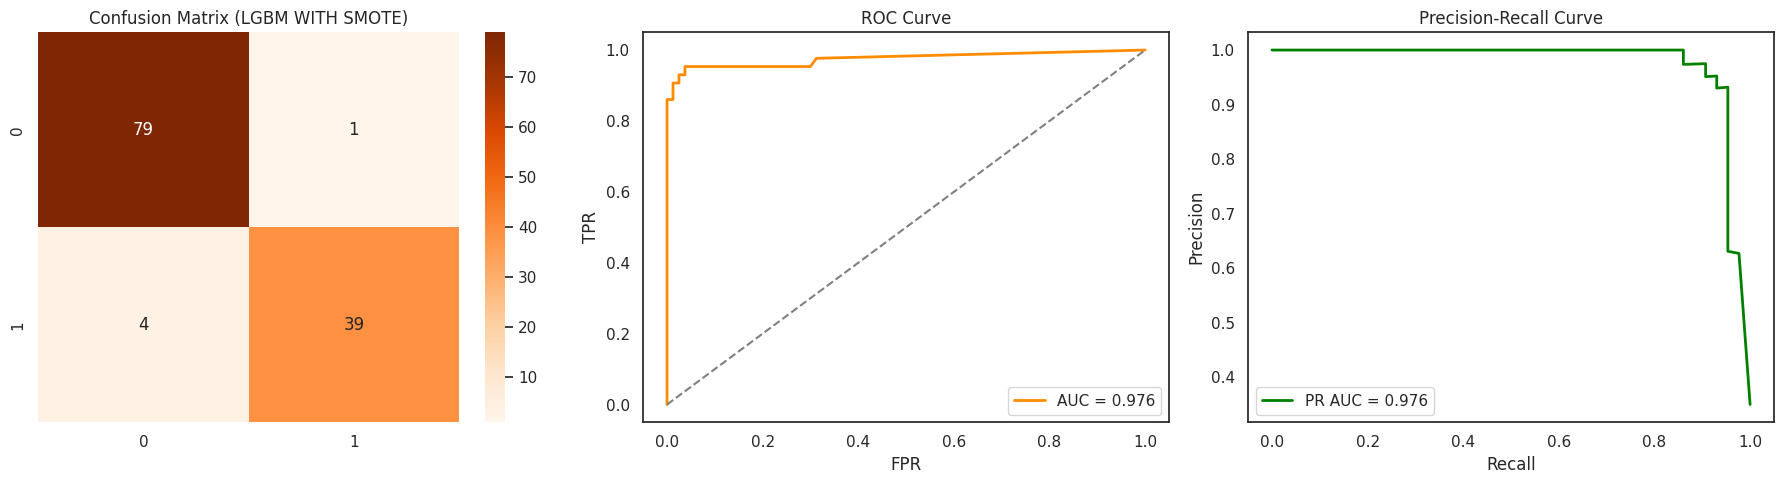


===== LGBM Evaluation (WITH SMOTE) =====
AUC (ROC) : 0.9756
PR-AUC    : 0.9755


===== Repeated Stratified K-Fold CV (LGBM with SMOTE + fold-wise scaling) =====



/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/ut

===== Repeated CV Results (n_splits=5, n_repeats=10, total runs=50) =====
Accuracy: 0.9606 ± 0.0204
Precision: 0.9593 ± 0.0227
Recall: 0.9548 ± 0.0233
F1: 0.9566 ± 0.0225
ROC: 0.9901 ± 0.0092
LogLoss: 0.1176 ± 0.0382
MCC: 0.9140 ± 0.0446


,Model,Accuracy(cv),Precision(cv),Recall(cv),F1_score(cv),ROC(cv),Log_Loss(cv),mathew_corrcoef(cv),Accuracy(test),Precision(test),Recall(test),F1_score(test),ROC(test),Log_Loss(test),mathew_corrcoef(test)
0,LightGBM (SMOTE),0.953247,0.953567,0.944030,0.948067,0.985034,0.128383,0.897456,0.959350,0.963404,0.947238,0.954542,0.975581,0.150155,0.910498
1,XGBoost (SMOTE),0.957308,0.953820,0.955184,0.953266,0.992172,0.119800,0.908824,0.951220,0.965116,0.930233,0.944428,0.982558,0.149090,0.894669
2,RF (SMOTE),0.955288,0.955057,0.949763,0.950847,0.993171,0.123824,0.904557,0.943089,0.959770,0.918605,0.934738,0.978488,0.165459,0.877410
3,DT (SMOTE),0.947145,0.940885,0.944699,0.942254,0.978119,0.470369,0.885512,0.910569,0.907831,0.893605,0.899993,0.951163,1.010819,0.801310
4,AdaBoost (SMOTE),0.869944,0.859418,0.876271,0.861767,0.970627,0.286051,0.735403,0.878049,0.888467,0.841715,0.858219,0.957994,0.304761,0.728684
5,SVC (SMOTE),0.904576,0.936463,0.864538,0.886288,0.973048,0.212145,0.797240,0.869919,0.916667,0.813953,0.840260,0.961047,0.235815,0.723364
6,LR (SMOTE),0.898495,0.918861,0.862415,0.880669,0.948070,0.307521,0.778820,0.861789,0.897932,0.807703,0.831710,0.927035,0.329323,0.699843
7,MLP (SMOTE),0.816883,0.815991,0.835031,0.810201,0.946814,0.459181,0.650674,0.829268,0.815211,0.804215,0.809077,0.920930,0.451966,0.619328


In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold, RepeatedStratifiedKFold
from sklearn.preprocessing import MinMaxScaler
import lightgbm as lgb
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, log_loss, matthews_corrcoef, confusion_matrix,
                             roc_curve, auc, precision_recall_curve)
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# PART 1: K-Fold Cross Validation WITH SMOTE + Fold-wise Scaling
# ============================================================

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_acc, fold_precision, fold_recall = [], [], []
fold_f1, fold_roc, fold_logloss, fold_mcc = [], [], [], []

# Raw (unscaled) data - scaling will be done per fold
X_train_arr = X_train.values if hasattr(X_train, "values") else X_train
y_train_arr = y_train.values if hasattr(y_train, "values") else y_train

print("Fold-wise Results (LGBM - WITH SMOTE + fold-wise scaling):\n")

for i, (train_idx, val_idx) in enumerate(kf.split(X_train_arr, y_train_arr), 1):
    X_tr, X_val = X_train_arr[train_idx], X_train_arr[val_idx]
    y_tr, y_val = y_train_arr[train_idx], y_train_arr[val_idx]

    # ---- Fold-wise MinMax Scaling (fit ONLY on training fold) ----
    scaler = MinMaxScaler()
    X_tr = scaler.fit_transform(X_tr)
    X_val = scaler.transform(X_val)

    # Apply SMOTE only to the training fold (no data leakage)
    smote = SMOTE(random_state=42)
    X_tr_resampled, y_tr_resampled = smote.fit_resample(X_tr, y_tr)

    # Model: same hyperparameters as without SMOTE
    model = lgb.LGBMClassifier(
        n_estimators=100,
        learning_rate=0.03,
        num_leaves=15,
        min_data_in_leaf=10,
        lambda_l1=0.1,
        lambda_l2=0.1,
        min_gain_to_split=0.01,
        random_state=42,
        verbosity=-1
    )
    model.fit(X_tr_resampled, y_tr_resampled)                 # Train on resampled fold

    # Predict on the original validation set
    y_val_pred = model.predict(X_val)
    y_val_prob = model.predict_proba(X_val)[:,1]

    # Metrics
    acc = accuracy_score(y_val, y_val_pred)
    precision = precision_score(y_val, y_val_pred, average='macro')
    recall = recall_score(y_val, y_val_pred, average='macro')
    f1 = f1_score(y_val, y_val_pred, average='macro')
    roc = roc_auc_score(y_val, y_val_prob)
    logloss_val = log_loss(y_val, y_val_prob)
    mcc_val = matthews_corrcoef(y_val, y_val_pred)
    CM_val = confusion_matrix(y_val, y_val_pred)

    fold_acc.append(acc)
    fold_precision.append(precision)
    fold_recall.append(recall)
    fold_f1.append(f1)
    fold_roc.append(roc)
    fold_logloss.append(logloss_val)
    fold_mcc.append(mcc_val)

    print(f"Fold {i} → Acc:{acc:.3f} | Prec:{precision:.3f} | Recall:{recall:.3f} | "
          f"F1:{f1:.3f} | ROC:{roc:.3f} | LogLoss:{logloss_val:.3f} | MCC:{mcc_val:.3f}")
    print(f"Confusion Matrix (Fold {i}):\n{CM_val}\n")

# ===== Fold-wise averages =====
print("\n===== CV Fold Average Metrics (LGBM WITH SMOTE + fold-wise scaling) =====")
print(f"Accuracy: {np.mean(fold_acc):.4f} ± {np.std(fold_acc):.4f}")
print(f"Precision: {np.mean(fold_precision):.4f} ± {np.std(fold_precision):.4f}")
print(f"Recall: {np.mean(fold_recall):.4f} ± {np.std(fold_recall):.4f}")
print(f"F1: {np.mean(fold_f1):.4f} ± {np.std(fold_f1):.4f}")
print(f"ROC: {np.mean(fold_roc):.4f} ± {np.std(fold_roc):.4f}")
print(f"LogLoss: {np.mean(fold_logloss):.4f} ± {np.std(fold_logloss):.4f}")
print(f"MCC: {np.mean(fold_mcc):.4f} ± {np.std(fold_mcc):.4f}")

# ===== Train final model (WITH SMOTE) =====
# Final scaler: fit on entire training set, transform test set
final_scaler = MinMaxScaler()
X_train_scaled_final = final_scaler.fit_transform(X_train_arr)

X_test_arr = X_test.values if hasattr(X_test, "values") else X_test
X_test_scaled_final = final_scaler.transform(X_test_arr)

smote_final = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote_final.fit_resample(X_train_scaled_final, y_train_arr)

final_model = lgb.LGBMClassifier(
    n_estimators=100,
    learning_rate=0.03,
    num_leaves=15,
    min_data_in_leaf=10,
    lambda_l1=0.1,
    lambda_l2=0.1,
    min_gain_to_split=0.01,
    random_state=42,
    verbosity=-1
)
final_model.fit(X_train_resampled, y_train_resampled)

# ===== CV metrics (renamed as train/cv) =====
acc_cv       = np.mean(fold_acc)
precision_cv = np.mean(fold_precision)
recall_cv    = np.mean(fold_recall)
f1_cv        = np.mean(fold_f1)
roc_cv       = np.mean(fold_roc)
logloss_cv   = np.mean(fold_logloss)
mcc_cv       = np.mean(fold_mcc)

# ===== Test metrics =====
y_test_arr = y_test.values if hasattr(y_test, "values") else y_test

y_test_pred = final_model.predict(X_test_scaled_final)
y_test_prob = final_model.predict_proba(X_test_scaled_final)[:,1]

acc_test = accuracy_score(y_test_arr, y_test_pred)
precision_test = precision_score(y_test_arr, y_test_pred, average='macro')
recall_test = recall_score(y_test_arr, y_test_pred, average='macro')
f1_test = f1_score(y_test_arr, y_test_pred, average='macro')
roc_test = roc_auc_score(y_test_arr, y_test_prob)
logloss_test = log_loss(y_test_arr, y_test_prob)
mcc_test = matthews_corrcoef(y_test_arr, y_test_pred)

# ===== Curves =====
CM = confusion_matrix(y_test_arr, y_test_pred)
fpr, tpr, _ = roc_curve(y_test_arr, y_test_prob)
roc_auc = auc(fpr, tpr)
precision_vals, recall_vals, _ = precision_recall_curve(y_test_arr, y_test_prob)
pr_auc = auc(recall_vals, precision_vals)

plt.figure(figsize=(18,5))

plt.subplot(1,3,1)
sns.heatmap(CM, annot=True, fmt='d', cmap='Oranges')
plt.title("Confusion Matrix (LGBM WITH SMOTE)")

plt.subplot(1,3,2)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}", color='darkorange', lw=2)
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.legend(loc="lower right")

plt.subplot(1,3,3)
plt.plot(recall_vals, precision_vals, label=f"PR AUC = {pr_auc:.3f}", color='green', lw=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend(loc="lower left")

plt.tight_layout()
plt.show()

print("\n===== LGBM Evaluation (WITH SMOTE) =====")
print(f"AUC (ROC) : {roc_auc:.4f}")
print(f"PR-AUC    : {pr_auc:.4f}")


# ============================================================
# PART 2: Repeated Stratified K-Fold Cross-Validation
# Purpose: Assess the stability and robustness of the model
# across multiple train-validation splits.
# ============================================================

N_SPLITS = 5
N_REPEATS = 10   # Total runs = 5 x 10 = 50

rskf = RepeatedStratifiedKFold(
    n_splits=N_SPLITS,
    n_repeats=N_REPEATS,
    random_state=42
)

rep_acc, rep_precision, rep_recall = [], [], []
rep_f1, rep_roc, rep_logloss, rep_mcc = [], [], [], []

print("\n\n===== Repeated Stratified K-Fold CV (LGBM with SMOTE + fold-wise scaling) =====\n")

for i, (train_idx, val_idx) in enumerate(
    rskf.split(X_train_arr, y_train_arr), 1
):
    X_tr, X_val = X_train_arr[train_idx], X_train_arr[val_idx]
    y_tr, y_val = y_train_arr[train_idx], y_train_arr[val_idx]

    # ---- Fold-wise MinMax Scaling (fit ONLY on training fold) ----
    scaler_rep = MinMaxScaler()
    X_tr = scaler_rep.fit_transform(X_tr)
    X_val = scaler_rep.transform(X_val)

    # Apply SMOTE only to the training fold to avoid data leakage
    smote_rep = SMOTE(random_state=42)
    X_tr_resampled, y_tr_resampled = smote_rep.fit_resample(X_tr, y_tr)

    model_rep = lgb.LGBMClassifier(
        n_estimators=100,
        learning_rate=0.03,
        num_leaves=15,
        min_data_in_leaf=10,
        lambda_l1=0.1,
        lambda_l2=0.1,
        min_gain_to_split=0.01,
        random_state=42,
        verbosity=-1
    )

    model_rep.fit(X_tr_resampled, y_tr_resampled)

    y_val_pred = model_rep.predict(X_val)
    y_val_prob = model_rep.predict_proba(X_val)[:,1]

    rep_acc.append(accuracy_score(y_val, y_val_pred))
    rep_precision.append(precision_score(y_val, y_val_pred, average='macro'))
    rep_recall.append(recall_score(y_val, y_val_pred, average='macro'))
    rep_f1.append(f1_score(y_val, y_val_pred, average='macro'))
    rep_roc.append(roc_auc_score(y_val, y_val_prob))
    rep_logloss.append(log_loss(y_val, y_val_prob))
    rep_mcc.append(matthews_corrcoef(y_val, y_val_pred))

    # Printing every run would be too long (50 runs) – disabled.

# ===== Repeated CV Mean and Standard Deviation =====
print(f"===== Repeated CV Results (n_splits={N_SPLITS}, n_repeats={N_REPEATS}, total runs={N_SPLITS*N_REPEATS}) =====")
print(f"Accuracy: {np.mean(rep_acc):.4f} ± {np.std(rep_acc):.4f}")
print(f"Precision: {np.mean(rep_precision):.4f} ± {np.std(rep_precision):.4f}")
print(f"Recall: {np.mean(rep_recall):.4f} ± {np.std(rep_recall):.4f}")
print(f"F1: {np.mean(rep_f1):.4f} ± {np.std(rep_f1):.4f}")
print(f"ROC: {np.mean(rep_roc):.4f} ± {np.std(rep_roc):.4f}")
print(f"LogLoss: {np.mean(rep_logloss):.4f} ± {np.std(rep_logloss):.4f}")
print(f"MCC: {np.mean(rep_mcc):.4f} ± {np.std(rep_mcc):.4f}")


# ============================================================
# PART 3: Append metrics to comparison DataFrame
# Only the original CV/test metrics are added.
# Repeated CV results are NOT added to comp_ev.
# ============================================================

r = comp_ev.shape[0]
comp_ev.loc[r] = ['LightGBM (SMOTE)', acc_cv, precision_cv, recall_cv, f1_cv, roc_cv,
                  logloss_cv, mcc_cv, acc_test, precision_test, recall_test, f1_test, roc_test,
                  logloss_test, mcc_test]

comp_ev = comp_ev.sort_values(by='Accuracy(test)', ascending=False).reset_index(drop=True)
comp_ev

# **Apply PSO for LGBM 14FS**

In [ ]:
# segregating dataset into features i.e., X and target variables i.e., y
X = df.drop(['Mental_Health_Status'], axis=1)
y = df['Mental_Health_Status']

In [ ]:
top_14 = [
    'Age_at_Diagnosis',
    'BMI (kg/m²)',
    'HbF_Percent (%)',
    'Iron_Overload_Index',
    'Log_Serum_Ferritin',
    'MCH (pg)',
    'MCHC_approx',
    'MCV (fL)',
    'Monthly_Household_Income',
    'Pre-Transfusion_Hb (g/dL)',
    'RDW (%)',
    'Reticulocyte_Count (%)',
    'Serum_Ferritin (ng/mL)',
    'Thalassemia_Type'
]

In [ ]:
# subset of X with MI features
X_fs = X[top_14]

In [ ]:
print("Total features in X:", len(X.columns))
print("Top 14 selected:", len(top_14))

Total features in X: 24
Top 14 selected: 14


In [ ]:
# Top 14 selected features subset (X_fs)
X_fs = X[top_14]

# Train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_fs, y, stratify=y, test_size=0.2, shuffle=True, random_state=42
)

# checking distribution
print('Distribution of target variable in training set')
print(y_train.value_counts())

print('Distribution of target variable in test set')
print(y_test.value_counts())

Distribution of target variable in training set
Mental_Health_Status
0    319
1    173
Name: count, dtype: int64
Distribution of target variable in test set
Mental_Health_Status
0    80
1    43
Name: count, dtype: int64


In [ ]:
comp_ev = pd.DataFrame({
    'Model'                  : [],
    'Accuracy(cv)'           : [],
    'Precision(cv)'          : [],
    'Recall(cv)'             : [],
    'F1_score(cv)'           : [],
    'ROC(cv)'                : [],
    'Log_Loss(cv)'           : [],
    'mathew_corrcoef(cv)'    : [],
    'Accuracy(test)'         : [],
    'Precision(test)'        : [],
    'Recall(test)'           : [],
    'F1_score(test)'         : [],
    'ROC(test)'              : [],
    'Log_Loss(test)'         : [],
    'mathew_corrcoef(test)'  : []
})

In [ ]:
pip install pyswarm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 15.6 MB/s eta 0:00:00


Nested Repeated CV: 5 splits x 2 repeats = 10 outer folds

Fold-wise Results (LGBM - Nested PSO + SMOTE + fold-wise scaling):



/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/ut

PSO failed or skipped on fold 1; using default parameters
Fold 1 Optimized Parameters:
n_estimators=100, max_depth=5, learning_rate=0.0500, num_leaves=31, min_child_samples=20, subsample=0.80, colsample_bytree=0.80, reg_lambda=1.00
Fold 1 → Acc:0.960 | Prec:0.971 | Recall:0.943 | F1:0.955 | ROC:0.985 | LogLoss:0.141 | MCC:0.913
Confusion Matrix (Fold 1):
[[64  0]
 [ 4 31]]



/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/ut

PSO failed or skipped on fold 2; using default parameters
Fold 2 Optimized Parameters:
n_estimators=100, max_depth=5, learning_rate=0.0500, num_leaves=31, min_child_samples=20, subsample=0.80, colsample_bytree=0.80, reg_lambda=1.00
Fold 2 → Acc:0.960 | Prec:0.956 | Recall:0.956 | F1:0.956 | ROC:0.988 | LogLoss:0.105 | MCC:0.912
Confusion Matrix (Fold 2):
[[62  2]
 [ 2 33]]



...

PSO failed or skipped on fold 9; using default parameters
Fold 9 Optimized Parameters:
n_estimators=100, max_depth=5, learning_rate=0.0500, num_leaves=31, min_child_samples=20, subsample=0.80, colsample_bytree=0.80, reg_lambda=1.00
Fold 9 → Acc:0.990 | Prec:0.986 | Recall:0.992 | F1:0.989 | ROC:0.999 | LogLoss:0.069 | MCC:0.978
Confusion Matrix (Fold 9):
[[63  1]
 [ 0 34]]



/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/ut

PSO failed or skipped on fold 10; using default parameters
Fold 10 Optimized Parameters:
n_estimators=100, max_depth=5, learning_rate=0.0500, num_leaves=31, min_child_samples=20, subsample=0.80, colsample_bytree=0.80, reg_lambda=1.00
Fold 10 → Acc:0.949 | Prec:0.941 | Recall:0.947 | F1:0.944 | ROC:0.994 | LogLoss:0.122 | MCC:0.888
Confusion Matrix (Fold 10):
[[61  3]
 [ 2 32]]


===== Nested Repeated CV — Average Metrics (LGBM PSO + SMOTE + fold-wise scaling) =====
Accuracy: 0.9593 ± 0.0171
Precision: 0.9546 ± 0.0197
Recall: 0.9587 ± 0.0189
F1: 0.9557 ± 0.0182
ROC: 0.9931 ± 0.0058
LogLoss: 0.1066 ± 0.0307
MCC: 0.9132 ± 0.0359


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/ut

Final PSO failed or skipped; using median of per-fold best parameters

Final Optimized Parameters (full training set):
n_estimators=100, max_depth=5, learning_rate=0.0500, num_leaves=31, min_child_samples=20, subsample=0.80, colsample_bytree=0.80, reg_lambda=1.00


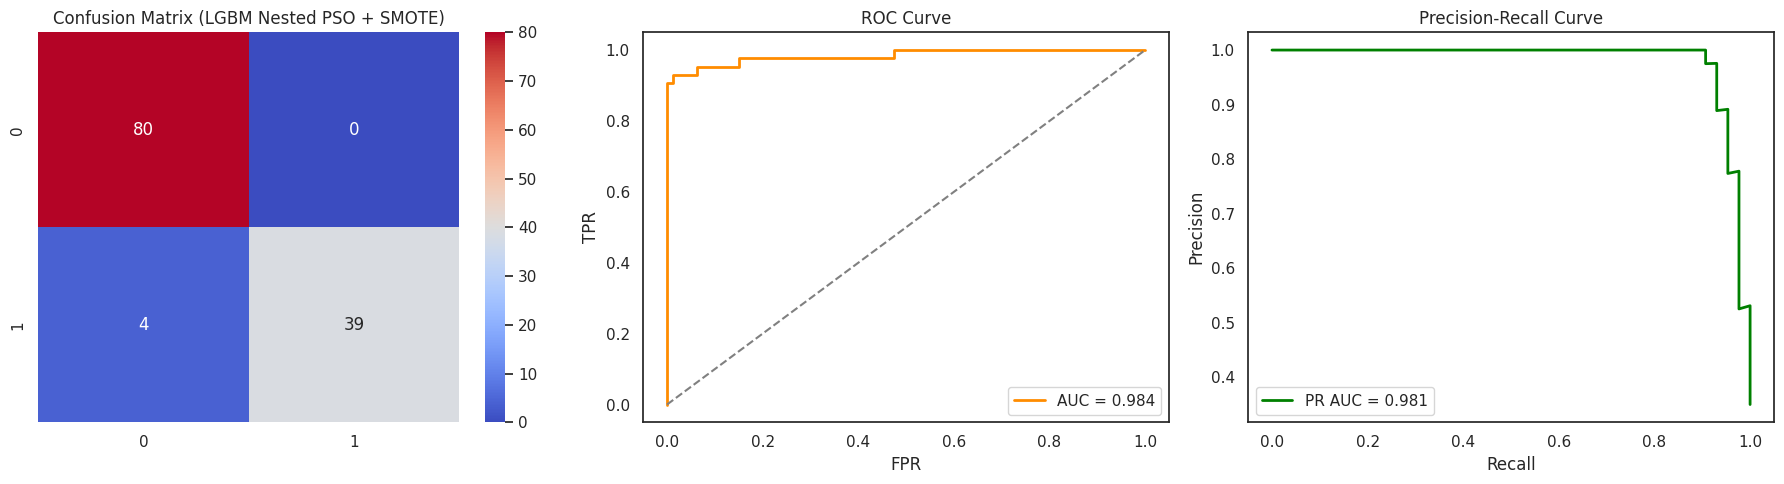


===== LGBM Evaluation (Nested PSO + SMOTE) =====
AUC (ROC) : 0.9837
PR-AUC    : 0.9807


,Model,Accuracy(cv),Precision(cv),Recall(cv),F1_score(cv),ROC(cv),Log_Loss(cv),mathew_corrcoef(cv),Accuracy(test),Precision(test),Recall(test),F1_score(test),ROC(test),Log_Loss(test),mathew_corrcoef(test)
0,LGBM (Nested Repeated PSO + SMOTE),0.959349,0.954566,0.958718,0.95575,0.993059,0.106645,0.913159,0.96748,0.97619,0.953488,0.963415,0.983721,0.127864,0.929402


In [ ]:
from sklearn.model_selection import StratifiedKFold, RepeatedStratifiedKFold, cross_val_score
from sklearn.preprocessing import MinMaxScaler
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, log_loss, matthews_corrcoef, confusion_matrix,
                             roc_curve, precision_recall_curve, auc)
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from pyswarm import pso

# Raw (unscaled) data
X_train_arr = X_train.values if hasattr(X_train, "values") else X_train
y_train_arr = y_train.values if hasattr(y_train, "values") else y_train
X_test_arr  = X_test.values if hasattr(X_test, "values") else X_test
y_test_arr  = y_test.values if hasattr(y_test, "values") else y_test

# ==========================
# 1. PSO Objective (INNER loop) — takes X, y as args so it can be
#    called on ANY outer-fold's training data only
# ==========================
def lgbm_pso_objective(params, X, y):
    n_estimators      = int(params[0])
    max_depth         = int(params[1])
    learning_rate     = params[2]
    num_leaves        = int(params[3])
    min_child_samples = int(params[4])
    subsample         = params[5]
    colsample_bytree  = params[6]
    reg_lambda        = params[7]

    lgbm = LGBMClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        num_leaves=num_leaves,
        min_child_samples=min_child_samples,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        reg_lambda=reg_lambda,
        random_state=42,
        verbosity=-1
    )

    pipeline = Pipeline([
        ('scaler', MinMaxScaler()),
        ('smote', SMOTE(random_state=42)),
        ('lgbm', lgbm)
    ])

    inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(pipeline, X, y, cv=inner_cv, scoring='f1_macro')
    return -scores.mean()

# ==========================
# 2. PSO Bounds
# ==========================
lb = [50, 3, 0.01, 20, 10, 0.7, 0.7, 0.0]
ub = [300, 10, 0.1, 200, 100, 1.0, 1.0, 5.0]

# ============================================================
# PART 1: Nested Repeated Cross-Validation
# Outer loop = performance estimate (unbiased)
# Inner loop (inside PSO objective) = hyperparameter search
# ============================================================

N_SPLITS  = 5
N_REPEATS = 2

outer_cv = RepeatedStratifiedKFold(n_splits=N_SPLITS, n_repeats=N_REPEATS, random_state=42)

fold_acc, fold_precision, fold_recall = [], [], []
fold_f1, fold_roc, fold_logloss, fold_mcc = [], [], [], []
best_params_per_fold = []

print(f"Nested Repeated CV: {N_SPLITS} splits x {N_REPEATS} repeats "
      f"= {N_SPLITS*N_REPEATS} outer folds\n")
print("Fold-wise Results (LGBM - Nested PSO + SMOTE + fold-wise scaling):\n")

for i, (train_idx, val_idx) in enumerate(outer_cv.split(X_train_arr, y_train_arr), 1):
    X_tr, X_val = X_train_arr[train_idx], X_train_arr[val_idx]
    y_tr, y_val = y_train_arr[train_idx], y_train_arr[val_idx]

    # ---- INNER: PSO searches hyperparameters using ONLY this outer fold's train data ----
    try:
        best_params, _ = pso(
            lambda p: lgbm_pso_objective(p, X_tr, y_tr),
            lb, ub, swarmsize=15, maxiter=15
        )
        best_n_estimators      = int(best_params[0])
        best_max_depth         = int(best_params[1])
        best_learning_rate     = best_params[2]
        best_num_leaves        = int(best_params[3])
        best_min_child_samples = int(best_params[4])
        best_subsample         = best_params[5]
        best_colsample_bytree  = best_params[6]
        best_reg_lambda        = best_params[7]
    except:
        print(f"PSO failed or skipped on fold {i}; using default parameters")
        best_n_estimators      = 100
        best_max_depth         = 5
        best_learning_rate     = 0.05
        best_num_leaves        = 31
        best_min_child_samples = 20
        best_subsample         = 0.8
        best_colsample_bytree  = 0.8
        best_reg_lambda        = 1

    best_params_per_fold.append([best_n_estimators, best_max_depth, best_learning_rate,
                                  best_num_leaves, best_min_child_samples,
                                  best_subsample, best_colsample_bytree, best_reg_lambda])

    print(f"Fold {i} Optimized Parameters:")
    print(f"n_estimators={best_n_estimators}, max_depth={best_max_depth}, learning_rate={best_learning_rate:.4f}, "
          f"num_leaves={best_num_leaves}, min_child_samples={best_min_child_samples}, "
          f"subsample={best_subsample:.2f}, colsample_bytree={best_colsample_bytree:.2f}, "
          f"reg_lambda={best_reg_lambda:.2f}")

    # ---- Fold-wise MinMax Scaling (fit ONLY on outer-train fold) ----
    scaler = MinMaxScaler()
    X_tr_scaled = scaler.fit_transform(X_tr)
    X_val_scaled = scaler.transform(X_val)

    # ---- SMOTE applied to outer-train ONLY, after scaling ----
    smote = SMOTE(random_state=42)
    X_tr_resampled, y_tr_resampled = smote.fit_resample(X_tr_scaled, y_tr)

    # ---- Fit model for this outer fold with its own PSO-found hyperparameters ----
    model = LGBMClassifier(
        n_estimators=best_n_estimators,
        max_depth=best_max_depth,
        learning_rate=best_learning_rate,
        num_leaves=best_num_leaves,
        min_child_samples=best_min_child_samples,
        subsample=best_subsample,
        colsample_bytree=best_colsample_bytree,
        reg_lambda=best_reg_lambda,
        random_state=42,
        verbosity=-1
    )
    model.fit(X_tr_resampled, y_tr_resampled)

    # ---- Evaluate on the untouched outer-validation fold ----
    y_val_pred = model.predict(X_val_scaled)
    y_val_prob = model.predict_proba(X_val_scaled)[:,1]

    acc         = accuracy_score(y_val, y_val_pred)
    precision   = precision_score(y_val, y_val_pred, average='macro')
    recall      = recall_score(y_val, y_val_pred, average='macro')
    f1          = f1_score(y_val, y_val_pred, average='macro')
    roc         = roc_auc_score(y_val, y_val_prob)
    logloss_val = log_loss(y_val, y_val_prob)
    mcc_val     = matthews_corrcoef(y_val, y_val_pred)
    CM_val      = confusion_matrix(y_val, y_val_pred)

    fold_acc.append(acc)
    fold_precision.append(precision)
    fold_recall.append(recall)
    fold_f1.append(f1)
    fold_roc.append(roc)
    fold_logloss.append(logloss_val)
    fold_mcc.append(mcc_val)

    print(f"Fold {i} → Acc:{acc:.3f} | Prec:{precision:.3f} | Recall:{recall:.3f} | "
          f"F1:{f1:.3f} | ROC:{roc:.3f} | LogLoss:{logloss_val:.3f} | MCC:{mcc_val:.3f}")
    print(f"Confusion Matrix (Fold {i}):\n{CM_val}\n")

# ===== Outer-fold averages (this is your UNBIASED nested CV estimate) =====
print("\n===== Nested Repeated CV — Average Metrics (LGBM PSO + SMOTE + fold-wise scaling) =====")
print(f"Accuracy: {np.mean(fold_acc):.4f} ± {np.std(fold_acc):.4f}")
print(f"Precision: {np.mean(fold_precision):.4f} ± {np.std(fold_precision):.4f}")
print(f"Recall: {np.mean(fold_recall):.4f} ± {np.std(fold_recall):.4f}")
print(f"F1: {np.mean(fold_f1):.4f} ± {np.std(fold_f1):.4f}")
print(f"ROC: {np.mean(fold_roc):.4f} ± {np.std(fold_roc):.4f}")
print(f"LogLoss: {np.mean(fold_logloss):.4f} ± {np.std(fold_logloss):.4f}")
print(f"MCC: {np.mean(fold_mcc):.4f} ± {np.std(fold_mcc):.4f}")

# ============================================================
# PART 2: Final deployable model
# Re-run PSO on the FULL training set (separate from the nested
# estimate above, which is only for reporting generalization performance)
# ============================================================
try:
    final_best_params, _ = pso(
        lambda p: lgbm_pso_objective(p, X_train_arr, y_train_arr),
        lb, ub, swarmsize=20, maxiter=20
    )
    best_n_estimators      = int(final_best_params[0])
    best_max_depth         = int(final_best_params[1])
    best_learning_rate     = final_best_params[2]
    best_num_leaves        = int(final_best_params[3])
    best_min_child_samples = int(final_best_params[4])
    best_subsample         = final_best_params[5]
    best_colsample_bytree  = final_best_params[6]
    best_reg_lambda        = final_best_params[7]
except:
    print("Final PSO failed or skipped; using median of per-fold best parameters")
    med = np.median(np.array(best_params_per_fold), axis=0)
    best_n_estimators      = int(med[0])
    best_max_depth         = int(med[1])
    best_learning_rate     = med[2]
    best_num_leaves        = int(med[3])
    best_min_child_samples = int(med[4])
    best_subsample         = med[5]
    best_colsample_bytree  = med[6]
    best_reg_lambda        = med[7]

print("\nFinal Optimized Parameters (full training set):")
print(f"n_estimators={best_n_estimators}, max_depth={best_max_depth}, learning_rate={best_learning_rate:.4f}, "
      f"num_leaves={best_num_leaves}, min_child_samples={best_min_child_samples}, "
      f"subsample={best_subsample:.2f}, colsample_bytree={best_colsample_bytree:.2f}, "
      f"reg_lambda={best_reg_lambda:.2f}")

final_scaler = MinMaxScaler()
X_train_scaled_final = final_scaler.fit_transform(X_train_arr)
X_test_scaled_final  = final_scaler.transform(X_test_arr)

smote_final = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote_final.fit_resample(X_train_scaled_final, y_train_arr)

final_model = LGBMClassifier(
    n_estimators=best_n_estimators,
    max_depth=best_max_depth,
    learning_rate=best_learning_rate,
    num_leaves=best_num_leaves,
    min_child_samples=best_min_child_samples,
    subsample=best_subsample,
    colsample_bytree=best_colsample_bytree,
    reg_lambda=best_reg_lambda,
    random_state=42,
    verbosity=-1
)
final_model.fit(X_train_resampled, y_train_resampled)

# ===== "Train/CV" metrics = nested outer-fold averages =====
acc_cv       = np.mean(fold_acc)
precision_cv = np.mean(fold_precision)
recall_cv    = np.mean(fold_recall)
f1_cv        = np.mean(fold_f1)
roc_cv       = np.mean(fold_roc)
logloss_cv   = np.mean(fold_logloss)
mcc_cv       = np.mean(fold_mcc)

# ===== Test metrics =====
y_test_pred = final_model.predict(X_test_scaled_final)
y_test_prob = final_model.predict_proba(X_test_scaled_final)[:,1]

acc_test       = accuracy_score(y_test_arr, y_test_pred)
precision_test = precision_score(y_test_arr, y_test_pred, average='macro')
recall_test    = recall_score(y_test_arr, y_test_pred, average='macro')
f1_test        = f1_score(y_test_arr, y_test_pred, average='macro')
roc_test       = roc_auc_score(y_test_arr, y_test_prob)
logloss_test   = log_loss(y_test_arr, y_test_prob)
mcc_test       = matthews_corrcoef(y_test_arr, y_test_pred)

# ===== Curves =====
CM = confusion_matrix(y_test_arr, y_test_pred)
fpr, tpr, _ = roc_curve(y_test_arr, y_test_prob)
roc_auc_val = auc(fpr, tpr)
precision_vals, recall_vals, _ = precision_recall_curve(y_test_arr, y_test_prob)
pr_auc = auc(recall_vals, precision_vals)

plt.figure(figsize=(18,5))

plt.subplot(1,3,1)
sns.heatmap(CM, annot=True, fmt='d', cmap='coolwarm')
plt.title("Confusion Matrix (LGBM Nested PSO + SMOTE)")

plt.subplot(1,3,2)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_val:.3f}", color='darkorange', lw=2)
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.legend(loc="lower right")

plt.subplot(1,3,3)
plt.plot(recall_vals, precision_vals, label=f"PR AUC = {pr_auc:.3f}", color='green', lw=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend(loc="lower left")

plt.tight_layout()
plt.show()

print("\n===== LGBM Evaluation (Nested PSO + SMOTE) =====")
print(f"AUC (ROC) : {roc_auc_val:.4f}")
print(f"PR-AUC    : {pr_auc:.4f}")

# ============================================================
# PART 3: Append metrics to comparison DataFrame
# ============================================================
r = comp_ev.shape[0]
comp_ev.loc[r] = ['LGBM (Nested Repeated PSO + SMOTE)', acc_cv, precision_cv, recall_cv, f1_cv,
                  roc_cv, logloss_cv, mcc_cv, acc_test, precision_test, recall_test,
                  f1_test, roc_test, logloss_test, mcc_test]

comp_ev = comp_ev.sort_values(by='Accuracy(test)', ascending=False).reset_index(drop=True)
comp_ev